# 0. Load Data

In [324]:
"""Load Data
Structure:
    1. Imports, Variables, Functions
    2. Load Data
"""

# 1. Imports, Variables, Functions
# imports   
import sys
sys.path.append("exp/utils_exp")
from utils_exp import utils as ut
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
# # from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io 
logging.basicConfig(level=logging.INFO)

# variables
# run_dir = os.path.join("..","..","outputs","run-25-09-28-05") 
run_dir = os.path.join("..","..","outputs","run-25-09-13-18")  # RNA-seq
# run_dir = os.path.join("..","..","outputs","run-25-10-05-01") 
# run_dir = os.path.join("..","..","outputs","run-25-09-17-01") # Microarray

embedding_type = "ft"

assert embedding_type in ["ft", "pt", "raw"]
if embedding_type == "ft":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join(run_dir, "outputs")
elif embedding_type == "pt":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "outputs")
elif embedding_type == "raw":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "outputs")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# functions
def get_counts(df:pd.DataFrame, rel_map:Dict, key_interest:str)->pd.DataFrame:
    df_query = df.copy()

    n_same, n_rel, n_unrel, n_total, n_universe_related, n_total_unique = [], [], [], [], [], []
    n_same_uniq, n_rel_uniq = [], []

    for _, r in df_query.iterrows():
        topk = list(r[key_interest])  # keep duplicates
        doid = r["query_doid"]
        related = rel_map.get(doid, set())

        same = sum(1 for x in topk if x == doid)           # absolute count of the exact disease
        rel  = sum(1 for x in topk if x in related)        # absolute count of related diseases (counts repeats)
        total = len(topk)
        unrel = total - same - rel
        
        n_same.append(same)
        n_same_uniq.append(len(set(topk) & {doid}))
        n_rel.append(rel)
        n_rel_uniq.append(len(set(topk) & related))
        n_unrel.append(unrel)
        n_total.append(total)
        n_universe_related.append(len(related)+1)  # +1 to include self
        n_total_unique.append(len(set(topk)))

    df_query["n_same"] = n_same
    df_query["n_rel"]   = n_rel
    df_query["n_unrel"] = n_unrel
    df_query["n_total"] = n_total
    df_query["n_universe_related"] = n_universe_related
    df_query["n_total_unique"] = n_total_unique
    df_query["n_same_uniq"] = n_same_uniq
    df_query["n_rel_uniq"] = n_rel_uniq

    df_query["pct_same"]  = df_query["n_same"] / df_query["n_total"] * 100
    df_query["pct_rel"]   = df_query["n_rel"] / df_query["n_total"] * 100
    df_query["pct_unrel"] = df_query["n_unrel"] / df_query["n_total"] * 100

    df_query["hits_same"] = (df_query["n_same"] > 0).astype(int)
    df_query["hits_rel"]  = (df_query["n_rel"] > 0).astype(int)

    # get precision
    # df_query["prec@k"] = (df_query["n_rel"]+df_query["n_same"]) / df_query["n_total"]
    
    df_query["old_prec@k"] = (df_query["n_rel"]+df_query["n_same"]) / df_query["n_total"]
    df_query["old_recall@k"] = (df_query["n_rel"]+df_query["n_same"]) / df_query["n_universe_related"]
    df_query["prec@k"] = (df_query["n_rel_uniq"]+df_query["n_same_uniq"]) / df_query["n_total_unique"]
    df_query["recall@k"] = (df_query["n_rel_uniq"]+df_query["n_same_uniq"]) / df_query["n_universe_related"]

    return df_query

# 2. Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-09-12-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: rand_stratified
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT_BATCH_LABELS: False
do_combat: False
ontology: do
scgpt_pp: norm_log1p
description: no control loss
library: RNA-Seq
use_controls: True


In [331]:
import importlib
import scanpy as sc

importlib.reload(ut)
importlib.reload(vz)

split_idx = 0

# load all adata
adata_test =  sc.read(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  sc.read(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  sc.read(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  

In [332]:
# load scGPT embeddings
print(f"Using {embedding_type} embeddings")
if embedding_type == "ft":
    embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
    embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
    embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])
    print(f"Loaded ft embeddings from all_outputs")
elif embedding_type == "pt":
    # pt_adata_test = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_test_1.h5ad"))
    # pt_adata_valid = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_valid_1.h5ad"))
    # pt_adata_train = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_train_1.h5ad"))
    # embeddings_test = pt_adata_test.obsm["X_scGPT"]
    # embeddings_valid = pt_adata_valid.obsm["X_scGPT"]
    # embeddings_train = pt_adata_train.obsm["X_scGPT"]

    embeddings_test = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "test-pt_embeddings.npy"))
    embeddings_valid = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "valid-pt_embeddings.npy"))
    embeddings_train = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "train-pt_embeddings.npy"))
    print(f"Loaded pt embeddings from npy files")
elif embedding_type == "raw":
    embeddings_test = np.array(adata_test.X)
    embeddings_valid = np.array(adata_valid.X)
    embeddings_train = np.array(adata_train.X)

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)
    print(f"Loaded raw embeddings from adata.X")

Using ft embeddings
Loaded ft embeddings from all_outputs


In [217]:
print(f"embeddings_train shape: {embeddings_train.shape}")
print(f"embeddings_valid shape: {embeddings_valid.shape}")
print(f"embeddings_test shape: {embeddings_test.shape}")

embeddings_train shape: (18305, 512)
embeddings_valid shape: (2034, 512)
embeddings_test shape: (5248, 512)


In [ ]:
"""0.2 Load Disease Ontology Pairs
Load pairs of related and unrelated diseases from the Disease Ontology.
Structure:
    1. Imports, Variables, Functions
    2. Load Disease Pairs

"""
# 1. Imports, Variables, Functions
# imports
from src.utils import utils 

# variables

# functions


# 2. Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = utils.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = utils.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}


KeyboardInterrupt: 

In [344]:
# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}")
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}")
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)

# map doid to related diseases
rel_map = {}
for thr in [0.396, 0.6, 0.8, 0.9]:
    rel_map[thr] = dict()
    _do_df = do_df_ic_query.query(f"lin >= {thr}")

    for d in d_ids:
        rel_map[thr][d] = set(_do_df.loc[_do_df["do1"] == d, "do2"]) | \
                    set(_do_df.loc[_do_df["do2"] == d, "do1"])

IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (7503, 8)
Nº of significant pairs in dataset (top 5% IC): (917, 8)
Nº of significant pairs in dataset (top 1% IC): (354, 8)
Nº of negative pairs in dataset (outside 5%): (6586, 8)


# 1. Classification: Multi Class
We consider each sample can only map to a single disease label out of N possible labels.

# 2. Classification: Multi Label

We consider each sample can map to multiple disease labels out of N possible labels.

## 2.1 Data Preparation

In [359]:
# imports
import importlib
importlib.reload(ut)

# variables
remove_control_train = False
remove_control_test = True
custom_splits = False
merge_train_valid = True
thr_related = 1.0

# functions

def get_df_pred(y_true, y_prob, y_doids, all_doids):
    results = []
    all_doids = np.array(all_doids)
    for i in range(y_true.shape[0]):
        y_true_i = y_true[i]
        y_prob_i = y_prob[i]
        y_doids_i = y_doids[i]  
        
        results.append({
            "query_doid":y_doids_i,
            "top_1":all_doids[np.argsort(y_prob_i)[-1:][::-1]].tolist(),
            "top_5":all_doids[np.argsort(y_prob_i)[-5:][::-1]].tolist(),
            "top_10":all_doids[np.argsort(y_prob_i)[-10:][::-1]].tolist(),
            "+0.05":all_doids[y_prob_i >= 0.1].tolist(),
            "+0.1":all_doids[y_prob_i >= 0.1].tolist(),
            "+0.3":all_doids[y_prob_i >= 0.3].tolist(),
            "+0.5":all_doids[y_prob_i >= 0.5].tolist(),
            "+0.8":all_doids[y_prob_i >= 0.8].tolist(),
        })


    return pd.DataFrame(results)

def get_df_performance(dfs_conds:List[Tuple[pd.DataFrame]], rel_map:Dict, n_labels:int)->pd.DataFrame:
    """Get performance metrics aggregated by diseases and by samples
    """
    perf_results = list()
    for _df, _condition in dfs_conds:
        for k in _df.columns[1:]:
            for thr in [0.396, 0.6, 0.8, 0.9]:
                # get counts
                _df_counts = get_counts(_df, rel_map[thr], k)
                _df_counts["random_baseline"] = _df_counts["n_total"]*1/n_labels
                    
                # group by disease
                perf_results.append({
                    "Key": k,
                    "Across": "Diseases",
                    "Condition": _condition,
                    "Hits Same Disease": f"{_df_counts.groupby("query_doid")["hits_same"].mean().mean()*100:.1f}",
                    "Related Threshold": thr,
                    "Precision@K": f"{_df_counts.groupby('query_doid')['prec@k'].mean().mean()*100:.1f}",
                    "Recall@K": f"{_df_counts.groupby('query_doid')['recall@k'].mean().mean()*100:.1f}",    
                    "Size": f'{_df_counts["n_total"].mean():.0f}±{_df_counts["n_total"].std():.0f}' if _df_counts["n_total"].std() > 0 else f'{_df_counts["n_total"].mean():.0f}',
                    "Unique Size": f'{_df_counts["n_total_unique"].mean():.0f}±{_df_counts["n_total_unique"].std():.0f}' if _df_counts["n_total_unique"].std() > 0 else f'{_df_counts["n_total_unique"].mean():.0f}',
                    "Hits Related Disease": f"{_df_counts.groupby("query_doid")["hits_rel"].mean().mean()*100:.1f}",
                    "Random Baseline": f"{_df_counts.groupby('query_doid')['random_baseline'].mean().mean()*100:.1f}",
                })

                # across all samples
                perf_results.append({
                    "Key": k,
                    "Across": "Samples",
                    "Condition": _condition,
                    "Hits Same Disease": f"{_df_counts["hits_same"].mean()*100:.1f}",
                    "Related Threshold": thr,
                    "Precision@K": f"{_df_counts['prec@k'].mean()*100:.1f}",
                    "Recall@K": f"{_df_counts['recall@k'].mean()*100:.1f}",
                    "Size": f'{_df_counts["n_total"].mean():.0f}±{_df_counts["n_total"].std():.0f}' if _df_counts["n_total"].std() > 0 else f'{_df_counts["n_total"].mean():.0f}',
                    "Unique Size": f'{_df_counts["n_total_unique"].mean():.0f}±{_df_counts["n_total_unique"].std():.0f}' if _df_counts["n_total_unique"].std() > 0 else f'{_df_counts["n_total_unique"].mean():.0f}',
                    "Hits Related Disease": f"{_df_counts["hits_rel"].mean()*100:.1f}",
                    "Random Baseline": f"{_df_counts['random_baseline'].mean()*100:.1f}",
                })
    return pd.DataFrame(perf_results)

def custom_train_valid_split(df, random_state=42, remove_control:bool=False)->Tuple[np.ndarray, np.ndarray]:
    """
    For each disease:
      - If multiple datasets exist → split by dataset (1 dataset → valid)
        and also split CONTROL samples belonging to the same datasets.
      - Otherwise → split disease samples by individual rows (1 sample → valid).
    """
    rng = np.random.default_rng(random_state)
    train_idx, valid_idx = [], []

    if not remove_control:
        df_controls = df[df["doid_id"] == "Control"]

    valid_datasets = set()
    train_datasets = set()
    # Loop through diseases
    for doid in df["doid_id"].unique():
        if doid == "Control":
            continue  # df_controls handled when splitting real diseases
        
        df_do = df[df["doid_id"] == doid]
        datasets = df_do["dataset"].unique()

        n_overlap_valid = len(valid_datasets & set(datasets))
        if (n_overlap_valid>0) & (len(datasets)-n_overlap_valid)>0:   # if dataset already placed in valid set

            # place existing dataset in valid for this disease
            valid_idx.extend(df_do[df_do["dataset"].isin(valid_datasets)].index)
            train_idx.extend(df_do[~df_do["dataset"].isin(valid_datasets)].index)

        elif len(datasets)-n_overlap_valid > 1:
            rng.shuffle(list(datasets))
            new_valid_datasets = {d for d in datasets if d not in valid_datasets}  # datasets not already in valid
            new_valid_datasets = {list(new_valid_datasets)[0]}  # take one new dataset for valid
            new_train_datasets = set(datasets) - new_valid_datasets - valid_datasets

            # disease samples
            valid_idx.extend(df_do[df_do["dataset"].isin(new_valid_datasets)].index)
            train_idx.extend(df_do[df_do["dataset"].isin(new_train_datasets)].index)

            valid_datasets.update(new_valid_datasets)
            train_datasets.update(new_train_datasets)

            if not remove_control:
                # matching CONTROL samples for those datasets
                ctrl_valid = df_controls[df_controls["dataset"].isin(new_valid_datasets)].index
                ctrl_train = df_controls[df_controls["dataset"].isin(new_train_datasets)].index

                valid_idx.extend(ctrl_valid)
                train_idx.extend(ctrl_train)
        else:
            idx = df_do.index.to_numpy()
            rng.shuffle(idx)
            n_valid_ds = max(1, len(idx) // 6)
            valid_idx.append(idx[n_valid_ds-1])
            train_idx.extend(idx[n_valid_ds:])

            # controls for this dataset (if available)
            ds = df_do["dataset"].iloc[0]

            if not remove_control:            
                ctrl_ds = df_controls[df_controls["dataset"] == ds].index.to_numpy()

                if len(ctrl_ds) > 0:
                    rng.shuffle(ctrl_ds)
                    n_valid_ds = max(1, len(ctrl_ds) // 6)
                    valid_idx.append(ctrl_ds[n_valid_ds-1])
                    train_idx.extend(ctrl_ds[n_valid_ds:])

    return np.array(train_idx), np.array(valid_idx)

# prepare data
all_doids = sorted(adata_train.obs["doid_id"].unique())

df_train = adata_train.obs.copy()
df_valid = adata_valid.obs.copy()
df_test = adata_test.obs.copy()

e_train = embeddings_train
e_valid = embeddings_valid
e_test = embeddings_test

if remove_control_train:
    all_doids.remove("Control")

    mask_train = df_train["doid_id"] != "Control"
    mask_valid = df_valid["doid_id"] != "Control"

    e_train = e_train[mask_train.values]
    e_valid = e_valid[mask_valid.values]

    df_train = df_train[mask_train].reset_index(drop=True)
    df_valid = df_valid[mask_valid].reset_index(drop=True)

if remove_control_test:
    mask_test = df_test["doid_id"] != "Control"

    e_test = e_test[mask_test.values]

    df_test = df_test[mask_test].reset_index(drop=True)


if custom_splits:
    df_train_all = pd.concat([df_train.reset_index(drop=True), df_valid.reset_index(drop=True)], axis=0)
    df_train_all = df_train_all.reset_index(drop=True)

    # RE-SPLIT TRAIN/VALIDATION SET
    train_idx, valid_idx = custom_train_valid_split(df_train_all, remove_control=remove_control_train)
    df_train = df_train_all.iloc[train_idx].reset_index(drop=True)
    df_valid = df_train_all.iloc[valid_idx].reset_index(drop=True)

    e_train_all = np.concatenate([e_train, e_valid], axis=0)
    e_train = e_train_all[train_idx]
    e_valid = e_train_all[valid_idx]

if merge_train_valid:
    df_train = pd.concat([df_train.reset_index(drop=True), df_valid.reset_index(drop=True)], axis=0)
    df_train = df_train.reset_index(drop=True)
    e_train =  np.concatenate([e_train, e_valid], axis=0)
    
    # create Y multilabel matrices
    y_train = ut.get_multilabel_y(df_train, all_doids, rel_map, thr_related=thr_related)
    y_test = ut.get_multilabel_y(df_test, all_doids, rel_map, thr_related=thr_related)

else:
    # create Y multilabel matrices
    y_train = ut.get_multilabel_y(df_train, all_doids, rel_map, thr_related=thr_related)
    y_valid = ut.get_multilabel_y(df_valid, all_doids, rel_map, thr_related=thr_related)
    y_test = ut.get_multilabel_y(df_test, all_doids, rel_map, thr_related=thr_related)

print(f"Nº of diseases train: {df_train['doid_id'].nunique()}\tNº of diseases valid: {df_valid['doid_id'].nunique()}")
print(f"Nº of samples train: {df_train.shape[0]}\tNº of samples valid: {df_valid.shape[0]}")
print(f"Nº unique datasets train: {df_train['dataset'].nunique()}\tNº unique datasets valid: {df_valid['dataset'].nunique()}")
print(f"Nº overlap datasets train/valid: {len(set(df_train['dataset'].unique()) & set(df_valid['dataset'].unique()))}")


Nº of diseases train: 124	Nº of diseases valid: 107
Nº of samples train: 20339	Nº of samples valid: 2034
Nº unique datasets train: 471	Nº unique datasets valid: 382
Nº overlap datasets train/valid: 382


In [360]:
df_train

,ids,dataset,dataset_id,batch,batch_id,dsaid,tissue,n_genes,disease,celltype,disease_study,library,doid_study,doid_id,do_id,doid_disease,celltype_id,sample_id,test_split_1
0,DSA07457.GSM2310211.Control,GSE86906,GSE86906,1064,289,DSA07457,Brain,19402,Control,Control,Schizophrenia,RNA-Seq,D,Control,Control,Control,0,GSM2310211,0
1,DSA05326.GSM6167423.Case,GSE203346,GSE203346,1194,320,DSA05326,Placenta,19402,Gestational Diabetes Mellitus,DOID:11714,Gestational Diabetes Mellitus,RNA-Seq,D,DOID:11714,DOID:11714,gestational diabetes,170,GSM6167423,0
2,DSA01224.GSM4071855.Control,GSE137143,GSE137143,204,62,DSA01224,nan,19402,Control,Control,Multiple Sclerosis,RNA-Seq,D,Control,Control,Control,0,GSM4071855,0
3,DSA05327.GSM6167363.Control,GSE203346,GSE203346,1194,320,DSA05327,Umbilical cord blood,19402,Control,Control,Gestational Diabetes Mellitus,RNA-Seq,D,Control,Control,Control,0,GSM6167363,0
4,DSA08056.GSM1185137.Case,GSE48812,GSE48812,2079,575,DSA08056,Prostate,19402,Prostate Cancer,DOID:10286,Prostate Cancer,RNA-Seq,D,DOID:10286,DOID:10286,prostate carcinoma,150,GSM1185137,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20334,DSA07497.GSM2373855.Case,GSE88805,GSE88805,1930,533,DSA07497,Stomach,19402,Gastric Adenocarcinoma,DOID:3717,Gastric Adenocarcinoma,RNA-Seq,D,DOID:3717,DOID:3717,gastric adenocarcinoma,78,GSM2373855,0
20335,DSA05072.GSM5978113.Case,GSE193677,GSE193677,1154,313,DSA05072,Bowel,19402,Ulcerative Colitis,DOID:8577,Ulcerative Colitis,RNA-Seq,D,DOID:8577,DOID:8577,ulcerative colitis,123,GSM5978113,0
20336,DSA05049.GSM5788632.Case,GSE193309,GSE193309,1802,495,DSA05049,Skin,19402,Atopic Dermatitis,DOID:3310,Atopic Dermatitis,RNA-Seq,D,DOID:3310,DOID:3310,atopic dermatitis,70,GSM5788632,0
20337,DSA05473.GSM6529135.Control,GSE212384,GSE212384,804,219,DSA05473,Blood,19402,Control,Control,Lung Disease,RNA-Seq,D,Control,Control,Control,0,GSM6529135,0


In [361]:
print(e_train.shape, y_train.shape)

(20339, 512) (20339, 124)


## 2.2 Model: Logistic Regression - N Independent Models

In [89]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

# variables
clf = LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")

# train
model = OneVsRestClassifier(clf, n_jobs=8)
model.fit(e_train, y_train)

KeyboardInterrupt: 

In [ ]:
# evaluate
y_test_prob = model.predict_proba(e_test)
df_pred_test = get_df_pred(y_test, y_test_prob, df_test["doid_id"].to_list(), all_doids)

df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_test, f"Remove Control {remove_control_train}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

In [ ]:
# evaluate
y_test_prob = model.predict_proba(e_test)
df_pred_test = get_df_pred(y_test, y_test_prob, df_test["doid_id"].to_list(), all_doids)

df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_test, f"Remove Control {remove_control_train}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

In [ ]:
# evaluate
y_valid_prob = model.predict_proba(e_valid)
df_pred_valid = get_df_pred(y_valid, y_valid_prob, df_valid["doid_id"].to_list(), all_doids)

df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_valid, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

In [ ]:
# evaluate
y_valid_prob = model.predict_proba(e_valid)
df_pred_valid = get_df_pred(y_valid, y_valid_prob, df_valid["doid_id"].to_list(), all_doids)

df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_valid, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

In [ ]:
# evaluate
y_train_prob = model.predict_proba(e_train)
df_pred_train = get_df_pred(y_train, y_train_prob, df_train["doid_id"].to_list(), all_doids)

df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_train, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

## 2.3 Random Forest Classifier

In [7]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

# variables
clf = RandomForestClassifier(n_estimators=100, class_weight="balanced", n_jobs=8)

# train
model = OneVsRestClassifier(clf, n_jobs=8)
model.fit(e_train, y_train)

,estimator,"RandomForestC...ed', n_jobs=8)"
,n_jobs,8
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None


In [8]:
# evaluate
y_test_prob = model.predict_proba(e_test)
y_valid_prob = model.predict_proba(e_valid)
y_train_prob = model.predict_proba(e_train)

In [9]:
def compute_pr_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    precision, recall, thresholds = precision_recall_curve(y_true_flat, y_scores_flat)
    ap = average_precision_score(y_true_flat, y_scores_flat)

    return precision, recall, thresholds, ap

def compute_auroc_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    auroc = roc_auc_score(y_true_flat, y_scores_flat)

    return auroc

def get_precision_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]  # shape (N_samples, k)
    return (y_topk.sum(axis=1) / k).mean()


def get_hit_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]
    # Hit@k = fraction of samples where at least 1 correct disease is in top k
    return (y_topk.sum(axis=1) > 0).mean()


data = list()
for threshold in [1.0, 0.8, 0.6, 0.396]:
    for split_type in ["Test", "Validation", "Train"]:
    

        if split_type == "Test":
            _y_multilab = ut.get_multilabel_y(df_test, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_test_prob
        elif split_type == "Validation":
            _y_multilab = ut.get_multilabel_y(df_valid, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_valid_prob
        else:
            _y_multilab = ut.get_multilabel_y(df_train, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_train_prob


        _prec, _recall, _, _ap = compute_pr_curve(
            _y_pred, _y_multilab
        )
        _auroc = compute_auroc_curve(_y_pred, _y_multilab)
        
        if threshold == 1.0:
            _hit_at_1 = get_hit_at_k(_y_pred, _y_multilab, 1)
            _hit_at_3 = get_hit_at_k(_y_pred, _y_multilab, 3)
            _hit_at_5 = get_hit_at_k(_y_pred, _y_multilab, 5)

        else:
            _prec_at_1 = get_precision_at_k(_y_pred, _y_multilab, 1)
            _prec_at_3 = get_precision_at_k(_y_pred, _y_multilab, 3)
            _prec_at_5 = get_precision_at_k(_y_pred, _y_multilab, 5)

        data.append({
            "Prediction": "Same Disease" if threshold==1.0 else f"Related +0.4" if threshold==0.396 else f"Related +{threshold}",
            "Split": f"{split_type}",
            "AUROC": f"{_auroc:.3f}",
            "AP": f"{_ap:.3f} ",
            "Random": f"{_y_multilab.mean():.3f}",
            "Hit/Precision@1": f"{_hit_at_1:.3f}" if threshold==1.0 else f"{_prec_at_1:.3f}",
            "Hit/Precision@3": f"{_hit_at_3:.3f}" if threshold==1.0 else f"{_prec_at_3:.3f}",
            "Hit/Precision@5": f"{_hit_at_5:.3f}" if threshold==1.0 else f"{_prec_at_5:.3f}",
        })

In [10]:
df_perf = pd.DataFrame(data)
df_perf

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5
0,Same Disease,Test,0.589,0.021,0.008,0.074,0.133,0.169
1,Same Disease,Validation,0.997,0.960,0.008,0.914,0.982,0.989
2,Same Disease,Train,1.000,1.000,0.008,1.000,1.000,1.000
3,Related +0.8,Test,0.617,0.069,0.019,0.229,0.146,0.106
4,Related +0.8,Validation,0.765,0.508,0.016,0.920,0.351,0.216
5,Related +0.8,Train,0.761,0.522,0.016,1.000,0.350,0.213
6,Related +0.6,Test,0.579,0.113,0.055,0.399,0.281,0.220
7,Related +0.6,Validation,0.651,0.292,0.041,0.943,0.497,0.331
8,Related +0.6,Train,0.632,0.277,0.041,1.000,0.483,0.311
9,Related +0.4,Test,0.550,0.260,0.200,0.701,0.618,0.516


In [11]:

df_pred_test = get_df_pred(y_test, y_test_prob, df_test["doid_id"].to_list(), all_doids)

df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_test, f"Remove Control {remove_control_train}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

,Key,Across,Condition,Hits Same Disease,Related Threshold,Precision@K,Recall@K,Size,Unique Size,Hits Related Disease,Random Baseline
0,top_1,Diseases,Remove Control True,11.4,0.396,57.1,4.7,1,1,45.7,0.8
1,top_1,Samples,Remove Control True,7.3,0.396,77.4,3.7,1,1,70.1,0.8
2,top_1,Diseases,Remove Control True,11.4,0.600,36.4,8.2,1,1,25.0,0.8
3,top_1,Samples,Remove Control True,7.3,0.600,47.3,6.8,1,1,40.0,0.8
4,top_1,Diseases,Remove Control True,11.4,0.800,29.2,11.0,1,1,17.9,0.8
...,...,...,...,...,...,...,...,...,...,...,...
59,+0.8,Samples,Remove Control True,1.7,0.600,61.2,1.2,0±0,0±0,8.9,0.1
60,+0.8,Diseases,Remove Control True,1.9,0.800,53.3,1.6,0±0,0±0,3.0,0.1
61,+0.8,Samples,Remove Control True,1.7,0.800,35.9,2.0,0±0,0±0,4.5,0.1
62,+0.8,Diseases,Remove Control True,1.9,0.900,22.6,1.8,0±0,0±0,0.1,0.1


In [12]:
# evaluate
y_test_prob = model.predict_proba(e_test)
df_pred_test = get_df_pred(y_test, y_test_prob, df_test["doid_id"].to_list(), all_doids)

df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_test, f"Remove Control {remove_control_train}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

,Key,Across,Condition,Hits Same Disease,Related Threshold,Precision@K,Recall@K,Size,Unique Size,Hits Related Disease,Random Baseline
0,top_1,Diseases,Remove Control True,11.4,0.396,57.1,4.7,1,1,45.7,0.8
1,top_1,Samples,Remove Control True,7.3,0.396,77.4,3.7,1,1,70.1,0.8
2,top_1,Diseases,Remove Control True,11.4,0.600,36.4,8.2,1,1,25.0,0.8
3,top_1,Samples,Remove Control True,7.3,0.600,47.3,6.8,1,1,40.0,0.8
4,top_1,Diseases,Remove Control True,11.4,0.800,29.2,11.0,1,1,17.9,0.8
...,...,...,...,...,...,...,...,...,...,...,...
59,+0.8,Samples,Remove Control True,1.7,0.600,61.2,1.2,0±0,0±0,8.9,0.1
60,+0.8,Diseases,Remove Control True,1.9,0.800,53.3,1.6,0±0,0±0,3.0,0.1
61,+0.8,Samples,Remove Control True,1.7,0.800,35.9,2.0,0±0,0±0,4.5,0.1
62,+0.8,Diseases,Remove Control True,1.9,0.900,22.6,1.8,0±0,0±0,0.1,0.1


In [13]:
# evaluate
y_valid_prob = model.predict_proba(e_valid)
df_pred_valid = get_df_pred(y_valid, y_valid_prob, df_valid["doid_id"].to_list(), all_doids)

df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_valid, f"Remove Control {remove_control_train}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

,Key,Across,Condition,Hits Same Disease,Related Threshold,Precision@K,Recall@K,Size,Unique Size,Hits Related Disease,Random Baseline
0,top_1,Diseases,Remove Control True,78.7,0.396,169.6,19.5,1,1,90.9,0.8
1,top_1,Samples,Remove Control True,91.3,0.396,188.0,16.3,1,1,96.7,0.8
2,top_1,Diseases,Remove Control True,78.7,0.600,165.1,41.3,1,1,86.4,0.8
3,top_1,Samples,Remove Control True,91.3,0.600,185.6,38.3,1,1,94.3,0.8
4,top_1,Diseases,Remove Control True,78.7,0.800,161.3,63.5,1,1,82.6,0.8
...,...,...,...,...,...,...,...,...,...,...,...
59,+0.8,Samples,Remove Control True,65.1,0.600,197.8,25.9,1±0,1±0,65.3,0.5
60,+0.8,Diseases,Remove Control True,33.2,0.800,193.4,26.9,1±0,1±0,33.3,0.3
61,+0.8,Samples,Remove Control True,65.1,0.800,197.6,47.1,1±0,1±0,65.1,0.5
62,+0.8,Diseases,Remove Control True,33.2,0.900,96.3,28.1,1±0,1±0,0.0,0.3


In [14]:
# evaluate
y_train_prob = model.predict_proba(e_train)
df_pred_train = get_df_pred(y_train, y_train_prob, df_train["doid_id"].to_list(), all_doids)

df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_train, f"Remove Control {remove_control_train}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

,Key,Across,Condition,Hits Same Disease,Related Threshold,Precision@K,Recall@K,Size,Unique Size,Hits Related Disease,Random Baseline
0,top_1,Diseases,Remove Control True,100.0,0.396,200.0,23.3,1,1,100.0,0.8
1,top_1,Samples,Remove Control True,100.0,0.396,200.0,17.6,1,1,100.0,0.8
2,top_1,Diseases,Remove Control True,100.0,0.600,200.0,51.3,1,1,100.0,0.8
3,top_1,Samples,Remove Control True,100.0,0.600,200.0,41.3,1,1,100.0,0.8
4,top_1,Diseases,Remove Control True,100.0,0.800,200.0,80.7,1,1,100.0,0.8
...,...,...,...,...,...,...,...,...,...,...,...
59,+0.8,Samples,Remove Control True,84.7,0.600,200.0,34.4,1±0,1±0,84.7,0.7
60,+0.8,Diseases,Remove Control True,56.4,0.800,200.0,45.4,1±0,1±0,56.4,0.5
61,+0.8,Samples,Remove Control True,84.7,0.800,200.0,62.3,1±0,1±0,84.7,0.7
62,+0.8,Diseases,Remove Control True,56.4,0.900,100.0,48.6,1±0,1±0,0.0,0.5


## 2.4 MLP Cross Etropy

In [18]:
# imports
import torch
import torch.nn as nn

# variables
input_dim = e_train.shape[1]
hidden_dim = 256
output_dim = y_train.shape[1]

# functions
class MLP_classifier(nn.Module):
    def __init__(self, input_dim:int, hidden_dim:int, output_dim:int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            # nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x):
        return self.net(x)
    
# define model
model_mlp = MLP_classifier(input_dim, hidden_dim, output_dim)

# define optimizer, criterion
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=0.001)

# data preparation
X_train_t = torch.tensor(e_train, dtype=torch.float32)
y_train_cls_t = torch.tensor(y_train, dtype=torch.float32)
X_valid_t = torch.tensor(e_valid, dtype=torch.float32)
y_valid_cls_t = torch.tensor(y_valid, dtype=torch.float32)

# train loop
epochs = 200
patience = 60
best_val_loss = float("inf") 

for epoch in range(1, epochs + 1):
    # training
    model_mlp.train()
    optimizer.zero_grad()


    train_logits = model_mlp.forward(X_train_t)
    train_loss = criterion(train_logits, y_train_cls_t)
    train_loss.backward()
    optimizer.step()

    # validation
    model_mlp.eval()
    with torch.no_grad():
        val_logits = model_mlp.forward(X_valid_t)
        val_loss = criterion(val_logits, y_valid_cls_t).item()
        print(f"Epoch {epoch:03d} | TrainLoss={train_loss.item():.4f} | ValLoss={val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_stat = model_mlp.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

# load best model
model_mlp.load_state_dict(best_model_stat)

Epoch 001 | TrainLoss=0.6987 | ValLoss=0.6460
Epoch 002 | TrainLoss=0.6461 | ValLoss=0.5946
Epoch 003 | TrainLoss=0.5949 | ValLoss=0.5394
Epoch 004 | TrainLoss=0.5397 | ValLoss=0.4788
Epoch 005 | TrainLoss=0.4791 | ValLoss=0.4139
Epoch 006 | TrainLoss=0.4143 | ValLoss=0.3475
Epoch 007 | TrainLoss=0.3479 | ValLoss=0.2832
Epoch 008 | TrainLoss=0.2837 | ValLoss=0.2247
Epoch 009 | TrainLoss=0.2251 | ValLoss=0.1743
Epoch 010 | TrainLoss=0.1748 | ValLoss=0.1337
Epoch 011 | TrainLoss=0.1340 | ValLoss=0.1027
Epoch 012 | TrainLoss=0.1030 | ValLoss=0.0805
Epoch 013 | TrainLoss=0.0808 | ValLoss=0.0655
Epoch 014 | TrainLoss=0.0657 | ValLoss=0.0560
Epoch 015 | TrainLoss=0.0560 | ValLoss=0.0502
Epoch 016 | TrainLoss=0.0502 | ValLoss=0.0470
Epoch 017 | TrainLoss=0.0469 | ValLoss=0.0453
Epoch 018 | TrainLoss=0.0451 | ValLoss=0.0444
Epoch 019 | TrainLoss=0.0442 | ValLoss=0.0439
Epoch 020 | TrainLoss=0.0437 | ValLoss=0.0437
Epoch 021 | TrainLoss=0.0434 | ValLoss=0.0433
Epoch 022 | TrainLoss=0.0431 | Val

<All keys matched successfully>

In [22]:
X_test_t = torch.tensor(e_test, dtype=torch.float32)
y_test_cls_t = torch.tensor(y_test, dtype=torch.float32)
# evaluate
model_mlp.eval()
with torch.no_grad():
    train_logits = model_mlp.forward(X_train_t)
    train_loss = criterion(train_logits, y_train_cls_t).item()
    print(f"Final Train Loss={train_loss:.4f}")

    val_logits = model_mlp.forward(X_valid_t)
    val_loss = criterion(val_logits, y_valid_cls_t).item()
    print(f"Final Val Loss={val_loss:.4f}")
    
    test_logits = model_mlp.forward(X_test_t)
    test_loss = criterion(test_logits, y_test_cls_t).item()
    print(f"Test Loss={test_loss:.4f}")




Final Train Loss=0.0071
Final Val Loss=0.0081
Test Loss=0.0686


In [23]:
train_logits

tensor([[ -9.7368,  -3.9042,  -6.7346,  ...,  -8.8559,  -7.7846,  -1.4278],
        [-13.3666, -11.5045, -10.5590,  ..., -11.5558, -11.9070, -11.7548],
        [-13.9764,  -7.2954,  -7.8720,  ...,  -9.7767,  -8.5482,  -8.8293],
        ...,
        [ -6.0983, -11.1302, -12.4456,  ..., -11.3714, -13.2320,  -9.8104],
        [ -5.3494,  -5.0344,  -5.1125,  ...,  -7.9756,  -6.3418,  -1.7396],
        [-12.2131, -11.5938, -11.9293,  ...,  -7.8894, -14.4143,  -9.9688]])

In [21]:
# Final Train Loss=0.0075
# Final Val Loss=0.0084
# Test Loss=0.0665

SyntaxError: invalid syntax (872511549.py, line 1)

In [ ]:
y_test_prob_mlp = test_logits.numpy()
df_pred_test_mlp = get_df_pred(y_test, y_test_prob_mlp, df_test["doid_id"].to_list(), all_doids)    
df_perf_test = get_df_performance(
    dfs_conds=[
        (df_pred_test_mlp, f"Remove Control {remove_control_train}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_test


,Key,Across,Condition,Hits Same Disease,Related Threshold,Precision@K,Recall@K,Size,Unique Size,Hits Related Disease,Random Baseline
0,top_1,Diseases,Remove Control False,4.6,0.396,27.2,1.4,1,1,22.6,0.8
1,top_1,Samples,Remove Control False,3.7,0.396,58.4,2.0,1,1,54.7,0.8
2,top_1,Diseases,Remove Control False,4.6,0.600,16.6,3.1,1,1,12.0,0.8
3,top_1,Samples,Remove Control False,3.7,0.600,31.7,3.6,1,1,28.0,0.8
4,top_1,Diseases,Remove Control False,4.6,0.800,14.1,4.7,1,1,9.5,0.8
...,...,...,...,...,...,...,...,...,...,...,...
59,+0.8,Samples,Remove Control False,1.9,0.600,41.1,1.6,0±0,0±0,11.9,0.3
60,+0.8,Diseases,Remove Control False,2.0,0.800,16.5,1.7,0±0,0±0,3.0,0.2
61,+0.8,Samples,Remove Control False,1.9,0.800,16.6,1.8,0±0,0±0,3.7,0.3
62,+0.8,Diseases,Remove Control False,2.0,0.900,6.8,1.9,0±0,0±0,0.0,0.2


In [ ]:
y_test_prob_mlp = test_logits.numpy()
df_pred_test_mlp = get_df_pred(y_test, y_test_prob_mlp, df_test["doid_id"].to_list(), all_doids)    
df_perf_test = get_df_performance(
    dfs_conds=[
        (df_pred_test_mlp, f"Remove Control {remove_control_train}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_test


,Key,Across,Condition,Hits Same Disease,Related Threshold,Precision@K,Recall@K,Size,Unique Size,Hits Related Disease,Random Baseline
0,top_1,Diseases,Remove Control True,10.9,0.396,50.5,4.0,1,1,39.6,0.8
1,top_1,Samples,Remove Control True,5.4,0.396,66.6,2.8,1,1,61.2,0.8
2,top_1,Diseases,Remove Control True,10.9,0.600,35.4,7.8,1,1,24.5,0.8
3,top_1,Samples,Remove Control True,5.4,0.600,37.4,5.0,1,1,32.0,0.8
4,top_1,Diseases,Remove Control True,10.9,0.800,27.1,10.8,1,1,16.3,0.8
...,...,...,...,...,...,...,...,...,...,...,...
59,+0.8,Samples,Remove Control True,5.8,0.600,40.2,5.4,1±2,1±2,29.8,1.1
60,+0.8,Diseases,Remove Control True,10.2,0.800,27.2,10.6,1±2,1±2,15.6,1.2
61,+0.8,Samples,Remove Control True,5.8,0.800,24.0,8.0,1±2,1±2,17.6,1.1
62,+0.8,Diseases,Remove Control True,10.2,0.900,12.8,10.6,1±2,1±2,2.7,1.2


In [ ]:
y_val_prob_mlp = val_logits.numpy()
df_pred_val_mlp = get_df_pred(y_valid, y_val_prob_mlp, df_valid["doid_id"].to_list(), all_doids)    
df_perf_val = get_df_performance(
    dfs_conds=[
        (df_pred_val_mlp, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_val


,Key,Across,Condition,Hits Same Disease,Related Threshold,Precision@K,Recall@K,Size,Unique Size,Hits Related Disease,Random Baseline
0,top_1,Diseases,Remove Control True,13.3,0.396,47.2,3.3,1,1,33.8,0.8
1,top_1,Samples,Remove Control True,34.4,0.396,83.2,5.1,1,1,48.8,0.8
2,top_1,Diseases,Remove Control True,13.3,0.600,29.9,5.9,1,1,16.5,0.8
3,top_1,Samples,Remove Control True,34.4,0.600,69.9,12.9,1,1,35.5,0.8
4,top_1,Diseases,Remove Control True,13.3,0.800,28.6,10.4,1,1,15.3,0.8
...,...,...,...,...,...,...,...,...,...,...,...
59,+0.8,Samples,Remove Control True,36.4,0.600,7.0,25.9,24±31,24±31,36.6,19.2
60,+0.8,Diseases,Remove Control True,17.6,0.800,4.0,16.6,24±31,24±31,18.2,9.5
61,+0.8,Samples,Remove Control True,36.4,0.800,4.4,32.8,24±31,24±31,36.6,19.2
62,+0.8,Diseases,Remove Control True,17.6,0.900,2.1,16.8,24±31,24±31,6.3,9.5


In [ ]:
y_train_prob_mlp = train_logits.numpy()
df_pred_train_mlp = get_df_pred(y_train, y_train_prob_mlp, df_train["doid_id"].to_list(), all_doids)    
df_perf_train = get_df_performance(
    dfs_conds=[
        (df_pred_train_mlp, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_train


,Key,Across,Condition,Hits Same Disease,Related Threshold,Precision@K,Recall@K,Size,Unique Size,Hits Related Disease,Random Baseline
0,top_1,Diseases,Remove Control True,13.9,0.396,45.9,3.3,1,1,32.0,0.8
1,top_1,Samples,Remove Control True,36.2,0.396,86.5,5.4,1,1,50.3,0.8
2,top_1,Diseases,Remove Control True,13.9,0.600,30.6,6.4,1,1,16.7,0.8
3,top_1,Samples,Remove Control True,36.2,0.600,72.9,13.6,1,1,36.7,0.8
4,top_1,Diseases,Remove Control True,13.9,0.800,28.7,10.8,1,1,14.8,0.8
...,...,...,...,...,...,...,...,...,...,...,...
59,+0.8,Samples,Remove Control True,36.9,0.600,7.1,26.3,24±31,24±31,37.2,19.4
60,+0.8,Diseases,Remove Control True,17.4,0.800,3.7,16.0,24±31,24±31,17.6,9.4
61,+0.8,Samples,Remove Control True,36.9,0.800,4.5,33.4,24±31,24±31,37.0,19.4
62,+0.8,Diseases,Remove Control True,17.4,0.900,1.9,16.2,24±31,24±31,5.7,9.4


## 2.5 KNN Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier

# KNN base classifier
knn = KNeighborsClassifier(
    n_neighbors=20,     # adjust as needed
    metric="cosine",    # cosine distance
    weights="distance"  # closer neighbors weigh more
)

# One-vs-rest multilabel wrapper
model_knn = OneVsRestClassifier(knn, n_jobs=8)

# Train classifier
model_knn.fit(e_train, y_train)

# Predict
y_train_pred = model_knn.predict_proba(e_train)
y_valid_pred = model_knn.predict_proba(e_valid)
y_test_pred  = model_knn.predict_proba(e_test)


KeyboardInterrupt: 

In [16]:
def compute_pr_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    precision, recall, thresholds = precision_recall_curve(y_true_flat, y_scores_flat)
    ap = average_precision_score(y_true_flat, y_scores_flat)

    return precision, recall, thresholds, ap

def compute_auroc_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    auroc = roc_auc_score(y_true_flat, y_scores_flat)

    return auroc

def get_precision_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]  # shape (N_samples, k)
    return (y_topk.sum(axis=1) / k).mean()


def get_hit_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]
    # Hit@k = fraction of samples where at least 1 correct disease is in top k
    return (y_topk.sum(axis=1) > 0).mean()


data = list()
for threshold in [1.0, 0.8, 0.6, 0.396]:
    for split_type in ["Test", "Validation", "Train"]:
    

        if split_type == "Test":
            _y_multilab = ut.get_multilabel_y(df_test, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_test_prob
        elif split_type == "Validation":
            _y_multilab = ut.get_multilabel_y(df_valid, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_valid_prob
        else:
            _y_multilab = ut.get_multilabel_y(df_train, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_train_prob


        _prec, _recall, _, _ap = compute_pr_curve(
            _y_pred, _y_multilab
        )
        _auroc = compute_auroc_curve(_y_pred, _y_multilab)
        
        if threshold == 1.0:
            _hit_at_1 = get_hit_at_k(_y_pred, _y_multilab, 1)
            _hit_at_3 = get_hit_at_k(_y_pred, _y_multilab, 3)
            _hit_at_5 = get_hit_at_k(_y_pred, _y_multilab, 5)

        else:
            _prec_at_1 = get_precision_at_k(_y_pred, _y_multilab, 1)
            _prec_at_3 = get_precision_at_k(_y_pred, _y_multilab, 3)
            _prec_at_5 = get_precision_at_k(_y_pred, _y_multilab, 5)

        data.append({
            "Prediction": "Same Disease" if threshold==1.0 else f"Related +0.4" if threshold==0.396 else f"Related +{threshold}",
            "Split": f"{split_type}",
            "AUROC": f"{_auroc:.3f}",
            "AP": f"{_ap:.3f} ",
            "Random": f"{_y_multilab.mean():.3f}",
            "Hit/Precision@1": f"{_hit_at_1:.3f}" if threshold==1.0 else f"{_prec_at_1:.3f}",
            "Hit/Precision@3": f"{_hit_at_3:.3f}" if threshold==1.0 else f"{_prec_at_3:.3f}",
            "Hit/Precision@5": f"{_hit_at_5:.3f}" if threshold==1.0 else f"{_prec_at_5:.3f}",
        })

In [17]:
df_perf = pd.DataFrame(data)
df_perf

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5
0,Same Disease,Test,0.589,0.021,0.008,0.074,0.133,0.169
1,Same Disease,Validation,0.997,0.960,0.008,0.914,0.982,0.989
2,Same Disease,Train,1.000,1.000,0.008,1.000,1.000,1.000
3,Related +0.8,Test,0.617,0.069,0.019,0.229,0.146,0.106
4,Related +0.8,Validation,0.765,0.508,0.016,0.920,0.351,0.216
5,Related +0.8,Train,0.761,0.522,0.016,1.000,0.350,0.213
6,Related +0.6,Test,0.579,0.113,0.055,0.399,0.281,0.220
7,Related +0.6,Validation,0.651,0.292,0.041,0.943,0.497,0.331
8,Related +0.6,Train,0.632,0.277,0.041,1.000,0.483,0.311
9,Related +0.4,Test,0.550,0.260,0.200,0.701,0.618,0.516


## 2.6 Nearest Neighbors Classifier

In [ ]:
# from sklearn.neighbors import NearestNeighbors
# import numpy as np
# from sklearn.preprocessing import normalize

# k = 20

# # Fit nearest neighbors on training embeddings
# nn = NearestNeighbors(n_neighbors=k, metric="cosine")
# nn.fit(e_train)

# def knn_predict_prob(X_query, k=20):

#     # distances are cosine distances -> convert to similarity
#     dist, idx = nn.kneighbors(X_query, n_neighbors=k, return_distance=True)
#     sim = 1 - dist   # cosine similarity = 1 - cosine_distance

#     # normalize similarities per query
#     sim_norm = sim / sim.sum(axis=1, keepdims=True)

#     # weighted vote from multilabel matrix
#     y_prob = np.zeros((X_query.shape[0], y_train.shape[1]))

#     for i in range(X_query.shape[0]):
#         neighbor_labels = y_train[idx[i]]       # shape (k, n_labels)
#         weights = sim_norm[i][:, None]          # shape (k, 1)
#         y_prob[i] = (neighbor_labels * weights).sum(axis=0)

#     return y_prob

# # predictions
# y_train_prob = knn_predict_prob(e_train, k=k)
# y_valid_prob = knn_predict_prob(e_valid, k=k)
# y_test_prob  = knn_predict_prob(e_test, k=k)


In [ ]:
# def manual_knn_predict_prob(X_query, y_train, e_train_norm, k=25, batch_size=1024):
#     """
#     Compute kNN-based multilabel probabilities WITHOUT sklearn.

#     Parameters
#     ----------
#     X_query      : (M, d) test/valid/train embeddings
#     y_train      : (N, L) one-hot or multilabel matrix
#     e_train_norm : (N, d) normalized training embeddings
#     k            : number of neighbors
#     batch_size   : for memory efficiency

#     Returns
#     -------
#     y_prob : (M, L) weighted multilabel probabilities
#     """

#     # Normalize queries
#     X_norm = X_query / np.linalg.norm(X_query, axis=1, keepdims=True)

#     M = X_query.shape[0]
#     L = y_train.shape[1]

#     y_prob = np.zeros((M, L))

#     for start in range(0, M, batch_size):
#         end = min(start + batch_size, M)
#         Xb = X_norm[start:end]   # (B, d)

#         # Cosine similarity = dot product because vectors are normalized
#         sims = Xb @ e_train_norm.T    # (B, N)

#         # Sort sims descending and take top k
#         idx_topk = np.argpartition(-sims, k, axis=1)[:, :k]  # (B, k)

#         # Get similarities of the top k neighbors
#         topk_sims = np.take_along_axis(sims, idx_topk, axis=1)

#         # Normalize similarities so they sum to 1
#         weights = topk_sims / (topk_sims.sum(axis=1, keepdims=True) + 1e-12)

#         # Fetch labels
#         neighbor_labels = y_train[idx_topk]  # shape (B, k, L)

#         # Weighted sum
#         y_prob[start:end] = (neighbor_labels * weights[:, :, None]).sum(axis=1)

#     return y_prob

# # Normalize training embeddings (N, d)
# e_train_norm = e_train / np.linalg.norm(e_train, axis=1, keepdims=True)

# y_train_prob = manual_knn_predict_prob(e_train, y_train, e_train_norm, k=k)
# y_valid_prob = manual_knn_predict_prob(e_valid, y_train, e_train_norm, k=k)
# y_test_prob  = manual_knn_predict_prob(e_test,  y_train, e_train_norm, k=k)


In [297]:
# Normalize training embeddings (unit vectors)
e_train_norm = e_train / (np.linalg.norm(e_train, axis=1, keepdims=True) + 1e-12)

def unsupervised_knn_predict(X_query, e_train_norm, y_train, k=20, batch_size=1024):
    """
    UNSUPERVISED KNN:
    - cosine similarity (using dot products of normalized vectors)
    - take top-k neighbors
    - weight neighbors by cosine similarity
    - output multilabel probabilities (like a classifier, but completely unsupervised)

    X_query       : (M, d)
    e_train_norm  : (N, d) normalized training embeddings
    y_train       : (N, L) multilabel indicator matrix
    k             : number of neighbors
    """

    # Normalize query embeddings
    X_norm = X_query / (np.linalg.norm(X_query, axis=1, keepdims=True) + 1e-12)

    M = X_norm.shape[0]
    L = y_train.shape[1]
    y_prob = np.zeros((M, L))

    for start in range(0, M, batch_size):
        end = min(start + batch_size, M)
        Xb = X_norm[start:end]  # (B, d)

        # Cosine similarity = dot product between normalized vectors
        sims = Xb @ e_train_norm.T   # (B, N)

        # Get indices of top K neighbors
        idx_topk = np.argpartition(-sims, k, axis=1)[:, :k]   # (B, k)
        topk_sims = np.take_along_axis(sims, idx_topk, axis=1)  # (B, k)

        # Convert to weights (normalize similarities)
        weights = topk_sims / (topk_sims.sum(axis=1, keepdims=True) + 1e-12)

        # Retrieve labels from neighbors
        neigh_labels = y_train[idx_topk]   # (B, k, L)

        # Weighted vote
        y_prob[start:end] = (neigh_labels * weights[:, :, None]).sum(axis=1)

    return y_prob

y_train_prob = unsupervised_knn_predict(e_train, e_train_norm, y_train, k=50)
y_valid_prob = unsupervised_knn_predict(e_valid, e_train_norm, y_train, k=50)
y_test_prob  = unsupervised_knn_predict(e_test,  e_train_norm, y_train, k=50)


In [193]:

data = list()
for threshold in [1.0, 0.8, 0.6, 0.396]:
    for split_type in ["Test", "Validation", "Train"]:

        if split_type == "Test":
            _y_multilab = ut.get_multilabel_y(df_test, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_test_prob
        elif split_type == "Validation":
            _y_multilab = ut.get_multilabel_y(df_valid, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_valid_prob
        else:
            _y_multilab = ut.get_multilabel_y(df_train, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_train_prob


        _prec, _recall, _, _ap = compute_pr_curve(
            _y_pred, _y_multilab
        )
        _auroc = compute_auroc_curve(_y_pred, _y_multilab)
        
        if threshold == 1.0:
            _hit_at_1 = get_hit_at_k(_y_pred, _y_multilab, 1)
            _hit_at_3 = get_hit_at_k(_y_pred, _y_multilab, 3)
            _hit_at_5 = get_hit_at_k(_y_pred, _y_multilab, 5)

        else:
            _prec_at_1 = get_precision_at_k(_y_pred, _y_multilab, 1)
            _prec_at_3 = get_precision_at_k(_y_pred, _y_multilab, 3)
            _prec_at_5 = get_precision_at_k(_y_pred, _y_multilab, 5)

        data.append({
            "Prediction": "Same Disease" if threshold==1.0 else f"Related +0.4" if threshold==0.396 else f"Related +{threshold}",
            "Split": f"{split_type}",
            "AUROC": f"{_auroc:.3f}",
            "AP": f"{_ap:.3f} ",
            "Random": f"{_y_multilab.mean():.3f}",
            "Hit/Precision@1": f"{_hit_at_1:.3f}" if threshold==1.0 else f"{_prec_at_1:.3f}",
            "Hit/Precision@3": f"{_hit_at_3:.3f}" if threshold==1.0 else f"{_prec_at_3:.3f}",
            "Hit/Precision@5": f"{_hit_at_5:.3f}" if threshold==1.0 else f"{_prec_at_5:.3f}",
        })

In [194]:
# results
df_results = pd.DataFrame(data)
df_results

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5
0,Same Disease,Test,0.576,0.017,0.008,0.053,0.127,0.173
1,Same Disease,Validation,0.996,0.870,0.008,0.756,0.940,0.979
2,Same Disease,Train,0.999,0.884,0.008,0.767,0.956,0.990
3,Related +0.8,Test,0.583,0.043,0.019,0.154,0.118,0.090
4,Related +0.8,Validation,0.749,0.452,0.016,0.763,0.322,0.202
5,Related +0.8,Train,0.750,0.458,0.016,0.772,0.326,0.204
6,Related +0.6,Test,0.552,0.089,0.055,0.332,0.237,0.178
7,Related +0.6,Validation,0.623,0.245,0.041,0.791,0.422,0.286
8,Related +0.6,Train,0.622,0.245,0.041,0.796,0.426,0.286
9,Related +0.4,Test,0.540,0.248,0.200,0.657,0.570,0.477


In [ ]:
def compute_cross_dataset_radius(e_train, datasets_train, top_percent=5, batch_size=1000):
    """
    Compute radius threshold such that only the top X% cosine similarities
    between samples from different datasets in training are included.

    Parameters
    ----------
    e_train : (N, d) embeddings
    datasets_train : list/array length N
    top_percent : percentage (e.g., 5 → top 5%)
    batch_size : computes in chunks to avoid OOM

    Returns
    -------
    radius : float (cosine similarity threshold)
    """

    # Normalize embeddings for cosine similarity
    e_norm = e_train / (np.linalg.norm(e_train, axis=1, keepdims=True) + 1e-12)

    datasets_train = np.array(datasets_train)
    N = len(e_train)

    similarities = []

    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        Xb = e_norm[start:end]   # (B, d)

        # Cosine similarity with all training points → (B, N)
        sims = Xb @ e_norm.T

        # Exclude same-dataset comparisons
        mask_cross = (datasets_train[start:end][:, None] != datasets_train[None, :])

        cross_sims = sims[mask_cross]  # flattened vector

        similarities.append(cross_sims)

    similarities = np.concatenate(similarities, axis=0)

    # Take top X% (e.g., 95th percentile)
    pct = 100 - top_percent
    radius = np.percentile(similarities, pct)

    return float(radius)



radius = compute_cross_dataset_radius(
    e_train,
    df_train["dataset"].values,
    top_percent=5   # top 5% most similar cross-dataset pairs
)

print("Computed radius:", radius)


In [60]:
from scipy.stats import hypergeom
def knn_weighted_topk(X_query, e_train_norm, y_train, k=20, batch_size=1024):
    """
    Weighted top-K cosine similarity multilabel predictor (unsupervised).
    """
    X_norm = normalize(X_query)
    M, L = X_norm.shape[0], y_train.shape[1]
    y_prob = np.zeros((M, L))

    for start in range(0, M, batch_size):
        end = min(start + batch_size, M)
        sims = X_norm[start:end] @ e_train_norm.T     # (B, N)

        idx_topk = np.argpartition(-sims, k, axis=1)[:, :k] 
        topk_sims = np.take_along_axis(sims, idx_topk, axis=1)

        weights = topk_sims / (topk_sims.sum(axis=1, keepdims=True) + 1e-12)

        neigh_labels = y_train[idx_topk]  # (B, k, L)

        y_prob[start:end] = (weights[:, :, None] * neigh_labels).sum(axis=1)

    return y_prob


def knn_radius_prob(X_query, e_train_norm, y_train, radius=0.5, batch_size=1024):
    """
    Use ALL neighbors with cosine similarity >= radius.
    Build probability vector as normalized label counts.
    """
    X_norm = normalize(X_query)
    M, L = X_norm.shape[0], y_train.shape[1]
    y_prob = np.zeros((M, L))

    for start in range(0, M, batch_size):
        end = min(start + batch_size, M)
        sims = X_norm[start:end] @ e_train_norm.T

        # Boolean mask per batch element: neighbors >= radius
        mask = sims >= radius  # (B, N)

        for i in range(end - start):
            idxs = np.where(mask[i])[0]

            if len(idxs) == 0:
                # fallback to nearest neighbor
                nn_idx = np.argmax(sims[i])
                y_prob[start + i] = y_train[nn_idx]
                continue

            # simple frequency voting
            lbls = y_train[idxs]     # (k, L)
            y_prob[start + i] = lbls.mean(axis=0)

    return y_prob


def knn_radius_hypergeom(
    X_query,
    e_train_norm,
    y_train,
    radius=0.5,
    batch_size=512,
    eps=1e-12
):
    """
    Radius-based neighbor selection + hypergeometric enrichment scoring.

    Returns vector (M, L) where each entry is an enrichment score
    analogous to probability-like output for evaluation metrics.
    """
    X_norm = normalize(X_query)
    M, L = X_norm.shape[0], y_train.shape[1]
    y_pred = np.zeros((M, L))

    # Precompute population counts per label
    N = y_train.shape[0]
    K_total = y_train.sum(axis=0)  # (L,)

    for start in range(0, M, batch_size):
        end = min(start + batch_size, M)
        sims = X_norm[start:end] @ e_train_norm.T

        mask = sims >= radius  # (B, N)

        for i in range(end-start):
            idxs = np.where(mask[i])[0]
            if len(idxs) == 0:
                continue

            lbls_neighbors = y_train[idxs]  # (n, L)
            k_obs = lbls_neighbors.sum(axis=0)     # observed successes
            n = len(idxs)                          # sample size

            # Hypergeometric test for each label
            pvals = np.array([
                hypergeom.sf(int(k_obs[j]-1), N, int(K_total[j]), n)
                for j in range(L)
            ])

            # Convert p-values to positive scores (log space)
            scores = -np.log10(pvals + eps)

            # Normalize to [0,1] probability-like
            if scores.sum() > 0:
                scores = scores / (scores.max() + eps)

            y_pred[start+i] = scores

    return y_pred

k = 30
# radius = 0.5

y_test_topk     = knn_weighted_topk(e_test, e_train_norm, y_train, k=k)
y_train_topk    = knn_weighted_topk(e_train, e_train_norm, y_train, k=k)
y_valid_topk    = knn_weighted_topk(e_valid, e_train_norm, y_train, k=k)

y_test_radius   = knn_radius_prob(e_test, e_train_norm, y_train, radius=radius)
y_train_radius  = knn_radius_prob(e_train, e_train_norm, y_train, radius=radius)
y_valid_radius  = knn_radius_prob(e_valid, e_train_norm, y_train, radius=radius)

y_test_hyper    = knn_radius_hypergeom(e_test, e_train_norm, y_train, radius=radius)
y_train_hyper   = knn_radius_hypergeom(e_train, e_train_norm, y_train, radius=radius)
y_valid_hyper   = knn_radius_hypergeom(e_valid, e_train_norm, y_train, radius=radius)


In [227]:
y_test_radius[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.20833333, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.04166667, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.04166667, 0.        , 0.04166667,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [112]:
def compute_pr_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    precision, recall, thresholds = precision_recall_curve(y_true_flat, y_scores_flat)
    ap = average_precision_score(y_true_flat, y_scores_flat)

    return precision, recall, thresholds, ap

def compute_auroc_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    auroc = roc_auc_score(y_true_flat, y_scores_flat)

    return auroc

def get_precision_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]  # shape (N_samples, k)
    return (y_topk.sum(axis=1) / k).mean()


def get_hit_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]
    # Hit@k = fraction of samples where at least 1 correct disease is in top k
    return (y_topk.sum(axis=1) > 0).mean()


data = list()
for threshold in [1.0, 0.8, 0.6, 0.396]:
    for split_type in ["Test", "Validation", "Train"]:
    

        if split_type == "Test":
            _y_multilab = ut.get_multilabel_y(df_test, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_test_radius
        elif split_type == "Validation":
            _y_multilab = ut.get_multilabel_y(df_valid, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_valid_radius
        else:
            _y_multilab = ut.get_multilabel_y(df_train, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_train_radius


        _prec, _recall, _, _ap = compute_pr_curve(
            _y_pred, _y_multilab
        )
        _auroc = compute_auroc_curve(_y_pred, _y_multilab)
        
        if threshold == 1.0:
            _hit_at_1 = get_hit_at_k(_y_pred, _y_multilab, 1)
            _hit_at_3 = get_hit_at_k(_y_pred, _y_multilab, 3)
            _hit_at_5 = get_hit_at_k(_y_pred, _y_multilab, 5)

        else:
            _prec_at_1 = get_precision_at_k(_y_pred, _y_multilab, 1)
            _prec_at_3 = get_precision_at_k(_y_pred, _y_multilab, 3)
            _prec_at_5 = get_precision_at_k(_y_pred, _y_multilab, 5)

        data.append({
            "Prediction": "Same Disease" if threshold==1.0 else f"Related +0.4" if threshold==0.396 else f"Related +{threshold}",
            "Split": f"{split_type}",
            "AUROC": f"{_auroc:.3f}",
            "AP": f"{_ap:.3f} ",
            "Random": f"{_y_multilab.mean():.3f}",
            "Hit/Precision@1": f"{_hit_at_1:.3f}" if threshold==1.0 else f"{_prec_at_1:.3f}",
            "Hit/Precision@3": f"{_hit_at_3:.3f}" if threshold==1.0 else f"{_prec_at_3:.3f}",
            "Hit/Precision@5": f"{_hit_at_5:.3f}" if threshold==1.0 else f"{_prec_at_5:.3f}",
        })

In [64]:
df_data = pd.DataFrame(data)
df_data

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5
0,Same Disease,Test,0.729,0.026,0.008,0.060,0.120,0.146
1,Same Disease,Validation,0.993,0.653,0.008,0.578,0.865,0.932
2,Same Disease,Train,0.994,0.664,0.008,0.594,0.877,0.939
3,Related +0.8,Test,0.735,0.066,0.019,0.136,0.105,0.105
4,Related +0.8,Validation,0.907,0.432,0.016,0.608,0.359,0.234
5,Related +0.8,Train,0.909,0.442,0.016,0.629,0.364,0.235
6,Related +0.6,Test,0.715,0.146,0.055,0.323,0.247,0.217
7,Related +0.6,Validation,0.802,0.389,0.041,0.772,0.580,0.413
8,Related +0.6,Train,0.804,0.397,0.041,0.795,0.589,0.414
9,Related +0.4,Test,0.681,0.374,0.200,0.691,0.664,0.657


## 2.7 Centroid-based classifier

In [362]:
import numpy as np
from sklearn.metrics import silhouette_score
from numpy.linalg import norm
import hdbscan

# def build_disease_centroids(
#     embeddings, 
#     doids,
#     min_cluster_size=10,
#     min_samples=None,
#     min_points_for_clustering=20,
#     verify_structure=True,
#     cluster_selection_method="leaf"
# ):
#     """
#     Build a set of centroids for each disease using robust criteria:
#     - HDBSCAN density clustering
#     - minimum cluster size threshold
#     - silhouette score to verify structure
#     - fallback to single centroid if structure is weak

#     Returns
#     -------
#     centroids : dict {disease -> (K, d) array of centroids}
#     """

#     doids = np.array(doids)
#     diseases = np.unique(doids)

#     centroids = {}

#     for dis in diseases:
#         mask = doids == dis
#         X = embeddings[mask]
#         n = len(X)

#         # Not enough points → single centroid
#         if n < min_points_for_clustering:
#             centroids[dis] = X.mean(axis=0, keepdims=True)
#             continue

#         # HDBSCAN to find density clusters
#         clusterer = hdbscan.HDBSCAN(
#             min_cluster_size=min_cluster_size,
#             min_samples=min_samples,
#             cluster_selection_epsilon=0.0,
#             cluster_selection_method=cluster_selection_method
#         )
#         labels = clusterer.fit_predict(X)

#         # Remove noise (-1)
#         unique_labels = np.array(sorted([l for l in np.unique(labels) if l >= 0]))

#         if len(unique_labels) == 0:
#             # Fallback: 1 centroid
#             centroids[dis] = X.mean(axis=0, keepdims=True)
#             continue

#         clusters = []
#         valid_centroids = []

#         for lab in unique_labels:
#             pts = X[labels == lab]
#             clusters.append(pts)

#         # Optionally verify structure with silhouette score
#         if verify_structure and len(unique_labels) > 1:
#             try:
#                 sscore = silhouette_score(X, labels)
#                 if sscore < 0.05:  # weak structure → collapse to one centroid
#                     centroids[dis] = X.mean(axis=0, keepdims=True)
#                     continue
#             except:
#                 pass

#         # Compute centroid of each cluster
#         for pts in clusters:
#             valid_centroids.append(pts.mean(axis=0))

#         centroids[dis] = np.stack(valid_centroids)

#     return centroids


import numpy as np
from numpy.linalg import norm
import hdbscan

def compute_hdbscan_prototypes(
    embeddings,
    doids,
    min_cluster_size=8,
    min_samples=None,
    allow_single_cluster=True
):
    """
    Compute density-based prototypes using HDBSCAN for each disease.

    Parameters
    ----------
    embeddings : (N, d)
    doids      : array of disease labels
    min_cluster_size : minimum cluster size for HDBSCAN 
    min_samples      : can be None or integer
    allow_single_cluster : if True, fallback to 1 centroid 
                           when HDBSCAN finds 0 clusters

    Returns
    -------
    prototypes : dict[disease -> (K, d)]
    """

    doids = np.array(doids)
    diseases = np.unique(doids)
    prototypes = {}

    for dis in diseases:
        mask = doids == dis
        X = embeddings[mask]
        n = len(X)

        # If too few samples → single centroid
        if n < min_cluster_size:
            prototypes[dis] = X.mean(axis=0, keepdims=True)
            continue

        # Run HDBSCAN
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            cluster_selection_epsilon=0.0,
            cluster_selection_method='leaf'
        )

        labels = clusterer.fit_predict(X)

        unique_labels = np.unique(labels)
        unique_labels = unique_labels[unique_labels >= 0]  # remove noise (-1)

        if len(unique_labels) == 0:
            # HDBSCAN found no clusters
            if allow_single_cluster:
                print("No cluster found for disease", dis, "- using single centroid")
                prototypes[dis] = X.mean(axis=0, keepdims=True)
            else:
                prototypes[dis] = np.zeros((0, X.shape[1]))  # empty
            continue
        print(f"Disease {dis}: found {len(unique_labels)} clusters")
        # Compute centroids for each HDBSCAN cluster
        disease_centers = []
        for lab in unique_labels:
            cluster_points = X[labels == lab]
            center = cluster_points.mean(axis=0)
            disease_centers.append(center)

        prototypes[dis] = np.stack(disease_centers)

    return prototypes

def centroid_similarity_scores(
    X_query,
    centroids,
    all_doids,
    mode="max",
    temperature=0.1
):
    """
    Compute per-disease similarity scores based on centroid distances.

    Parameters
    ----------
    X_query : (M, d)
    centroids : dict {disease -> (K, d)}
    all_doids : list of disease labels in fixed order
    mode : "max" or "softmax"
    temperature : softmax temperature

    Returns
    -------
    scores : (M, L) array
    """

    M = X_query.shape[0]
    L = len(all_doids)
    scores = np.zeros((M, L))

    # Normalize queries
    X_norm = X_query / (norm(X_query, axis=1, keepdims=True) + 1e-12)

    # Pre-normalize all centroids
    proto_norms = {}
    for dis, C in centroids.items():
        Cn = C / (norm(C, axis=1, keepdims=True) + 1e-12)
        proto_norms[dis] = Cn

    for i in range(M):
        x = X_norm[i]

        for j, dis in enumerate(all_doids):
            Cn = proto_norms[dis]       # (K, d)
            sims = x @ Cn.T             # (K,)

            if mode == "max":
                s = np.max(sims)

            elif mode == "softmax":
                w = np.exp(sims / temperature)
                w /= w.sum() + 1e-12
                s = (w * sims).sum()

            else:
                raise ValueError("mode must be 'max' or 'softmax'")

            scores[i, j] = s

    # normalize to [0,1]
    scores = (scores + 1) / 2  # cosine in [-1,1] → [0,1]
    return scores

def batch_similarity(embeddings_query, prototypes, diseases):
    """
    Compute disease similarity profiles for many samples.

    Parameters
    ----------
    embeddings_query : (M, d)
    prototypes        : dict {disease: (K, d)}

    Returns
    -------
    sim_matrix : np.ndarray (M, n_diseases)
    diseases   : list of disease names (ordering of columns)
    """
    n_dis = len(diseases)
    M = embeddings_query.shape[0]

    sim_matrix = np.zeros((M, n_dis))

    # Pre-normalize prototypes
    proto_list = []
    for dis in diseases:
        protos = prototypes[dis]
        protos_norm = protos / (norm(protos, axis=1, keepdims=True) + 1e-12)
        proto_list.append(protos_norm)

    emb_norm = embeddings_query / (norm(embeddings_query, axis=1, keepdims=True) + 1e-12)

    for i in range(M):
        x = emb_norm[i]

        sims = []
        for protos_norm in proto_list:
            sims.append(np.max(x @ protos_norm.T))

        sim_matrix[i] = sims

    return sim_matrix, diseases

# prototype_centroids = compute_hdbscan_prototypes(
#     e_train,
#     df_train["doid_id"].values,
#     min_cluster_size=50,   # good default
#     min_samples=None,
#     allow_single_cluster=True
# )


# centroids_ft = build_disease_centroids(
#     e_train,
#     df_train["doid_id"].values,
#     min_cluster_size=15,
#     min_points_for_clustering=25
# )

# y_test_scores = centroid_similarity_scores(
#     e_test,
#     prototypes_ft,
#     all_doids,
#     mode="max"
# )

# y_valid_scores = centroid_similarity_scores(
#     e_valid,
#     prototypes_ft,
#     all_doids,
#     mode="max"
# )

# y_train_scores = centroid_similarity_scores(
#     e_train,
#     prototypes_ft,
#     all_doids,
#     mode="max"
# )

import numpy as np
from numpy.linalg import norm
import hdbscan
import warnings
from sklearn.exceptions import ConvergenceWarning

def compute_hdbscan_prototypes(
    embeddings,
    doids,
    min_cluster_size=20,
    min_samples=None,
    allow_single_cluster=True,
    use_stability_weights=False
):
    """
    Compute disease prototypes using HDBSCAN, with:
    - clean handling of no-cluster cases
    - stability-weighted centroids (optional)
    - suppression of sklearn FutureWarnings
    - robust fallback to single centroid
    """

    doids = np.array(doids)
    diseases = np.unique(doids)
    prototypes = {}

    for dis in diseases:
        X = embeddings[doids == dis]
        n = len(X)

        # too few samples → one centroid
        if n < min_cluster_size:
            prototypes[dis] = X.mean(axis=0, keepdims=True)
            continue

        # sanitize input (remove NaNs)
        if np.isnan(X).any():
            print(f"Warning: NaNs in embeddings for {dis}. Fixing via nanmean.")
            X = np.nan_to_num(X)

        # run HDBSCAN safely
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=FutureWarning)
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                cluster_selection_method='leaf'
            )
            labels = clusterer.fit_predict(X)

        unique = np.unique(labels[labels >= 0])  # valid clusters

        if len(unique) == 0:
            # no cluster found
            if allow_single_cluster:
                print(f"No cluster found for {dis} → using single centroid")
                prototypes[dis] = X.mean(axis=0, keepdims=True)
            else:
                prototypes[dis] = np.zeros((0, X.shape[1]))
            continue

        # compute centroids
        centers = []
        weights = []

        for lab in unique:
            pts = X[labels == lab]
            centers.append(pts.mean(axis=0))

            if use_stability_weights:
                # cluster_persistence_ lists clusters in order 0..K-1
                # need to match by index → clusterer.labels_ -> cluster ordering map
                stability = clusterer.cluster_persistence_
                weights.append(stability[lab])

        centers = np.stack(centers)

        # if using stability weights → weighted centroids
        if use_stability_weights:
            weights = np.array(weights)
            weights = weights / (weights.sum() + 1e-12)
            centers = (weights[:, None] * centers)

        prototypes[dis] = centers

    return prototypes


prototype_centroids = compute_hdbscan_prototypes(
    e_train,
    df_train["doid_id"].values,
    min_cluster_size=50,   # good default
    # min_cluster_size=5,
    min_samples=None,
    allow_single_cluster=True
)

y_test_scores, diseases = batch_similarity(
    embeddings_query=e_test,
    prototypes=prototype_centroids,
    diseases=all_doids
)

y_valid_scores, diseases = batch_similarity(
    embeddings_query=e_valid,
    prototypes=prototype_centroids,
    diseases=all_doids
)

y_train_scores, diseases = batch_similarity(
    embeddings_query=e_train,
    prototypes=prototype_centroids,
    diseases=all_doids
)

No cluster found for DOID:0050156 → using single centroid
No cluster found for DOID:0080199 → using single centroid
No cluster found for DOID:10286 → using single centroid
No cluster found for DOID:10591 → using single centroid
No cluster found for DOID:10608 → using single centroid
No cluster found for DOID:10652 → using single centroid
No cluster found for DOID:11612 → using single centroid
No cluster found for DOID:11714 → using single centroid
No cluster found for DOID:11722 → using single centroid
No cluster found for DOID:11727 → using single centroid
No cluster found for DOID:12858 → using single centroid
No cluster found for DOID:12930 → using single centroid
No cluster found for DOID:14250 → using single centroid
No cluster found for DOID:14330 → using single centroid
No cluster found for DOID:1485 → using single centroid
No cluster found for DOID:1520 → using single centroid
No cluster found for DOID:1909 → using single centroid
No cluster found for DOID:2280 → using single c

In [363]:
for _, v in prototype_centroids.items():
    print(v.shape)

(23, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(2, 512)
(1, 512)
(1, 512)
(1, 512)
(3, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(2, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)
(1, 512)


In [364]:
def compute_pr_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    precision, recall, thresholds = precision_recall_curve(y_true_flat, y_scores_flat)
    ap = average_precision_score(y_true_flat, y_scores_flat)

    return precision, recall, thresholds, ap

def compute_auroc_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    auroc = roc_auc_score(y_true_flat, y_scores_flat)

    return auroc

def _get_variables(y_pred, y_true):
    # make sure both are 0s and 1s
    y_pred_bin = (np.array(y_pred) > 0).astype(int)
    y_true_bin = (np.array(y_true) > 0).astype(int)

    # get variables
    TP = np.sum((y_pred_bin == 1) & (y_true_bin == 1), axis=1)
    FP = np.sum((y_pred_bin == 1) & (y_true_bin == 0), axis=1)
    TN = np.sum((y_pred_bin == 0) & (y_true_bin == 0), axis=1)
    FN = np.sum((y_pred_bin == 0) & (y_true_bin == 1), axis=1)
    return TP, FP, TN, FN

def get_precision(y_pred, y_true):
    TP, FP, TN, FN = _get_variables(y_pred, y_true)
    precision = TP / (TP + FP + 1e-12)
    return precision.mean()

def get_recall(y_pred, y_true):
    TP, FP, TN, FN = _get_variables(y_pred, y_true)
    recall = TP / (TP + FN + 1e-12)
    return recall.mean()

def get_hit(y_pred, y_true):
    # make sure both are 0s and 1s
    y_pred_bin = (np.array(y_pred) > 0).astype(int)
    y_true_bin = (np.array(y_true) > 0).astype(int)

    hits = np.sum((y_pred_bin == 1) & (y_true_bin == 1), axis=1)
    return np.mean((hits > 0).astype(int))


def get_precision_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]  # shape (N_samples, k)
    return (y_topk.sum(axis=1) / k).mean()

def get_recall_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]  # shape (N_samples, k)
    return (y_topk.sum(axis=1) / y_true.sum(axis=1)).mean()


def get_hit_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]
    # Hit@k = fraction of samples where at least 1 correct disease is in top k
    return (y_topk.sum(axis=1) > 0).mean()


data = list()
for threshold in [1.0, 0.8, 0.6, 0.396]:
    for split_type in ["Test", "Validation", "Train"]:
    

        if split_type == "Test":
            _y_multilab = ut.get_multilabel_y(df_test, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_test_scores
        elif split_type == "Validation":
            _y_multilab = ut.get_multilabel_y(df_valid, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_valid_scores
        else:
            _y_multilab = ut.get_multilabel_y(df_train, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_train_scores


        _prec, _recall, _, _ap = compute_pr_curve(
            _y_pred, _y_multilab
        )
        _auroc = compute_auroc_curve(_y_pred, _y_multilab)
        
        if threshold == 1.0:
            _hit_at_1 = get_hit_at_k(_y_pred, _y_multilab, 1)
            _hit_at_3 = get_hit_at_k(_y_pred, _y_multilab, 3)
            _hit_at_5 = get_hit_at_k(_y_pred, _y_multilab, 5)
            
            _hit_at_0_3 = get_hit(_y_pred >= 0.3, _y_multilab)
            _hit_at_0_4 = get_hit(_y_pred >= 0.4, _y_multilab)
            _hit_at_0_5 = get_hit(_y_pred >= 0.5, _y_multilab)
            _hit_at_0_6 = get_hit(_y_pred >= 0.6, _y_multilab)
            _hit_at_0_7 = get_hit(_y_pred >= 0.7, _y_multilab)
            _hit_at_0_8 = get_hit(_y_pred >= 0.8, _y_multilab)
            _hit_at_0_9 = get_hit(_y_pred >= 0.9, _y_multilab)

            _recall_at_0_3 = get_recall(_y_pred >= 0.3, _y_multilab)
            _recall_at_0_4 = get_recall(_y_pred >= 0.4, _y_multilab)
            _recall_at_0_5 = get_recall(_y_pred >= 0.5, _y_multilab)
            _recall_at_0_6 = get_recall(_y_pred >= 0.6, _y_multilab)
            _recall_at_0_7 = get_recall(_y_pred >= 0.7, _y_multilab)
            _recall_at_0_8 = get_recall(_y_pred >= 0.8, _y_multilab)
            _recall_at_0_9 = get_recall(_y_pred >= 0.9, _y_multilab)    

        else:
            _prec_at_1 = get_precision_at_k(_y_pred, _y_multilab, 1)
            _prec_at_3 = get_precision_at_k(_y_pred, _y_multilab, 3)
            _prec_at_5 = get_precision_at_k(_y_pred, _y_multilab, 5)
            
            _prec_at_0_3 = get_precision(_y_pred >= 0.3, _y_multilab)
            _prec_at_0_4 = get_precision(_y_pred >= 0.4, _y_multilab)
            _prec_at_0_5 = get_precision(_y_pred >= 0.5, _y_multilab)
            _prec_at_0_6 = get_precision(_y_pred >= 0.6, _y_multilab)
            _prec_at_0_7 = get_precision(_y_pred >= 0.7, _y_multilab)
            _prec_at_0_8 = get_precision(_y_pred >= 0.8, _y_multilab)
            _prec_at_0_9 = get_precision(_y_pred >= 0.9, _y_multilab)

            _recall_at_0_3 = get_recall(_y_pred >= 0.3, _y_multilab)
            _recall_at_0_4 = get_recall(_y_pred >= 0.4, _y_multilab)
            _recall_at_0_5 = get_recall(_y_pred >= 0.5, _y_multilab)
            _recall_at_0_6 = get_recall(_y_pred >= 0.6, _y_multilab)
            _recall_at_0_7 = get_recall(_y_pred >= 0.7, _y_multilab)
            _recall_at_0_8 = get_recall(_y_pred >= 0.8, _y_multilab)
            _recall_at_0_9 = get_recall(_y_pred >= 0.9, _y_multilab)    



        data.append({
            "Prediction": "Same Disease" if threshold==1.0 else f"Related +0.4" if threshold==0.396 else f"Related +{threshold}",
            "Split": f"{split_type}",
            "AUROC": f"{_auroc:.3f}",
            "AP": f"{_ap:.3f} ",
            "Random": f"{_y_multilab.mean():.3f}",
            "Hit/Precision@1": f"{_hit_at_1:.3f}" if threshold==1.0 else f"{_prec_at_1:.3f}",
            "Hit/Precision@3": f"{_hit_at_3:.3f}" if threshold==1.0 else f"{_prec_at_3:.3f}",
            "Hit/Precision@5": f"{_hit_at_5:.3f}" if threshold==1.0 else f"{_prec_at_5:.3f}",
            "Hit/Precision_>0.3": f"{_hit_at_0_3:.3f}" if threshold==1.0 else f"{_prec_at_0_3:.3f}",
            "Hit/Precision_>0.4": f"{_hit_at_0_4:.3f}" if threshold==1.0 else f"{_prec_at_0_4:.3f}",
            "Hit/Precision_>0.5": f"{_hit_at_0_5:.3f}" if threshold==1.0 else f"{_prec_at_0_5:.3f}",
            "Hit/Precision_>0.6": f"{_hit_at_0_6:.3f}" if threshold==1.0 else f"{_prec_at_0_6:.3f}",
            "Hit/Precision_>0.7": f"{_hit_at_0_7:.3f}" if threshold==1.0 else f"{_prec_at_0_7:.3f}",
            "Hit/Precision_>0.8": f"{_hit_at_0_8:.3f}" if threshold==1.0 else f"{_prec_at_0_8:.3f}",
            "Hit/Precision_>0.9": f"{_hit_at_0_9:.3f}" if threshold==1.0 else f"{_prec_at_0_9:.3f}",
            "Nº predicted >0.5": f"{(_y_pred >= 0.5).sum(axis=1).mean()}",
            "Nº predicted >0.6": f"{(_y_pred >= 0.6).sum(axis=1).mean()}",
            "Nº predicted >0.7": f"{(_y_pred >= 0.7).sum(axis=1).mean()}",
            "Nº predicted >0.8": f"{(_y_pred >= 0.8).sum(axis=1).mean()}",
            "Nº predicted >0.9": f"{(_y_pred >= 0.9).sum(axis=1).mean()}",
            "Recall_>0.3": f"{_recall_at_0_3:.3f}",
            "Recall_>0.4": f"{_recall_at_0_4:.3f}",
            "Recall_>0.5": f"{_recall_at_0_5:.3f}",
            "Recall_>0.6": f"{_recall_at_0_6:.3f}",
            "Recall_>0.7": f"{_recall_at_0_7:.3f}",
            "Recall_>0.8": f"{_recall_at_0_8:.3f}",
            "Recall_>0.9": f"{_recall_at_0_9:.3f}",
        })

df_data = pd.DataFrame(data)
df_data

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5,Hit/Precision_>0.3,Hit/Precision_>0.4,...,Nº predicted >0.7,Nº predicted >0.8,Nº predicted >0.9,Recall_>0.3,Recall_>0.4,Recall_>0.5,Recall_>0.6,Recall_>0.7,Recall_>0.8,Recall_>0.9
0,Same Disease,Test,0.842,0.047,0.008,0.076,0.149,0.323,0.981,0.929,...,4.31182497923013,1.7175297701467738,0.6585433397950706,0.981,0.929,0.801,0.508,0.297,0.105,0.056
1,Same Disease,Validation,0.977,0.476,0.008,0.555,0.807,0.864,1.000,0.997,...,4.46558505408063,2.3549655850540807,1.2713864306784661,1.000,0.997,0.977,0.933,0.849,0.746,0.600
2,Same Disease,Train,0.979,0.494,0.008,0.579,0.830,0.878,1.000,0.996,...,4.415408820492649,2.37720635232804,1.296376419686317,1.000,0.996,0.983,0.939,0.862,0.766,0.628
3,Related +0.8,Test,0.841,0.107,0.019,0.216,0.145,0.137,0.023,0.037,...,4.31182497923013,1.7175297701467738,0.6585433397950706,0.981,0.928,0.737,0.501,0.312,0.141,0.065
4,Related +0.8,Validation,0.942,0.401,0.013,0.568,0.337,0.231,0.017,0.030,...,4.46558505408063,2.3549655850540807,1.2713864306784661,0.998,0.987,0.950,0.877,0.752,0.620,0.450
5,Related +0.8,Train,0.944,0.412,0.013,0.588,0.345,0.234,0.017,0.029,...,4.415408820492649,2.37720635232804,1.296376419686317,0.999,0.984,0.956,0.885,0.763,0.640,0.475
6,Related +0.6,Test,0.835,0.247,0.054,0.378,0.299,0.289,0.069,0.107,...,4.31182497923013,1.7175297701467738,0.6585433397950706,0.973,0.896,0.699,0.420,0.237,0.118,0.047
7,Related +0.6,Validation,0.859,0.329,0.029,0.591,0.428,0.329,0.036,0.059,...,4.46558505408063,2.3549655850540807,1.2713864306784661,0.985,0.942,0.856,0.740,0.584,0.446,0.312
8,Related +0.6,Train,0.861,0.336,0.029,0.611,0.439,0.334,0.036,0.059,...,4.415408820492649,2.37720635232804,1.296376419686317,0.985,0.940,0.862,0.745,0.591,0.463,0.331
9,Related +0.4,Test,0.812,0.541,0.198,0.677,0.658,0.632,0.247,0.369,...,4.31182497923013,1.7175297701467738,0.6585433397950706,0.953,0.833,0.581,0.274,0.134,0.065,0.026


In [365]:
df_data.query("Split=='Test'")

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5,Hit/Precision_>0.3,Hit/Precision_>0.4,...,Nº predicted >0.7,Nº predicted >0.8,Nº predicted >0.9,Recall_>0.3,Recall_>0.4,Recall_>0.5,Recall_>0.6,Recall_>0.7,Recall_>0.8,Recall_>0.9
0,Same Disease,Test,0.842,0.047,0.008,0.076,0.149,0.323,0.981,0.929,...,4.31182497923013,1.7175297701467738,0.6585433397950706,0.981,0.929,0.801,0.508,0.297,0.105,0.056
3,Related +0.8,Test,0.841,0.107,0.019,0.216,0.145,0.137,0.023,0.037,...,4.31182497923013,1.7175297701467738,0.6585433397950706,0.981,0.928,0.737,0.501,0.312,0.141,0.065
6,Related +0.6,Test,0.835,0.247,0.054,0.378,0.299,0.289,0.069,0.107,...,4.31182497923013,1.7175297701467738,0.6585433397950706,0.973,0.896,0.699,0.420,0.237,0.118,0.047
9,Related +0.4,Test,0.812,0.541,0.198,0.677,0.658,0.632,0.247,0.369,...,4.31182497923013,1.7175297701467738,0.6585433397950706,0.953,0.833,0.581,0.274,0.134,0.065,0.026


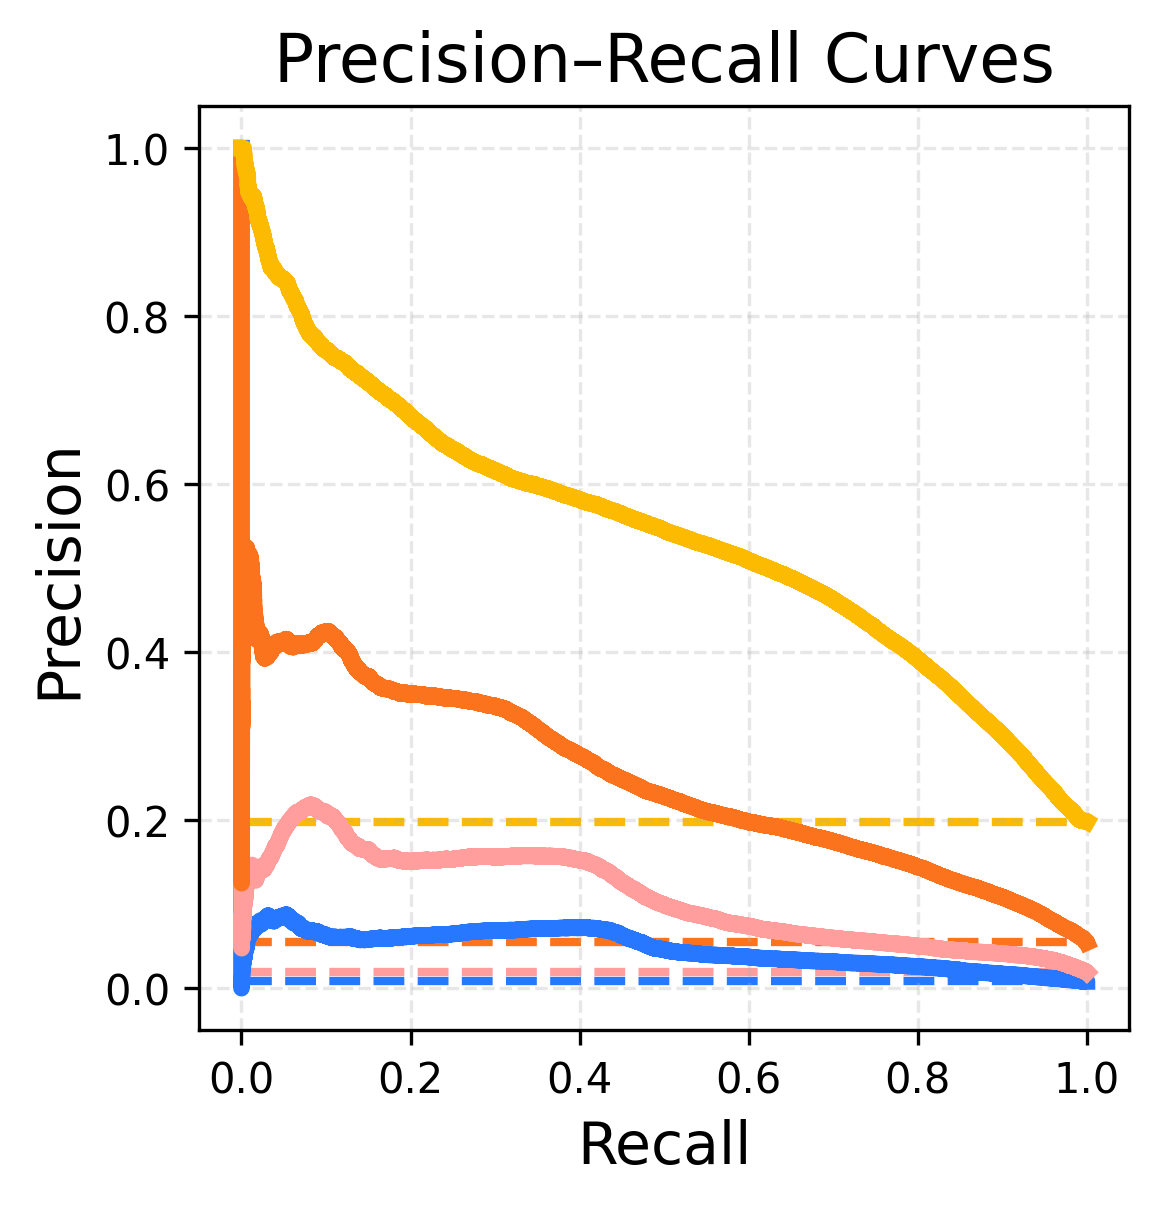

8 8 8


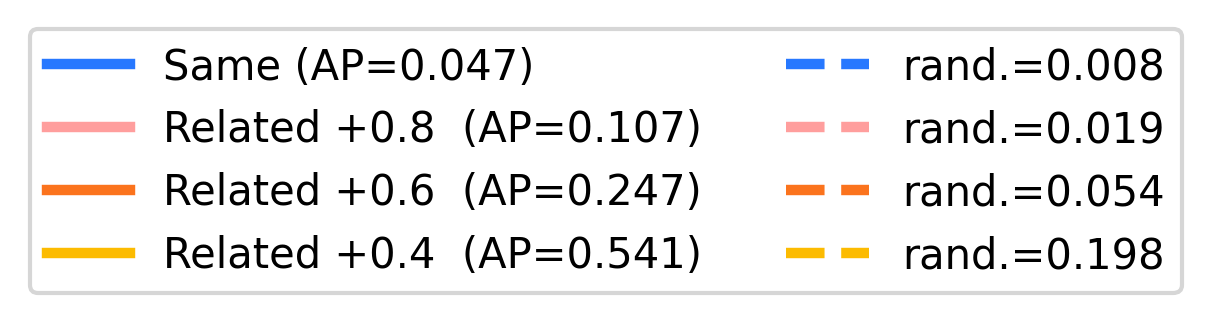

In [366]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# def encode_true_relations(y_doids, all_doids, rel_map_single_threshold):
#     N = len(y_doids)
#     D = len(all_doids)
#     y_true_bin = np.zeros((N, D), dtype=np.int8)

#     for i in range(N):
#         q = y_doids[i]
#         related_set = rel_map_single_threshold.get(q, set())
#         for j, d in enumerate(all_doids):
#             y_true_bin[i, j] = int(d in related_set)

#     return y_true_bin


# ---------------------------------------------------------
# Compute PR curve
# ---------------------------------------------------------
def compute_pr_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    precision, recall, thresholds = precision_recall_curve(y_true_flat, y_scores_flat)
    ap = average_precision_score(y_true_flat, y_scores_flat)

    return precision, recall, thresholds, ap


def plot_multi_pr_curves(y_prob, y_test_doids,df_query,  all_doids, rel_map, thresholds_to_plot, colors:List=None):
    """
    thresholds_to_plot: e.g. [0.396, 0.6, 0.8]
    """

    plt.figure(figsize=(4, 4), dpi=300)

    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(thresholds_to_plot)))
    
    labels_1 = list()
    labels_2 = list()

    for idx, thr in enumerate(thresholds_to_plot):
        # 1. Build binary ground truth
        # if thr == 1.0:
        #     # only exact matches
        #     y_true_bin = ut.get_multilabel_y(df_query, all_doids, rel_map, set_related_pos=False)
        # else:
        #     # include related diseases as positives
        #     y_true_bin = ut.get_multilabel_y(df_query, all_doids, rel_map, set_related_pos=True, thr_related=thr)
        y_true_bin = ut.get_multilabel_y(df_query, all_doids, rel_map, thr)

        # 2. Compute PR curve
        precision, recall, _, ap = compute_pr_curve(y_prob, y_true_bin)

        # 3. Plot PR curve
        plt.plot(
            recall, precision,
            label=f"thr={thr}  (AP={ap:.3f})",
            color=colors[idx],
            linewidth=4,
            zorder = 10
        )

        # 4. Add random baseline (horizontal line)
        random_prec = y_true_bin.mean()    # fraction of positives
        plt.hlines(
            y=random_prec,
            xmin=0, xmax=1,
            colors=colors[idx],
            linestyles='dashed',
            linewidth=2,
            label=f"random thr={thr} ({random_prec:.3f})",
            zorder=-3
        )
        labels_1.append(f"Same (AP={ap:.3f})" if thr == 1.0 else f"Related +{0.4 if thr == 0.396 else thr}  (AP={ap:.3f})")
        labels_2.append(f"rand.={random_prec:.3f}" if thr == 1.0 else f"rand.={random_prec:.3f}")


    plt.xlabel("Recall", fontsize=14)
    plt.ylabel("Precision", fontsize=14)
    plt.title("Precision–Recall Curves", fontsize=16)
    plt.grid(True, alpha=0.3, zorder=-5, linestyle='--')
    plt.show()
    return labels_1 + labels_2

def plot_legend_only(labels, colors, ncols=1, figsize=(6,2)):
    """
    Creates a standalone legend figure with no plot.
    
    labels      : list of strings
    colors      : list of colors (same length as labels)
    linestyles  : list like ["solid", "dashed", ...] or None
    """
    # Create a dummy artist (line) for every legend entry
    linestyles = ["solid"]*len(colors) + ["dashed"]*len(colors)

    colors = colors + colors 

    print(len(labels), len(colors), len(linestyles))

    handles = [
        Line2D([0], [0], color=colors[i], linestyle=linestyles[i], linewidth=2.5)
        for i in range(len(labels))
    ]
    
    fig = plt.figure(figsize=figsize, dpi=300)
    ax = fig.add_subplot(111)
    ax.axis("off")  # Hide axes completely
    
    fig.legend(
        handles,
        labels,
        loc="center",
        ncol=ncols,
        frameon=True,
    )

    plt.tight_layout()
    plt.show()


thresholds_to_plot = [1.0,0.8,0.6,0.396]

labels = plot_multi_pr_curves(
    y_prob=y_test_scores,
    y_test_doids=df_test["doid_id"].to_list(),
    df_query=df_test,
    all_doids=all_doids,
    rel_map=rel_map,
    thresholds_to_plot=thresholds_to_plot,
    colors=["#2778ff","#ff9e9d", "#fb731d", "#fcbb01","grey"]
)

plot_legend_only(
    labels=labels,
    colors=["#2778ff","#ff9e9d", "#fb731d", "#fcbb01"],
    ncols=2,
    figsize=(1,1)
)


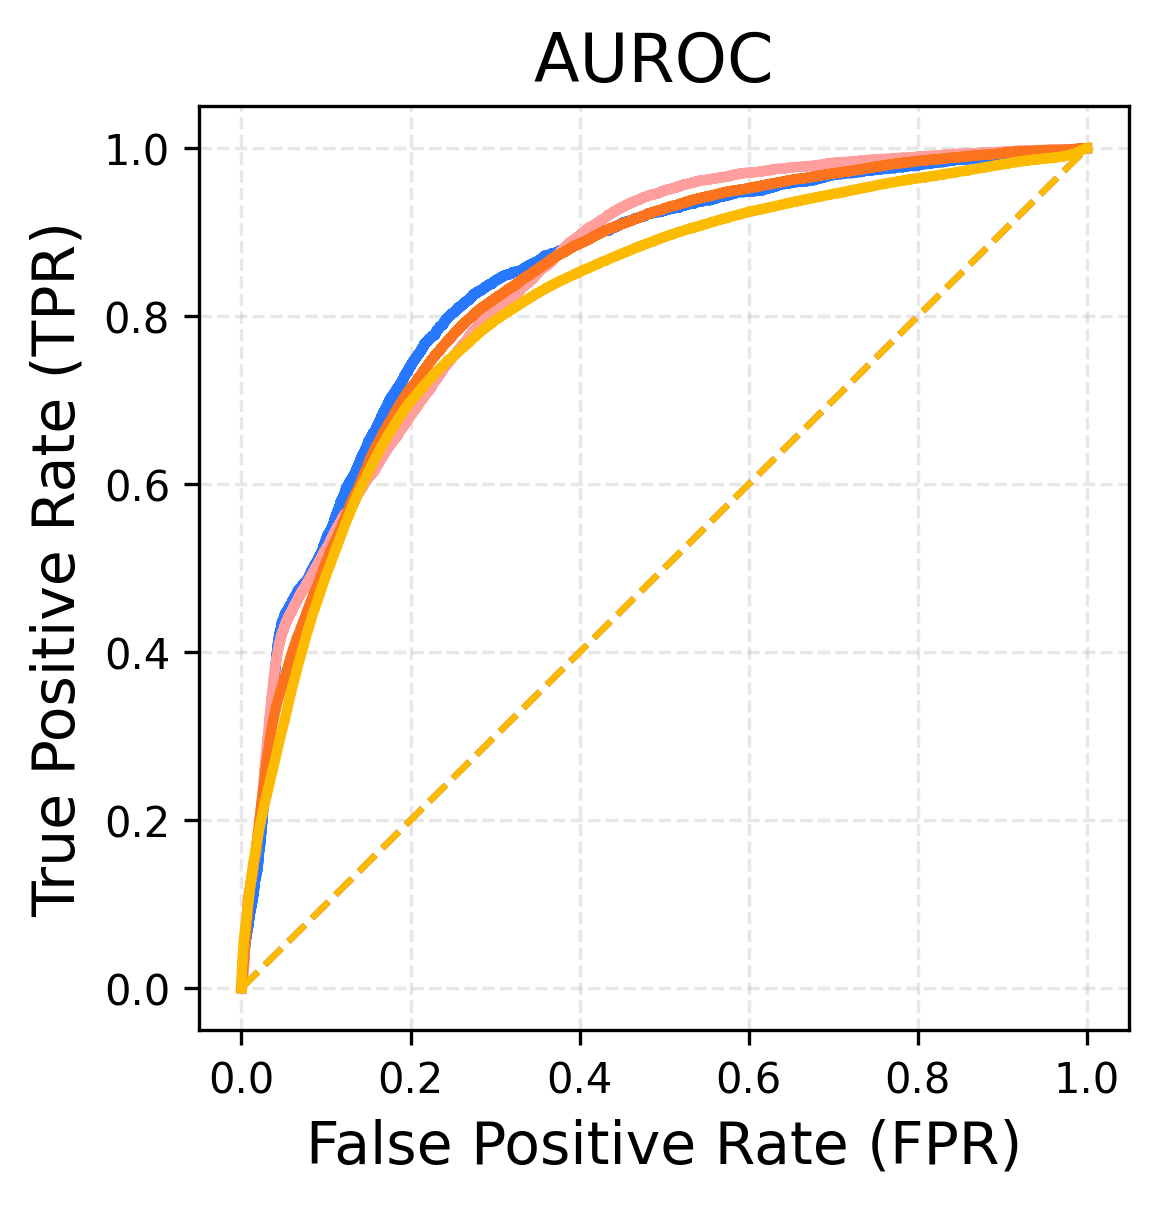

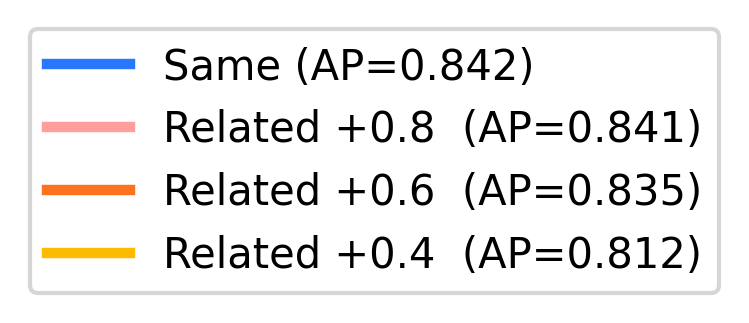

In [367]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
from matplotlib.lines import Line2D


# ---------------------------------------------------------
# Function: compute ROC curve
# ---------------------------------------------------------
def compute_roc_curve(y_prob, y_true_bin):
    """
    y_prob: (N, D) continuous predictions
    y_true_bin: (N, D) binary relevance matrix
    """
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    fpr, tpr, thresholds = roc_curve(y_true_flat, y_scores_flat)
    auc_val = auc(fpr, tpr)

    return fpr, tpr, thresholds, auc_val


# ---------------------------------------------------------
# Multi–ROC plotting (like your PR version)
# ---------------------------------------------------------
def plot_multi_roc_curves(
    y_prob,
    df_query,
    all_doids,
    rel_map,
    thresholds_to_plot,
    colors=None
):
    plt.figure(figsize=(4, 4), dpi=300)

    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(thresholds_to_plot)))

    labels_main = []
    labels_rand = []

    for idx, thr in enumerate(thresholds_to_plot):
        
        # 1. Build multilabel truth vector
        # if thr == 1.0:
        #     # exact same disease only
        #     y_true_bin = ut.get_multilabel_y(
        #         df_query, all_doids, rel_map, set_related_pos=False
        #     )
        # else:
        y_true_bin = ut.get_multilabel_y(
            df_query, all_doids, rel_map, thr_related=thr
        )

        # 2. Compute ROC
        fpr, tpr, _, auc_val = compute_roc_curve(y_prob, y_true_bin)

        # 3. Plot ROC curve
        plt.plot(
            fpr,
            tpr,
            label=f"thr={thr} (AUC={auc_val:.3f})",
            color=colors[idx],
            linewidth=2.5
        )

        # 4. Random baseline (diagonal)
        plt.plot(
            [0, 1],
            [0, 1],
            linestyle="dashed",
            color=colors[idx],
            linewidth=1.5,
        )
        labels_main.append(f"Same (AP={auc_val:.3f})" if thr == 1.0 else f"Related +{0.4 if thr == 0.396 else thr}  (AP={auc_val:.3f})")
        # labels_rand.append("Random baseline")

    plt.xlabel("False Positive Rate (FPR)", fontsize=14)
    plt.ylabel("True Positive Rate (TPR)", fontsize=14)
    plt.title("AUROC ", fontsize=16)
    plt.grid(True, alpha=0.3, zorder=-5, linestyle='--')
    plt.show()

    return labels_main + labels_rand


# ---------------------------------------------------------
# Standalone legend (same system as your PR version)
# ---------------------------------------------------------
def plot_legend_only(labels, colors, ncols=1, figsize=(3, 2)):
    """
    Creates a standalone legend figure (no curves).
    """

    # linestyle: solid for main ROC, dashed for random baselines
    linestyles = ["solid"] * len(colors) + ["dashed"] * len(colors)
    colors = colors + colors

    handles = [
        Line2D(
            [0], [0],
            color=colors[i],
            linestyle=linestyles[i],
            linewidth=2.5
        )
        for i in range(len(labels))
    ]

    fig = plt.figure(figsize=figsize, dpi=300)
    ax = fig.add_subplot(111)
    ax.axis("off")

    fig.legend(
        handles,
        labels,
        loc="center",
        ncol=ncols,
        frameon=True,
    )

    plt.tight_layout()
    plt.show()

thresholds_to_plot = [1.0, 0.8, 0.6, 0.396]

labels = plot_multi_roc_curves(
    y_prob=y_test_scores,
    df_query=df_test,
    all_doids=all_doids,
    rel_map=rel_map,
    thresholds_to_plot=thresholds_to_plot,
    colors=["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"]
)

plot_legend_only(
    labels=labels,
    colors=["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"],
    ncols=1,
    figsize=(1, 1)
)


# 3. Regression: Predict Ontological Distance

## 3.1 Data Preparation

In [117]:
# imports
from tqdm import tqdm
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import classification_report
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

# variables
remove_related = False
remove_control = True
set_related_pos = False
custom_splits = False
unrel_thr = 0.396
unrel_thr = 0.0

# functions
def get_mapping_do_sim(do_df_ic:pd.DataFrame, dis_order:List[str], unrel_thr:float=0.0)->Dict:

    do_df_ic_filt = do_df_ic.query("do1 in @dis_order and do2 in @dis_order")
    doid_to_sim = dict()
    for _, r in do_df_ic_filt.iterrows():
        _do1 = r["do1"]
        _do2 = r["do2"]
        _sim = r["lin"]
        doid_to_sim[(_do1, _do2)] = _sim
        doid_to_sim[(_do2, _do1)] = _sim

    pair_sim = dict()
    for d1 in tqdm(dis_order):
        _sim = list()
        for d2 in dis_order:
            if d1 == d2:
                _sim.append(1.0)
            elif (d1 == "Control") or (d2 == "Control"):
                _sim.append(0.0)
            else:
                _sim.append(doid_to_sim[d1, d2] if doid_to_sim[d1, d2]>unrel_thr else 0.0)
        pair_sim[d1] = _sim

    return pair_sim

def get_df_pred(y_prob, y_doids, all_doids):
    results = []
    all_doids = np.array(all_doids)
    for i in range(y_prob.shape[0]):
        y_prob_i = y_prob[i]
        y_doids_i = y_doids[i]  
        
        results.append({
            "query_doid":y_doids_i,
            "top_1":all_doids[np.argsort(y_prob_i)[-1:][::-1]].tolist(),
            "top_3":all_doids[np.argsort(y_prob_i)[-3:][::-1]].tolist(),
            "top_5":all_doids[np.argsort(y_prob_i)[-5:][::-1]].tolist(),
            "top_10":all_doids[np.argsort(y_prob_i)[-10:][::-1]].tolist(),
            "+0.4":all_doids[y_prob_i >= 0.39].tolist(),
            "+0.5":all_doids[y_prob_i >= 0.5].tolist(),
            "+0.6":all_doids[y_prob_i >= 0.6].tolist(),
            "+0.7":all_doids[y_prob_i >= 0.7].tolist(),
            "+0.8":all_doids[y_prob_i >= 0.8].tolist(),
            "+0.9":all_doids[y_prob_i >= 0.9].tolist(),
        })


    return pd.DataFrame(results)

def get_df_performance(dfs_conds:List[Tuple[pd.DataFrame]], rel_map:Dict, n_labels:int)->pd.DataFrame:
    """Get performance metrics aggregated by diseases and by samples
    """
    perf_results = list()
    for _df, _condition in dfs_conds:
        for k in _df.columns[1:]:
            for thr in [0.396, 0.6, 0.8, 0.9]:
                # get counts
                _df_counts = get_counts(_df, rel_map[thr], k)
                _df_counts["random_baseline"] = _df_counts["n_total_unique"]*1/n_labels
                    
                # group by disease
                perf_results.append({
                    "Key": k,
                    "Across": "Diseases",
                    "Condition": _condition,
                    "Hits Same Disease": f"{_df_counts.groupby("query_doid")["hits_same"].mean().mean()*100:.1f}",
                    "Related Threshold": thr,
                    "Precision@K": f"{_df_counts.groupby('query_doid')['prec@k'].mean().mean()*100:.1f}",
                    "Recall@K": f"{_df_counts.groupby('query_doid')['recall@k'].mean().mean()*100:.1f}",    
                    "Size": f'{_df_counts["n_total"].mean():.0f}±{_df_counts["n_total"].std():.0f}' if _df_counts["n_total"].std() > 0 else f'{_df_counts["n_total"].mean():.0f}',
                    "Unique Size": f'{_df_counts["n_total_unique"].mean():.0f}±{_df_counts["n_total_unique"].std():.0f}' if _df_counts["n_total_unique"].std() > 0 else f'{_df_counts["n_total_unique"].mean():.0f}',
                    "Hits Related Disease": f"{_df_counts.groupby("query_doid")["hits_rel"].mean().mean()*100:.1f}",
                    "Random Baseline": f"{_df_counts.groupby('query_doid')['random_baseline'].mean().mean()*100:.1f}",
                })

                # across all samples
                perf_results.append({
                    "Key": k,
                    "Across": "Samples",
                    "Condition": _condition,
                    "Hits Same Disease": f"{_df_counts["hits_same"].mean()*100:.1f}",
                    "Related Threshold": thr,
                    "Precision@K": f"{_df_counts['prec@k'].mean()*100:.1f}",
                    "Recall@K": f"{_df_counts['recall@k'].mean()*100:.1f}",
                    "Size": f'{_df_counts["n_total"].mean():.0f}±{_df_counts["n_total"].std():.0f}' if _df_counts["n_total"].std() > 0 else f'{_df_counts["n_total"].mean():.0f}',
                    "Unique Size": f'{_df_counts["n_total_unique"].mean():.0f}±{_df_counts["n_total_unique"].std():.0f}' if _df_counts["n_total_unique"].std() > 0 else f'{_df_counts["n_total_unique"].mean():.0f}',
                    "Hits Related Disease": f"{_df_counts["hits_rel"].mean()*100:.1f}",
                    "Random Baseline": f"{_df_counts['random_baseline'].mean()*100:.1f}",
                })
    return pd.DataFrame(perf_results)
def custom_train_valid_split(df, random_state=42, remove_control:bool=False)->Tuple[np.ndarray, np.ndarray]:
    """
    For each disease:
      - If multiple datasets exist → split by dataset (1 dataset → valid)
        and also split CONTROL samples belonging to the same datasets.
      - Otherwise → split disease samples by individual rows (1 sample → valid).
    """
    rng = np.random.default_rng(random_state)
    train_idx, valid_idx = [], []

    if not remove_control:
        df_controls = df[df["doid_id"] == "Control"]

    valid_datasets = set()
    train_datasets = set()
    # Loop through diseases
    for doid in df["doid_id"].unique():
        if doid == "Control":
            continue  # df_controls handled when splitting real diseases
        
        df_do = df[df["doid_id"] == doid]
        datasets = df_do["dataset"].unique()

        n_overlap_valid = len(valid_datasets & set(datasets))
        if (n_overlap_valid>0) & (len(datasets)-n_overlap_valid)>0:   # if dataset already placed in valid set

            # place existing dataset in valid for this disease
            valid_idx.extend(df_do[df_do["dataset"].isin(valid_datasets)].index)
            train_idx.extend(df_do[~df_do["dataset"].isin(valid_datasets)].index)

        elif len(datasets)-n_overlap_valid > 1:
            rng.shuffle(list(datasets))
            new_valid_datasets = {d for d in datasets if d not in valid_datasets}  # datasets not already in valid
            new_valid_datasets = {list(new_valid_datasets)[0]}  # take one new dataset for valid
            new_train_datasets = set(datasets) - new_valid_datasets - valid_datasets

            # disease samples
            valid_idx.extend(df_do[df_do["dataset"].isin(new_valid_datasets)].index)
            train_idx.extend(df_do[df_do["dataset"].isin(new_train_datasets)].index)

            valid_datasets.update(new_valid_datasets)
            train_datasets.update(new_train_datasets)

            if not remove_control:
                # matching CONTROL samples for those datasets
                ctrl_valid = df_controls[df_controls["dataset"].isin(new_valid_datasets)].index
                ctrl_train = df_controls[df_controls["dataset"].isin(new_train_datasets)].index

                valid_idx.extend(ctrl_valid)
                train_idx.extend(ctrl_train)
        else:
            idx = df_do.index.to_numpy()
            rng.shuffle(idx)
            n_valid_ds = max(1, len(idx) // 6)
            valid_idx.append(idx[n_valid_ds-1])
            train_idx.extend(idx[n_valid_ds:])

            # controls for this dataset (if available)
            ds = df_do["dataset"].iloc[0]

            if not remove_control:            
                ctrl_ds = df_controls[df_controls["dataset"] == ds].index.to_numpy()

                if len(ctrl_ds) > 0:
                    rng.shuffle(ctrl_ds)
                    n_valid_ds = max(1, len(ctrl_ds) // 6)
                    valid_idx.append(ctrl_ds[n_valid_ds-1])
                    train_idx.extend(ctrl_ds[n_valid_ds:])

    return np.array(train_idx), np.array(valid_idx)

# prepare data
all_doids = sorted(adata_train.obs["doid_id"].unique())

df_train = adata_train.obs.copy()
df_valid = adata_valid.obs.copy()
df_test = adata_test.obs.copy()

e_train = embeddings_train
e_valid = embeddings_valid
e_test = embeddings_test

if remove_control:
    all_doids.remove("Control")

    mask_train = df_train["doid_id"] != "Control"
    mask_valid = df_valid["doid_id"] != "Control"
    mask_test = df_test["doid_id"] != "Control"

    df_train = df_train[mask_train].reset_index(drop=True)
    df_valid = df_valid[mask_valid].reset_index(drop=True)
    df_test = df_test[mask_test].reset_index(drop=True)

    e_train = e_train[mask_train.values]
    e_valid = e_valid[mask_valid.values]
    e_test = e_test[mask_test.values]


if custom_splits:
    df_train_all = pd.concat([df_train.reset_index(drop=True), df_valid.reset_index(drop=True)], axis=0)
    df_train_all = df_train_all.reset_index(drop=True)

    # RE-SPLIT TRAIN/VALIDATION SET
    train_idx, valid_idx = custom_train_valid_split(df_train_all, remove_control=remove_control)
    df_train = df_train_all.iloc[train_idx].reset_index(drop=True)
    df_valid = df_train_all.iloc[valid_idx].reset_index(drop=True)

    e_train_all = np.concatenate([e_train, e_valid], axis=0)
    e_train = e_train_all[train_idx]
    e_valid = e_train_all[valid_idx]

dis_order = df_train["doid_id"].unique()
print(f"Total dis_ordereases in training set: {len(dis_order)}")

# Encode labels
pair_sim = get_mapping_do_sim(do_df_ic, all_doids, unrel_thr=unrel_thr)
y_train = np.array([pair_sim[x] for x in df_train["doid_id"].values])
y_valid = np.array([pair_sim[x] for x in df_valid["doid_id"].values])
y_test = np.array([pair_sim[x] for x in df_test["doid_id"].values])

# multilabels
print(f"Nº of train samples: {df_train.shape[0]}\tNº of diseases: {len(df_train['doid_id'].unique())}")
print(f"Nº of validation samples: {df_valid.shape[0]}\tNº of diseases: {len(df_valid['doid_id'].unique())}")
print(f"Nº of test samples: {df_test.shape[0]}\tNº of diseases: {len(df_test['doid_id'].unique())}")


Total dis_ordereases in training set: 123


100%|██████████| 123/123 [00:00<00:00, 57881.68it/s]

Nº of train samples: 11823	Nº of diseases: 123
Nº of validation samples: 1314	Nº of diseases: 106
Nº of test samples: 3611	Nº of diseases: 123


## 3.2 Model: Linear Regression - N Independent Models

In [147]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# def encode_true_relations(y_doids, all_doids, rel_map_single_threshold):
#     N = len(y_doids)
#     D = len(all_doids)
#     y_true_bin = np.zeros((N, D), dtype=np.int8)

#     for i in range(N):
#         q = y_doids[i]
#         related_set = rel_map_single_threshold.get(q, set())
#         for j, d in enumerate(all_doids):
#             y_true_bin[i, j] = int(d in related_set)

#     return y_true_bin


# ---------------------------------------------------------
# Compute PR curve
# ---------------------------------------------------------
def compute_pr_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    precision, recall, thresholds = precision_recall_curve(y_true_flat, y_scores_flat)
    ap = average_precision_score(y_true_flat, y_scores_flat)

    return precision, recall, thresholds, ap


def plot_multi_pr_curves(y_prob, y_test_doids,df_query,  all_doids, rel_map, thresholds_to_plot, colors:List=None):
    """
    thresholds_to_plot: e.g. [0.396, 0.6, 0.8]
    """

    plt.figure(figsize=(4, 4), dpi=300)

    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(thresholds_to_plot)))
    
    labels_1 = list()
    labels_2 = list()

    for idx, thr in enumerate(thresholds_to_plot):
        # 1. Build binary ground truth
        # if thr == 1.0:
        #     # only exact matches
        #     y_true_bin = ut.get_multilabel_y(df_query, all_doids, rel_map, set_related_pos=False)
        # else:
        #     # include related diseases as positives
        #     y_true_bin = ut.get_multilabel_y(df_query, all_doids, rel_map, set_related_pos=True, thr_related=thr)
        y_true_bin = ut.get_multilabel_y(df_query, all_doids, rel_map, thr)

        # 2. Compute PR curve
        precision, recall, _, ap = compute_pr_curve(y_prob, y_true_bin)

        # 3. Plot PR curve
        plt.plot(
            recall, precision,
            label=f"thr={thr}  (AP={ap:.3f})",
            color=colors[idx],
            linewidth=4,
            zorder = 10
        )

        # 4. Add random baseline (horizontal line)
        random_prec = y_true_bin.mean()    # fraction of positives
        plt.hlines(
            y=random_prec,
            xmin=0, xmax=1,
            colors=colors[idx],
            linestyles='dashed',
            linewidth=2,
            label=f"random thr={thr} ({random_prec:.3f})",
            zorder=-3
        )
        labels_1.append(f"Same (AP={ap:.3f})" if thr == 1.0 else f"thr={thr}  (AP={ap:.3f})")
        labels_2.append(f"rand. precision={random_prec:.3f}" if thr == 1.0 else f"rand. precision={random_prec:.3f}")


    plt.xlabel("Recall", fontsize=14)
    plt.ylabel("Precision", fontsize=14)
    plt.title("Precision–Recall Curves", fontsize=16)
    plt.grid(True, alpha=0.3, zorder=-5, linestyle='--')
    plt.show()
    return labels_1 + labels_2

def plot_legend_only(labels, colors, ncols=1, figsize=(6,2)):
    """
    Creates a standalone legend figure with no plot.
    
    labels      : list of strings
    colors      : list of colors (same length as labels)
    linestyles  : list like ["solid", "dashed", ...] or None
    """
    # Create a dummy artist (line) for every legend entry
    linestyles = ["solid"]*len(colors) + ["dashed"]*len(colors)

    colors = colors + colors 

    print(len(labels), len(colors), len(linestyles))

    handles = [
        Line2D([0], [0], color=colors[i], linestyle=linestyles[i], linewidth=2.5)
        for i in range(len(labels))
    ]
    
    fig = plt.figure(figsize=figsize, dpi=300)
    ax = fig.add_subplot(111)
    ax.axis("off")  # Hide axes completely
    
    fig.legend(
        handles,
        labels,
        loc="center",
        ncol=ncols,
        frameon=False,
    )

    plt.tight_layout()
    plt.show()


In [150]:
import torch

class TorchLinearRegression:
    def __init__(self, device="cuda"):
        self.device = device
        self.weight = None
        self.bias = None

    def fit(self, X, Y):
        # X: (N, D), Y: (N, M)
        X = X.to(self.device)
        Y = Y.to(self.device)

        # Add bias column: Xb = [X | 1]
        ones = torch.ones((X.shape[0], 1), device=self.device)
        Xb = torch.cat([X, ones], dim=1)  # shape (N, D+1)

        # Solve (X^T X)W = X^T Y
        XtX = Xb.T @ Xb
        XtY = Xb.T @ Y

        # Solve weights using torch.linalg
        W = torch.linalg.solve(XtX, XtY)  # shape (D+1, M)

        # Split bias & weights
        self.weight = W[:-1, :]    # (D, M)
        self.bias   = W[-1, :].unsqueeze(0)  # (1, M)

    def predict(self, X):
        X = X.to(self.device)
        return X @ self.weight + self.bias


device = "cuda"

# convert numpy → torch
e_train_t = torch.tensor(e_train, dtype=torch.float32, device=device)
e_valid_t = torch.tensor(e_valid, dtype=torch.float32, device=device)
e_test_t  = torch.tensor(e_test,  dtype=torch.float32, device=device)

y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
y_valid_t = torch.tensor(y_valid, dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32, device=device)

# define model
model = TorchLinearRegression(device=device)

# train
model.fit(e_train_t, y_train_t)

# evaluate
y_train_pred_t = model.predict(e_train_t)
y_valid_pred_t = model.predict(e_valid_t)
y_test_pred_t  = model.predict(e_test_t)


mse = torch.mean((y_test_pred_t - y_test_t) ** 2).item()
print(f"Test MSE: {mse:.4f}")


Test MSE: 0.1686


In [151]:
y_train_pred

array([[ 0.14029719,  0.05326118, -0.024307  , ..., -0.01533372,
        -0.04582914,  0.09518287],
       [ 0.14029719,  0.05326118, -0.024307  , ..., -0.01533372,
        -0.04582914,  0.09518287],
       [ 0.14029719,  0.05326118, -0.024307  , ..., -0.01533372,
        -0.04582914,  0.09518287],
       ...,
       [ 0.14029719,  0.05326118, -0.024307  , ..., -0.01533372,
        -0.04582914,  0.09518287],
       [ 0.14029719,  0.05326118, -0.024307  , ..., -0.01533372,
        -0.04582914,  0.09518287],
       [ 0.14029719,  0.05326118, -0.024307  , ..., -0.01533372,
        -0.04582914,  0.09518287]], dtype=float32)

In [153]:
y_train_pred_t.cpu().numpy()

array([[0.10066765, 0.09295374, 0.13769007, ..., 0.09685393, 0.06762619,
        0.42154542],
       [0.10264967, 0.19198498, 0.12581336, ..., 0.15127762, 0.35606778,
        0.09450371],
       [0.1816597 , 0.18121731, 0.25497168, ..., 0.20839071, 0.20725372,
        0.07318505],
       ...,
       [0.49819946, 0.1949855 , 0.14816532, ..., 0.09005076, 0.2739119 ,
        0.10429296],
       [0.24382508, 0.08773065, 0.1653737 , ..., 0.07208465, 0.1015954 ,
        0.2910361 ],
       [0.11962631, 0.13403954, 0.08369619, ..., 0.59758705, 0.39478332,
        0.03305604]], dtype=float32)

In [120]:
# define model
clf = LinearRegression()  

# train
model = MultiOutputRegressor(clf, n_jobs=8)
model.fit(e_train, y_train)

# evaluate
y_train_pred = model.predict(e_train)
y_valid_pred = model.predict(e_valid)
y_test_pred = model.predict(e_test)

# get MSE
mse = mean_squared_error(y_test, y_test_pred)
print(f"Test MSE: {mse:.4f}")


Test MSE: 0.1688


In [123]:
from utils_exp import utils as ut

In [154]:
def compute_pr_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    precision, recall, thresholds = precision_recall_curve(y_true_flat, y_scores_flat)
    ap = average_precision_score(y_true_flat, y_scores_flat)

    return precision, recall, thresholds, ap

def compute_auroc_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    auroc = roc_auc_score(y_true_flat, y_scores_flat)

    return auroc

def get_precision_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]  # shape (N_samples, k)
    return (y_topk.sum(axis=1) / k).mean()


def get_hit_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]
    # Hit@k = fraction of samples where at least 1 correct disease is in top k
    return (y_topk.sum(axis=1) > 0).mean()


data = list()
for threshold in [1.0, 0.8, 0.6, 0.396]:
    for split_type in ["Test", "Validation", "Train"]:
    

        if split_type == "Test":
            _y_multilab = ut.get_multilabel_y(df_test, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_test_pred_t.cpu().numpy()
        elif split_type == "Validation":
            _y_multilab = ut.get_multilabel_y(df_valid, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_valid_pred_t.cpu().numpy()
        else:
            _y_multilab = ut.get_multilabel_y(df_train, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_train_pred_t.cpu().numpy()


        _prec, _recall, _, _ap = compute_pr_curve(
            _y_pred, _y_multilab
        )
        _auroc = compute_auroc_curve(_y_pred, _y_multilab)
        
        if threshold == 1.0:
            _hit_at_1 = get_hit_at_k(_y_pred, _y_multilab, 1)
            _hit_at_3 = get_hit_at_k(_y_pred, _y_multilab, 3)
            _hit_at_5 = get_hit_at_k(_y_pred, _y_multilab, 5)

        else:
            _prec_at_1 = get_precision_at_k(_y_pred, _y_multilab, 1)
            _prec_at_3 = get_precision_at_k(_y_pred, _y_multilab, 3)
            _prec_at_5 = get_precision_at_k(_y_pred, _y_multilab, 5)

        data.append({
            "Prediction": "Same Disease" if threshold==1.0 else f"Related +0.4" if threshold==0.396 else f"Related +{threshold}",
            "Split": f"{split_type}",
            "AUROC": f"{_auroc:.3f}",
            "AP": f"{_ap:.3f} ",
            "Random": f"{_y_multilab.mean():.3f}",
            "Hit/Precision@1": f"{_hit_at_1:.3f}" if threshold==1.0 else f"{_prec_at_1:.3f}",
            "Hit/Precision@3": f"{_hit_at_3:.3f}" if threshold==1.0 else f"{_prec_at_3:.3f}",
            "Hit/Precision@5": f"{_hit_at_5:.3f}" if threshold==1.0 else f"{_prec_at_5:.3f}",
        })

In [ ]:
# PT Embeddings 
pd.DataFrame(data)

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5
0,Same Disease,Test,0.802,0.055,0.008,0.062,0.236,0.391
1,Same Disease,Validation,0.940,0.376,0.008,0.711,0.795,0.840
2,Same Disease,Train,0.949,0.387,0.008,0.743,0.830,0.871
3,Related +0.8,Test,0.853,0.158,0.019,0.204,0.186,0.176
4,Related +0.8,Validation,0.957,0.618,0.016,0.740,0.494,0.340
5,Related +0.8,Train,0.961,0.638,0.016,0.769,0.509,0.348
6,Related +0.6,Test,0.863,0.336,0.055,0.384,0.367,0.354
7,Related +0.6,Validation,0.945,0.610,0.041,0.802,0.730,0.612
8,Related +0.6,Train,0.950,0.626,0.041,0.819,0.750,0.622
9,Related +0.4,Test,0.901,0.771,0.200,0.704,0.670,0.672


In [100]:
# FT Embeddings - old
pd.DataFrame(data)

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5
0,Same Disease,Test,0.814,0.073,0.008,0.079,0.248,0.432
1,Same Disease,Validation,0.985,0.678,0.008,0.885,0.935,0.957
2,Same Disease,Train,0.990,0.708,0.008,0.910,0.960,0.978
3,Related +0.8,Test,0.871,0.203,0.019,0.253,0.231,0.209
4,Related +0.8,Validation,0.988,0.859,0.016,0.899,0.569,0.379
5,Related +0.8,Train,0.992,0.886,0.016,0.922,0.581,0.386
6,Related +0.6,Test,0.873,0.406,0.055,0.407,0.418,0.405
7,Related +0.6,Validation,0.983,0.850,0.041,0.932,0.859,0.721
8,Related +0.6,Train,0.988,0.871,0.041,0.947,0.877,0.737
9,Related +0.4,Test,0.907,0.782,0.200,0.746,0.679,0.684


In [105]:
# FT Embeddings - fixed 
pd.DataFrame(data)

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5
0,Same Disease,Test,0.814,0.073,0.008,0.079,0.248,0.432
1,Same Disease,Validation,0.985,0.678,0.008,0.885,0.935,0.957
2,Same Disease,Train,0.990,0.708,0.008,0.910,0.960,0.978
3,Related +0.8,Test,0.871,0.203,0.019,0.253,0.231,0.209
4,Related +0.8,Validation,0.988,0.859,0.016,0.899,0.569,0.379
5,Related +0.8,Train,0.992,0.886,0.016,0.922,0.581,0.386
6,Related +0.6,Test,0.873,0.406,0.055,0.407,0.418,0.405
7,Related +0.6,Validation,0.983,0.850,0.041,0.932,0.859,0.721
8,Related +0.6,Train,0.988,0.871,0.041,0.947,0.877,0.737
9,Related +0.4,Test,0.907,0.782,0.200,0.746,0.679,0.684


In [125]:
# Raw GEx
pd.DataFrame(data)

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5
0,Same Disease,Test,0.750,0.032,0.008,0.085,0.257,0.350
1,Same Disease,Validation,0.962,0.198,0.008,0.862,0.913,0.933
2,Same Disease,Train,0.979,0.540,0.008,0.940,0.964,0.971
3,Related +0.8,Test,0.792,0.091,0.019,0.239,0.217,0.177
4,Related +0.8,Validation,0.964,0.346,0.016,0.888,0.548,0.360
5,Related +0.8,Train,0.981,0.764,0.016,0.951,0.587,0.386
6,Related +0.6,Test,0.801,0.221,0.055,0.351,0.347,0.332
7,Related +0.6,Validation,0.950,0.456,0.041,0.914,0.799,0.655
8,Related +0.6,Train,0.976,0.763,0.041,0.960,0.867,0.718
9,Related +0.4,Test,0.810,0.588,0.200,0.631,0.607,0.599


In [155]:
# Raw GEx GPU
pd.DataFrame(data)

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5
0,Same Disease,Test,0.750,0.032,0.008,0.086,0.257,0.350
1,Same Disease,Validation,0.962,0.199,0.008,0.861,0.913,0.933
2,Same Disease,Train,0.979,0.539,0.008,0.940,0.964,0.971
3,Related +0.8,Test,0.792,0.091,0.019,0.240,0.218,0.177
4,Related +0.8,Validation,0.964,0.347,0.016,0.887,0.548,0.360
5,Related +0.8,Train,0.981,0.764,0.016,0.951,0.587,0.386
6,Related +0.6,Test,0.801,0.221,0.055,0.353,0.348,0.333
7,Related +0.6,Validation,0.950,0.457,0.041,0.914,0.799,0.656
8,Related +0.6,Train,0.976,0.763,0.041,0.960,0.868,0.718
9,Related +0.4,Test,0.810,0.588,0.200,0.633,0.607,0.600


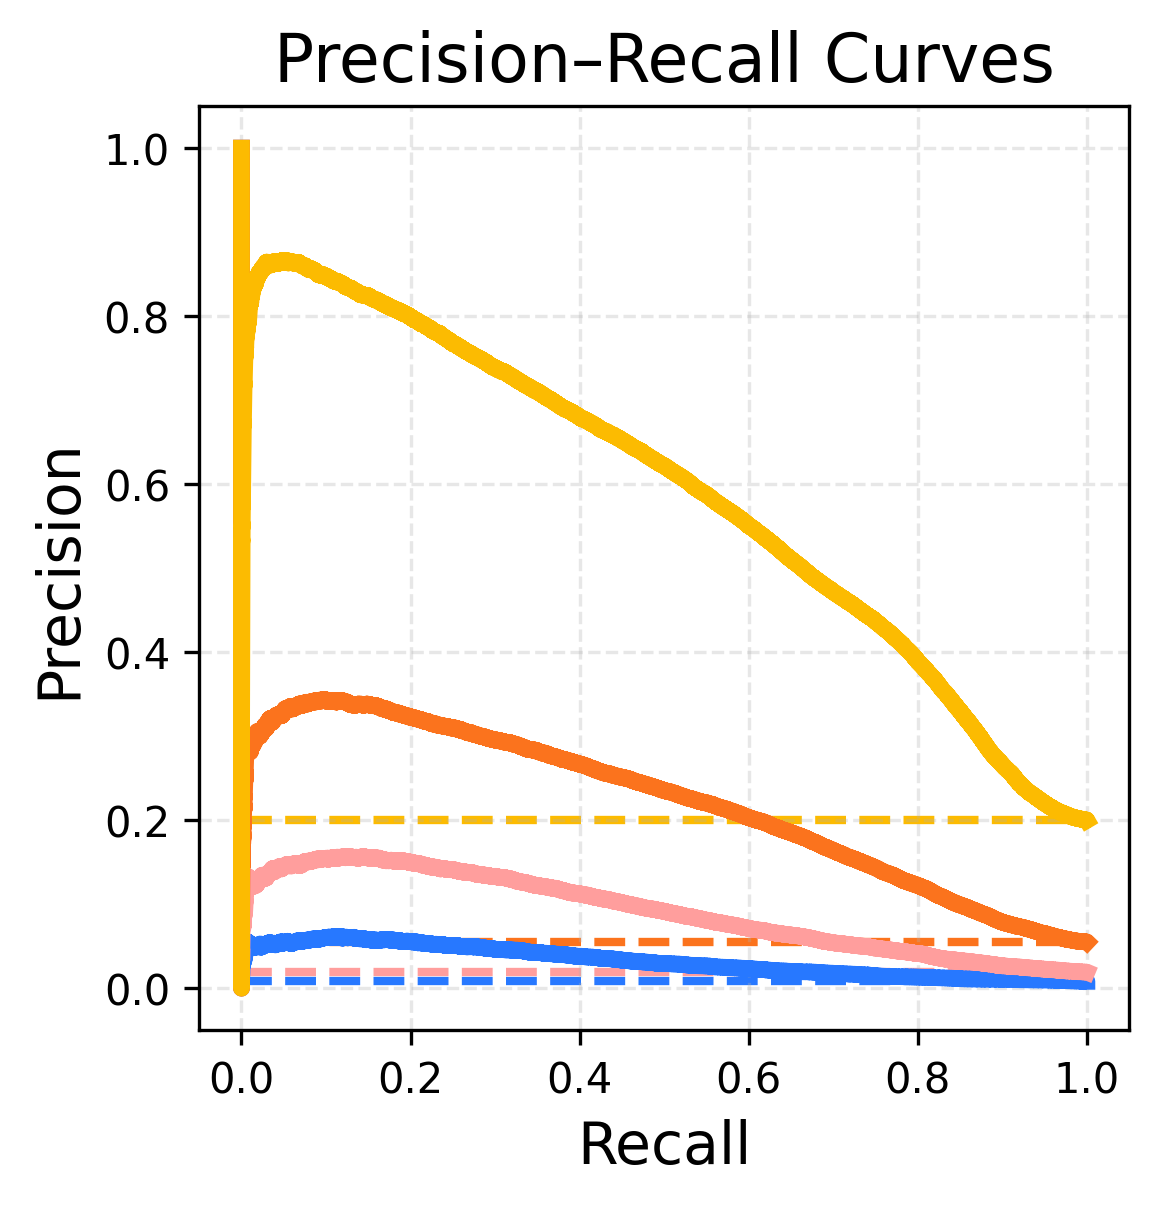

8 8 8


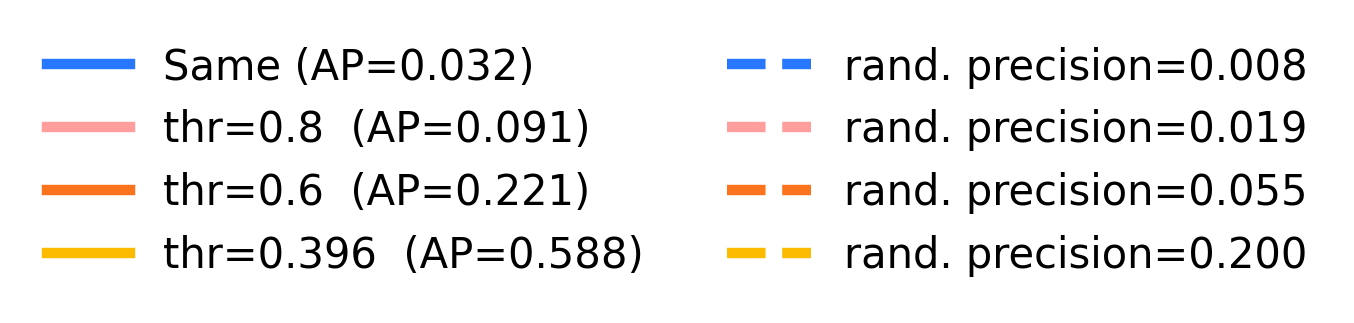

In [144]:
thresholds_to_plot = [1.0,0.8,0.6,0.396]

labels = plot_multi_pr_curves(
    y_prob=y_test_pred,
    y_test_doids=df_test["doid_id"].to_list(),
    df_query=df_test,
    all_doids=all_doids,
    rel_map=rel_map,
    thresholds_to_plot=thresholds_to_plot,
    colors=["#2778ff","#ff9e9d", "#fb731d", "#fcbb01","grey"]
)

plot_legend_only(
    labels=labels,
    colors=["#2778ff","#ff9e9d", "#fb731d", "#fcbb01"],
    ncols=2,
    figsize=(1,1)
)


In [ ]:
thresholds_to_plot = [1.0,0.8,0.6,0.396]

labels = plot_multi_pr_curves(
    y_valid_prob,
    df_valid["doid_id"].to_list(),
    df_query=df_valid,
    all_doids=all_doids,
    rel_map=rel_map,
    thresholds_to_plot=thresholds_to_plot,
    colors=["#2778ff","#ff9e9d", "#fb731d", "#fcbb01","grey"]
)

plot_legend_only(
    labels=labels,
    colors=["#2778ff","#ff9e9d", "#fb731d", "#fcbb01"],
    ncols=2,
    figsize=(1,1)
)


In [ ]:
thresholds_to_plot = [1.0,0.8,0.6,0.396]

labels = plot_multi_pr_curves(
    y_train_prob,
    df_train["doid_id"].to_list(),
    df_query=df_train,
    all_doids=all_doids,
    rel_map=rel_map,
    thresholds_to_plot=thresholds_to_plot,
    colors=["#2778ff","#ff9e9d", "#fb731d", "#fcbb01","grey"]
)

plot_legend_only(
    labels=labels,
    colors=["#2778ff","#ff9e9d", "#fb731d", "#fcbb01"],
    ncols=2,
    figsize=(1,1)
)


In [ ]:
df_pred_test = get_df_pred(y_test_prob,  df_test["doid_id"].to_list(), all_doids)

df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_test, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

In [ ]:
(e_ft_train)

In [ ]:
df_pred_valid = get_df_pred(y_valid_prob,  df_valid["doid_id"].to_list(), all_doids)

df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_valid, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

In [ ]:
df_pred_train = get_df_pred(y_train_prob,  df_train["doid_id"].to_list(), all_doids)

df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_train, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def compute_pr_curve(y_prob, y_true_bin):
    """
    y_prob: (N, D) continuous predictions
    y_true_bin: (N, D) binary relevance matrix
    """

    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    precision, recall, thresholds = precision_recall_curve(y_true_flat, y_scores_flat)
    ap = average_precision_score(y_true_flat, y_scores_flat)

    return precision, recall, thresholds, ap


def plot_pr_curve(precision, recall, ap):
    plt.figure(figsize=(8,6))
    plt.plot(recall, precision, label=f"PR curve (AP = {ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# 2. Compute PR curve
y_test_multilab = get_multilabel_y(df_test, all_doids, rel_map, set_related_pos=False)
precision, recall, thresholds, ap = compute_pr_curve(y_test_prob, y_test_multilab)

y_test_multilab = get_multilabel_y(df_test, all_doids, rel_map, set_related_pos=True, thr_related=0.396)
precision, recall, thresholds, ap = compute_pr_curve(y_test_prob, y_test_multilab)

y_test_multilab = get_multilabel_y(df_test, all_doids, rel_map, set_related_pos=True, thr_related=0.6)
precision, recall, thresholds, ap = compute_pr_curve(y_test_prob, y_test_multilab)

y_test_multilab = get_multilabel_y(df_test, all_doids, rel_map, set_related_pos=True, thr_related=0.8)
precision, recall, thresholds, ap = compute_pr_curve(y_test_prob, y_test_multilab)

# 3. Plot
plot_pr_curve(precision, recall, ap)


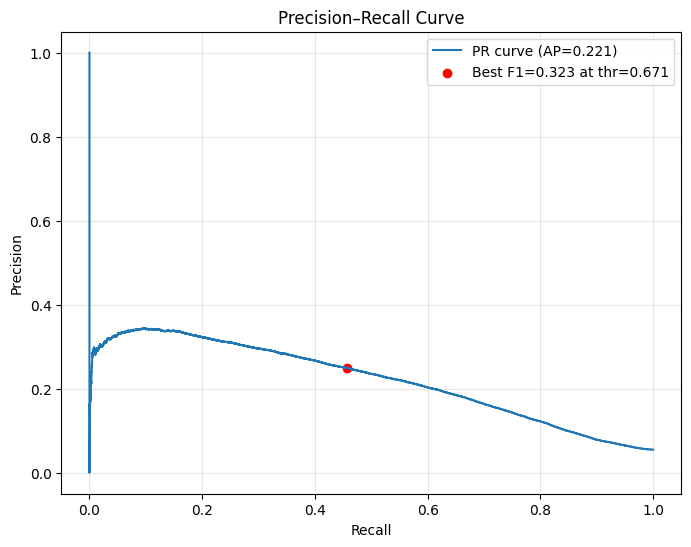

Optimal threshold: 0.6711075295099437
Best F1: 0.32282438724516865


In [131]:
def find_best_threshold(precision, recall, thresholds):
    """
    Find threshold that maximizes F1 = 2PR / (P+R)
    Note: PR curve returns len(thresholds)+1 points, so we align carefully.
    """
    f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
    
    # thresholds array has one fewer element
    # so we align f1[1:] with thresholds[:]
    best_idx = np.argmax(f1_scores[1:])
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx+1]

    return best_threshold, best_f1, f1_scores

def plot_pr_curve_with_opt(precision, recall, thresholds, ap):
    best_thr, best_f1, f1_scores = find_best_threshold(precision, recall, thresholds)

    plt.figure(figsize=(8,6))
    plt.plot(recall, precision, label=f"PR curve (AP={ap:.3f})")
    plt.scatter(recall[np.argmax(f1_scores)], precision[np.argmax(f1_scores)],
                color="red", label=f"Best F1={best_f1:.3f} at thr={best_thr:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def plot_pr_curve_with_opt(precision, recall, thresholds, ap):
    best_thr, best_f1, f1_scores = find_best_threshold(precision, recall, thresholds)

    plt.figure(figsize=(8,6))
    plt.plot(recall, precision, label=f"PR curve (AP={ap:.3f})")
    plt.scatter(recall[np.argmax(f1_scores)], precision[np.argmax(f1_scores)],
                color="red", label=f"Best F1={best_f1:.3f} at thr={best_thr:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


y_test_multilab = ut.get_multilabel_y(df_test, all_doids, rel_map, thr_related=0.6)

precision, recall, thresholds, ap = compute_pr_curve(y_test_pred, y_test_multilab)

plot_pr_curve_with_opt(precision, recall, thresholds, ap)

best_threshold, best_f1, _ = find_best_threshold(precision, recall, thresholds)
print("Optimal threshold:", best_threshold)
print("Best F1:", best_f1)


In [ ]:
import sklearn
sklearn.pairwise.cosine_similarity(e_train,e_train)

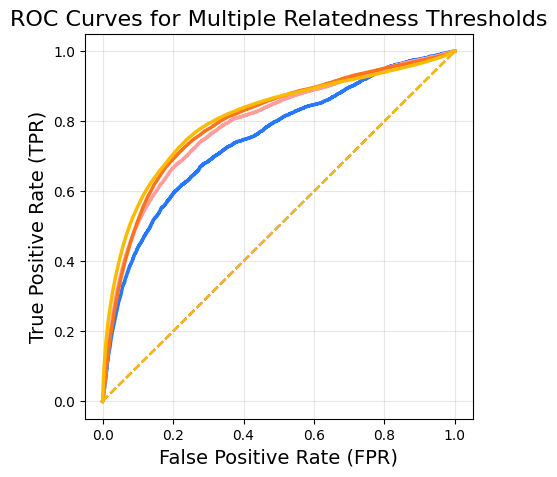

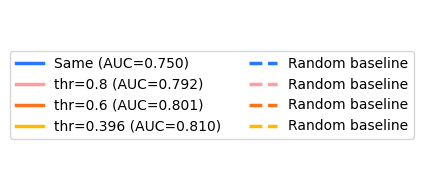

In [128]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
from matplotlib.lines import Line2D


# ---------------------------------------------------------
# Function: compute ROC curve
# ---------------------------------------------------------
def compute_roc_curve(y_prob, y_true_bin):
    """
    y_prob: (N, D) continuous predictions
    y_true_bin: (N, D) binary relevance matrix
    """
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    fpr, tpr, thresholds = roc_curve(y_true_flat, y_scores_flat)
    auc_val = auc(fpr, tpr)

    return fpr, tpr, thresholds, auc_val


# ---------------------------------------------------------
# Multi–ROC plotting (like your PR version)
# ---------------------------------------------------------
def plot_multi_roc_curves(
    y_prob,
    df_query,
    all_doids,
    rel_map,
    thresholds_to_plot,
    colors=None
):
    plt.figure(figsize=(5, 5))

    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(thresholds_to_plot)))

    labels_main = []
    labels_rand = []

    for idx, thr in enumerate(thresholds_to_plot):
        
        # 1. Build multilabel truth vector
        # if thr == 1.0:
        #     # exact same disease only
        #     y_true_bin = ut.get_multilabel_y(
        #         df_query, all_doids, rel_map, set_related_pos=False
        #     )
        # else:
        y_true_bin = ut.get_multilabel_y(
            df_query, all_doids, rel_map, thr_related=thr
        )

        # 2. Compute ROC
        fpr, tpr, _, auc_val = compute_roc_curve(y_prob, y_true_bin)

        # 3. Plot ROC curve
        plt.plot(
            fpr,
            tpr,
            label=f"thr={thr} (AUC={auc_val:.3f})",
            color=colors[idx],
            linewidth=2.5
        )

        # 4. Random baseline (diagonal)
        plt.plot(
            [0, 1],
            [0, 1],
            linestyle="dashed",
            color=colors[idx],
            linewidth=1.5,
        )

        labels_main.append(
            "Same (AUC={:.3f})".format(auc_val) if thr == 1.0 else f"thr={thr} (AUC={auc_val:.3f})"
        )
        labels_rand.append("Random baseline")

    plt.xlabel("False Positive Rate (FPR)", fontsize=14)
    plt.ylabel("True Positive Rate (TPR)", fontsize=14)
    plt.title("ROC Curves for Multiple Relatedness Thresholds", fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.show()

    return labels_main + labels_rand


# ---------------------------------------------------------
# Standalone legend (same system as your PR version)
# ---------------------------------------------------------
def plot_legend_only(labels, colors, ncols=1, figsize=(3, 2)):
    """
    Creates a standalone legend figure (no curves).
    """

    # linestyle: solid for main ROC, dashed for random baselines
    linestyles = ["solid"] * len(colors) + ["dashed"] * len(colors)
    colors = colors + colors

    handles = [
        Line2D(
            [0], [0],
            color=colors[i],
            linestyle=linestyles[i],
            linewidth=2.5
        )
        for i in range(len(labels))
    ]

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)
    ax.axis("off")

    fig.legend(
        handles,
        labels,
        loc="center",
        ncol=ncols,
        frameon=True,
    )

    plt.tight_layout()
    plt.show()

thresholds_to_plot = [1.0, 0.8, 0.6, 0.396]

labels = plot_multi_roc_curves(
    y_prob=y_test_pred,
    df_query=df_test,
    all_doids=all_doids,
    rel_map=rel_map,
    thresholds_to_plot=thresholds_to_plot,
    colors=["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"]
)

plot_legend_only(
    labels=labels,
    colors=["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"],
    ncols=2,
    figsize=(3, 2)
)


In [ ]:
df_pred_test = get_df_pred(y_test_prob,  df_test["doid_id"].to_list(), all_doids)

df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_test, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

In [ ]:
df_pred_test = get_df_pred(y_test_prob, df_test["doid_id"].to_list(), all_doids)

df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_test, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

## 3.3 Model: MLP Regression


In [145]:
# PyTorch multi-output regressor with weighted loss
# imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, precision_score
import torch.nn.functional as F
# variables
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
alpha_mse = 1.0
alpha_ce = 0.5
alpha_bce = 0.0
alpha_kl = 1.0
alpha_cos = 0.0
alpha_contr = 0.0
print("Using device:", device)

# functions
def build_weights(y: np.ndarray) -> np.ndarray:
    w = np.ones_like(y, dtype=np.float32)

    # same disease (1.0): high weight
    w[y >= 1.0] = 5.0

    # very high similarity (e.g. ≥ 0.8): moderate weight
    w[(y >= 0.8) & (y < 1)] = 3.5

    # medium similarity (e.g. 0.4–0.8): moderate weight
    mid_mask = (y >= 0.396) & (y < 0.8)
    w[mid_mask] = 2.0

    # unrelated (0): keep weight = 1.0
    return w

# Basic Model
# class MultiDiseaseRegressor(nn.Module):
#     def __init__(self, d_in: int, d_out: int, hidden: int = 256):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(d_in, hidden),
#             nn.ReLU(),
#             nn.Linear(hidden, hidden),
#             nn.ReLU(),
#             nn.Linear(hidden, d_out),
#         )

#     def forward(self, x):
#         return self.net(x)

# class MultiDiseaseRegressor(nn.Module):
#     def __init__(self, d_in: int, d_out: int, hidden: int = 256, dropout: float = 0.1):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(d_in, hidden),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(hidden, hidden),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(hidden, d_out),
#             # nn.Sigmoid(),  # since targets are in [0,1]
#         )

#     def forward(self, x):
#         return self.net(x)


# Model Expand to Small
class MultiDiseaseRegressor(nn.Module):
    def __init__(self, d_in: int, d_out: int, hidden: int = 256, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 512),
            # nn.ReLU(),
            # nn.Dropout(dropout),
            # nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, d_out),
            # nn.Sigmoid(),  # since targets are in [0,1]
        )

    def forward(self, x):
        return self.net(x)


# Residual Model
# class MultiDiseaseRegressor(nn.Module):
#     def __init__(self, d_in=512, d_out=124, hidden=512, dropout=0.1):
#         super().__init__()

#         self.fc1 = nn.Linear(d_in, hidden)
#         self.fc2 = nn.Linear(hidden, hidden)
#         self.fc3 = nn.Linear(hidden, d_out)

#         self.dropout = nn.Dropout(dropout)
#         self.act = nn.ReLU()

#     def forward(self, x):
#         h = self.act(self.fc1(x))
#         h2 = self.act(self.fc2(self.dropout(h)))

#         # residual skip connection
#         h = h + h2

#         out = self.fc3(h)
#         return out



def weighted_mse_loss(y_pred: torch.Tensor,
                      y_true: torch.Tensor,
                      weights: torch.Tensor) -> torch.Tensor:
    """
    y_pred, y_true, weights: shape (batch_size, n_diseases)
    """
    return ((weights * (y_pred - y_true) ** 2).mean())

def same_disease_contrastive_loss(y_pred, y_true, margin=0.2):
    """
    y_pred: (batch, num_diseases)  - predicted similarity scores
    y_true: (batch, num_diseases)  - true similarity scores (self = 1.0)
    """
    batch, D = y_pred.shape
    device = y_pred.device

    # index of the exact disease for each sample
    pos_index = torch.argmax(y_true, dim=1)   # shape (batch,)

    # scores for the correct disease
    pos_scores = y_pred[torch.arange(batch, device=device), pos_index]  # (batch,)

    # expand to compare with all diseases
    pos_expanded = pos_scores.unsqueeze(1).expand(-1, D)

    # margin violation: we want pos >= neg + margin
    diff = y_pred - pos_expanded + margin

    # do NOT penalize comparing the positive with itself
    diff[torch.arange(batch, device=device), pos_index] = 0.0

    # hinge
    loss = torch.clamp(diff, min=0).mean()
    return loss

# -----------------------------
# POSITIVE-ONLY CE LOSS
# -----------------------------
def positive_only_ce(y_pred, y_true_idx):
    """
    Only pushes the correct class upward.
    Does NOT penalize incorrect diseases.
    """
    pos_scores = y_pred[torch.arange(y_pred.size(0)), y_true_idx]  # (batch,)
    target = torch.ones_like(pos_scores)
    return F.binary_cross_entropy_with_logits(pos_scores, target)


# build weights
w_train = build_weights(y_train)
w_valid = build_weights(y_valid)  

# create dataloaders
X_train_t = torch.from_numpy(e_train).float()
Y_train_t = torch.from_numpy(y_train).float()
W_train_t = torch.from_numpy(w_train).float()

train_ds = TensorDataset(X_train_t, Y_train_t, W_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=False)

model = MultiDiseaseRegressor(e_train.shape[1], y_train.shape[1], hidden=256).to(device)
print(f"Model: input dim = {e_train.shape[1]}, output dim = {y_train.shape[1]}")


# optimizer & training hyperparams 
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)
n_epochs = 200

ce_loss_fn = nn.CrossEntropyLoss()
bce_loss_fn = nn.BCEWithLogitsLoss()

# training
model.train()
patience = 20
best_val_loss = float("inf")
for epoch in range(1, n_epochs + 1):
    running_loss = 0.0
    n_samples_seen = 0

    for xb, yb, wb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        wb = wb.to(device)

        optimizer.zero_grad()
        y_pred = model(xb)
        
        # MSE loss
        # Logic: Pointwise Accuracy
        mse_loss = weighted_mse_loss(y_pred, yb, wb)
        
        # KL divergence loss
        # Logic: Local Peaks - Helps with Ranking ?
        with torch.no_grad():
            p_true = F.softmax(yb / 0.07, dim=1)
        log_p_pred = F.log_softmax(y_pred / 0.07, dim=1)
        kl_loss = F.kl_div(log_p_pred, p_true, reduction='batchmean')


        # T = 2.0
        # with torch.no_grad():
        #     p_true = F.softmax(yb / T, dim=1)
        # log_p_pred = F.log_softmax(y_pred / T, dim=1)
        # kl_loss = F.kl_div(log_p_pred, p_true, reduction='batchmean') * (T*T)


        # Cosine similarity loss
        # Logic: Global Shape of Predictions
        cos_loss = 1 - F.cosine_similarity(y_pred, yb, dim=1).mean()

        # Contrastive Loss
        # Logic: Pull Similar Diseases Together
        contr_loss = same_disease_contrastive_loss(y_pred, yb)

        # Cross Entropy Loss
        # Logic: Top-1 Accuracy
        ce_loss = ce_loss_fn(y_pred, torch.argmax(yb, dim=1))

        # do not penalize other diseases
        ce_loss = positive_only_ce(y_pred, torch.argmax(yb, dim=1))


        # Binary Cross Entropy Loss
        # Logic: Multi-label Accuracy
        bce_loss_fn = nn.BCEWithLogitsLoss()
        target = (yb > 0.9).float()   # convert bool → float
        bce_loss = bce_loss_fn(y_pred, target)


        loss = alpha_mse * mse_loss + alpha_kl * kl_loss + alpha_cos * cos_loss + alpha_contr * contr_loss + alpha_ce * ce_loss + alpha_bce * bce_loss
        loss.backward()
        optimizer.step()

        batch_size = xb.size(0)
        running_loss += loss.item() * batch_size
        n_samples_seen += batch_size

    epoch_loss = running_loss / n_samples_seen

    if epoch % 10 == 0 or epoch == 1:
        print(f"TRAINING: Epoch {epoch:03d} | Loss: {epoch_loss:.6f} | MSE: {mse_loss.item():.6f} | KL: {kl_loss.item():.6f} | COS: {cos_loss.item():.6f} | CONTR: {contr_loss.item():.6f} | CE: {ce_loss.item():.6f} | BCE: {bce_loss.item():.6f}")

    # compute validation loss if desired
    with torch.no_grad():
        X_valid_t = torch.from_numpy(e_valid).float().to(device)
        Y_valid_t = torch.from_numpy(y_valid).float().to(device)
        W_valid_t = torch.from_numpy(w_valid).float().to(device)

        model.eval()
        y_valid_pred = model(X_valid_t)
        
        val_mse = mean_squared_error(Y_valid_t.cpu().numpy(), y_valid_pred.cpu().numpy())

        with torch.no_grad():
            p_true = F.softmax(Y_valid_t / 0.07, dim=1)
        log_p_pred = F.log_softmax(y_valid_pred / 0.07, dim=1)
        valid_kl_loss = F.kl_div(log_p_pred, p_true, reduction='batchmean')


        # T = 2.0
        # with torch.no_grad():
        #     p_true = F.softmax(yb / T, dim=1)
        # log_p_pred = F.log_softmax(y_pred / T, dim=1)
        # kl_loss = F.kl_div(log_p_pred, p_true, reduction='batchmean') * (T*T)



        val_cos_loss = 1 - F.cosine_similarity(y_valid_pred, Y_valid_t, dim=1).mean().item()

        val_contr_loss = same_disease_contrastive_loss(y_valid_pred, Y_valid_t).item()

        val_ce_loss = ce_loss_fn(y_valid_pred, torch.argmax(Y_valid_t, dim=1)).item()
        val_ce_loss = positive_only_ce(y_valid_pred, torch.argmax(Y_valid_t, dim=1)).item()

        val_bce_loss = bce_loss_fn(y_valid_pred, (Y_valid_t > 0.9).float()).item()

        val_loss = alpha_mse * val_mse + alpha_kl * valid_kl_loss + alpha_ce * val_ce_loss + alpha_cos * val_cos_loss + alpha_contr * val_contr_loss + alpha_bce * val_bce_loss

        scheduler.step(val_loss)
        model.train()
        if epoch % 10 == 0 or epoch == 1:
            print(f"VALIDATION: Epoch  {epoch:03d} | Loss: {epoch_loss:.6f} | MSE: {mse_loss.item():.6f} | KL: {kl_loss.item():.6f} | COS: {cos_loss.item():.6f} | CONTR: {contr_loss.item():.6f} | CE: {ce_loss.item():.6f} | BCE: {bce_loss.item():.6f}")
            # print("LR:", optimizer.param_groups[0]['lr'])

        # early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # keep best model
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break



# Inference: get predictions on train/valid/test
mode = model.load_state_dict(best_model_state)
model.eval()
with torch.no_grad():
    X_train_all = torch.from_numpy(e_train).float().to(device)
    X_valid_all = torch.from_numpy(e_valid).float().to(device)
    X_test_all  = torch.from_numpy(e_test).float().to(device)

    y_train_pred = model(X_train_all).cpu().numpy()
    y_valid_pred = model(X_valid_all).cpu().numpy()
    y_test_pred  = model(X_test_all).cpu().numpy()

# top k accuracies
def topk_accuracy(y_true, y_pred, k):
    topk = np.argsort(y_pred, axis=1)[:, -k:]
    correct = [1 if y_true[i] in topk[i] else 0 for i in range(y_true.shape[0])]
    return np.mean(correct) 

print("Top-1:", topk_accuracy(np.argmax(y_test, axis=1), y_test_pred, 1))
print("Top-5:", topk_accuracy(np.argmax(y_test, axis=1), y_test_pred, 5))
print("Top-10:", topk_accuracy(np.argmax(y_test, axis=1), y_test_pred, 10))
print(f"MSE VALID LOSS: {mean_squared_error(y_valid, y_valid_pred):.6f}")
print(f"MSE TEST LOSS: {mean_squared_error(y_test, y_test_pred):.6f}")

Using device: cuda
Model: input dim = 3501, output dim = 123
TRAINING: Epoch 001 | Loss: 949502.758756 | MSE: 0.156304 | KL: 4.307674 | COS: 0.912227 | CONTR: 0.200398 | CE: 0.693221 | BCE: 0.694222
VALIDATION: Epoch  001 | Loss: 949502.758756 | MSE: 0.156304 | KL: 4.307674 | COS: 0.912227 | CONTR: 0.200398 | CE: 0.693221 | BCE: 0.694222
TRAINING: Epoch 010 | Loss: 10.392367 | MSE: 0.169138 | KL: 3.852525 | COS: 0.885236 | CONTR: 0.173002 | CE: 0.680406 | BCE: 0.693192
VALIDATION: Epoch  010 | Loss: 10.392367 | MSE: 0.169138 | KL: 3.852525 | COS: 0.885236 | CONTR: 0.173002 | CE: 0.680406 | BCE: 0.693192
TRAINING: Epoch 020 | Loss: 5.664972 | MSE: 0.182576 | KL: 3.666457 | COS: 0.945977 | CONTR: 0.149181 | CE: 0.669682 | BCE: 0.692201
VALIDATION: Epoch  020 | Loss: 5.664972 | MSE: 0.182576 | KL: 3.666457 | COS: 0.945977 | CONTR: 0.149181 | CE: 0.669682 | BCE: 0.692201
TRAINING: Epoch 030 | Loss: 4.421452 | MSE: 0.170277 | KL: 3.563480 | COS: 0.940489 | CONTR: 0.124541 | CE: 0.657184 | B

In [ ]:
df_pred_test = get_df_pred(y_test_pred, df_test["doid_id"].to_list(), all_doids)
df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_test, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

In [ ]:
y_test_pred.max(axis=1)

In [ ]:
df_pred_valid = get_df_pred(y_valid_pred, df_valid["doid_id"].to_list(), all_doids)
df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_valid, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

In [ ]:
df_pred_train = get_df_pred(y_train_pred, df_train["doid_id"].to_list(), all_doids)
df_perf_results = get_df_performance(
    dfs_conds=[
        (df_pred_train, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_results

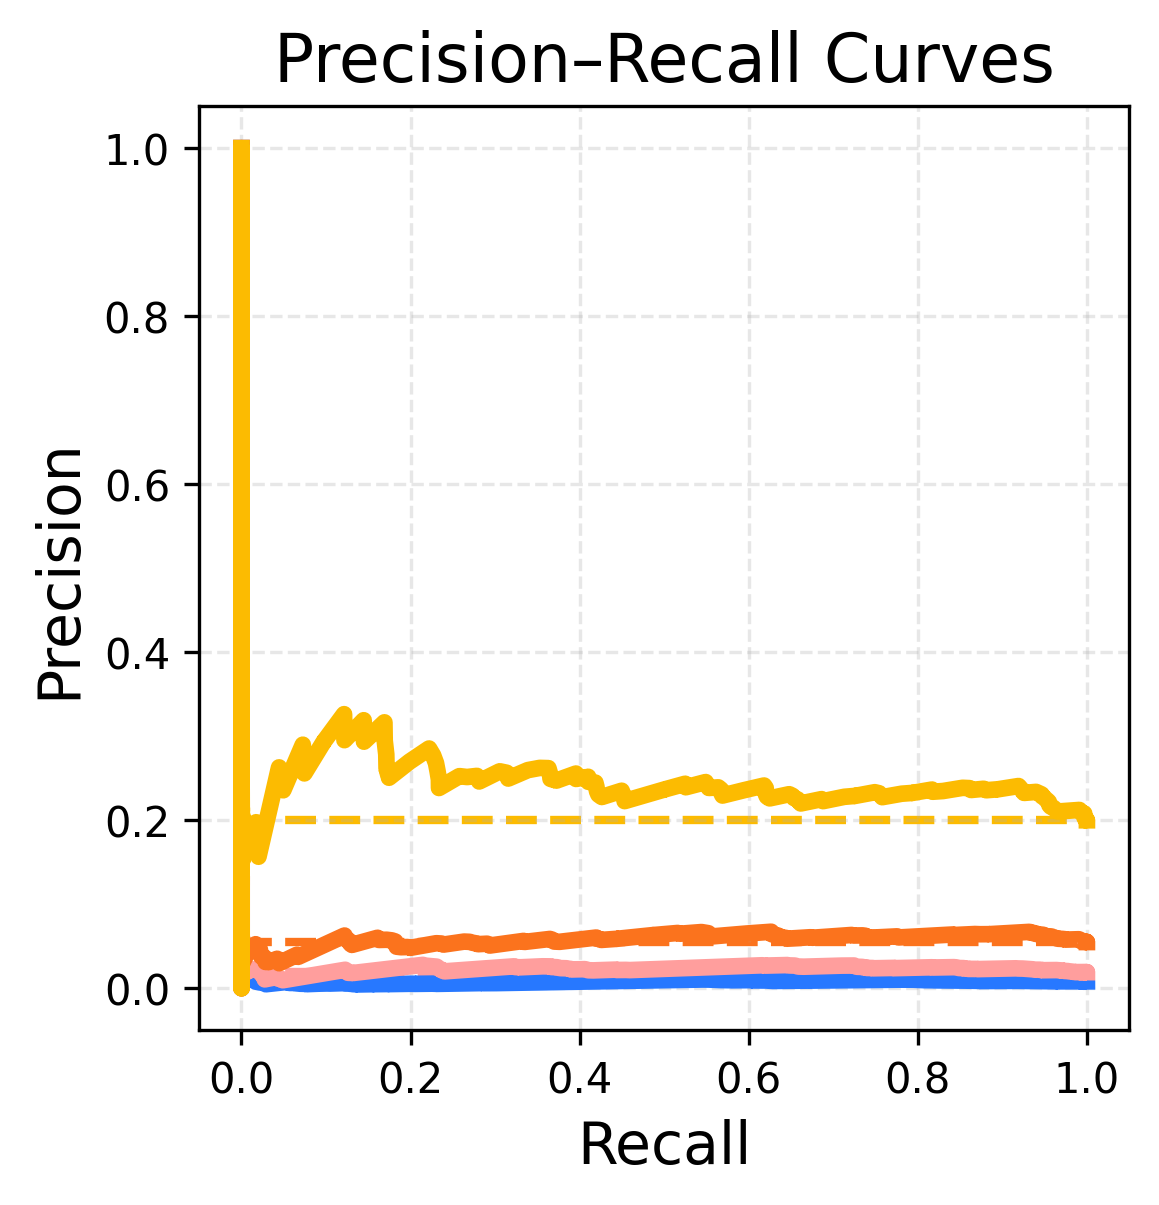

8 8 8


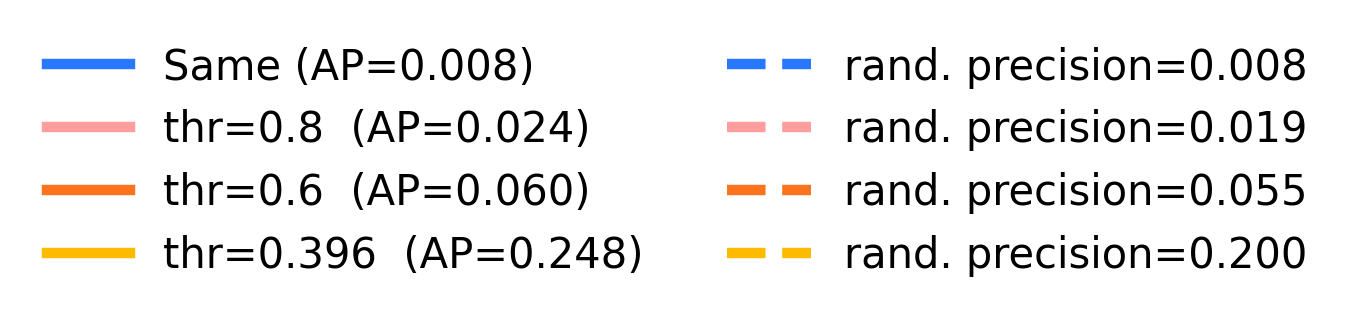

In [148]:


thresholds_to_plot = [1.0,0.8,0.6,0.396]

labels = plot_multi_pr_curves(
    y_prob=y_test_pred,
    y_test_doids=df_test["doid_id"].to_list(),
    df_query=df_test,
    all_doids=all_doids,
    rel_map=rel_map,
    thresholds_to_plot=thresholds_to_plot,
    colors=["#2778ff","#ff9e9d", "#fb731d", "#fcbb01","grey"]
)

plot_legend_only(
    labels=labels,
    colors=["#2778ff","#ff9e9d", "#fb731d", "#fcbb01"],
    ncols=2,
    figsize=(1,1)
)


## 2.3.2: Build Fine-Tuned Disease Identity Model (Classification)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# Model Expand to Small
class DiseaseClassifier(nn.Module):
    def __init__(self, d_in: int, d_out: int, hidden: int = 256, dropout: float = 0.1):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(d_in, 512),
            # nn.ReLU(),
            # nn.Dropout(dropout),
            # nn.Linear(512, 512),
            nn.ReLU(),
        )

        # NEW classification head
        self.classifier = nn.Sequential(
            nn.Linear(512, d_out)   # one logit per disease
        )

    def forward(self, x):
        h = self.backbone(x)
        logits = self.classifier(h)
        return logits

# regression model already exists = model
model_ft = DiseaseClassifier(e_train.shape[1], y_train.shape[1],).to(device)

# extract backbone weights = layers 0-5
reg_sd = model.net.state_dict()

# filter out only backbone layers (0–5)
backbone_sd = {k: v for k, v in reg_sd.items() if not k.startswith("2.")}

# load
model_ft.backbone.load_state_dict(backbone_sd, strict=True)

print("Backbone successfully transferred!")

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model_ft.parameters(), lr=1e-3, weight_decay=1e-4)

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode='min',
#     patience=3,
#     factor=0.5,
#     min_lr=1e-6
# )

# ================================
# 1. Build class index mapping
# ================================
disease_to_cls = {d: i for i, d in enumerate(all_doids)}
cls_to_disease = {i: d for d, i in disease_to_cls.items()}

print("Number of classes:", len(disease_to_cls))

# ================================
# 2. Build classification labels
# ================================
y_train_cls = np.array([disease_to_cls[d] for d in df_train["doid_id"].values])
y_valid_cls = np.array([disease_to_cls[d] for d in df_valid["doid_id"].values])
y_test_cls  = np.array([disease_to_cls[d] for d in df_test["doid_id"].values])

# ================================
# 3. Convert to tensors
# ================================
y_train_cls_t = torch.from_numpy(y_train_cls).long().to(device)
y_valid_cls_t = torch.from_numpy(y_valid_cls).long().to(device)
y_test_cls_t  = torch.from_numpy(y_test_cls).long().to(device)



from torch.utils.data import DataLoader, TensorDataset

# Build dataset
X_train_t = torch.from_numpy(e_train).float().to(device)
y_train_cls_t = torch.from_numpy(y_train_cls).long().to(device)  # class index per sample

train_ds = TensorDataset(X_train_t, y_train_cls_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

X_valid_t = torch.from_numpy(e_valid).float().to(device)
y_valid_cls_t = torch.from_numpy(y_valid_cls).long().to(device)

X_test_t = torch.from_numpy(e_test).float().to(device)
y_test_cls_t = torch.from_numpy(y_test_cls).long().to(device)

epochs = 40
best_val_loss = float("inf")
patience = 50
patience_counter = 0

for epoch in range(1, epochs + 1):
    model_ft.train()
    total_loss = 0
    n = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        logits = model_ft(xb)
        loss = criterion(logits, yb)   # OR focal_loss(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        n += xb.size(0)

    train_loss = total_loss / n

    # --- validation ---
    model_ft.eval()
    with torch.no_grad():
        val_logits = model_ft(X_valid_t)
        val_loss = criterion(val_logits, y_valid_cls_t).item()

    # scheduler.step(val_loss)

    print(f"Epoch {epoch:03d} | TrainLoss={train_loss:.4f} | ValLoss={val_loss:.4f} | LR={optimizer.param_groups[0]['lr']:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = model_ft.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping.")
            break

# Load best model_ft
model_ft.load_state_dict(best_state)


pred = torch.argmax(model_ft(X_test_t), dim=1).cpu().numpy()
acc = (pred == y_test_cls).mean()
print("Top-1 Accuracy:", acc)


def topk_accuracy(logits, labels, k):
    topk = torch.topk(logits, k, dim=1).indices
    correct = (topk == labels.unsqueeze(1)).any(dim=1)
    return correct.float().mean().item()

logits_test = model_ft(X_test_all).cpu()

print("Top-1:", topk_accuracy(logits_test, y_test_cls_t.cpu(), 1))
print("Top-5:", topk_accuracy(logits_test, y_test_cls_t.cpu(), 5))
print("Top-10:", topk_accuracy(logits_test, y_test_cls_t.cpu(), 10))


In [ ]:
{k: v for k, v in reg_sd.items() if not k.startswith("2.")}

In [ ]:
def topk_accuracy(logits, labels, k):
    topk = torch.topk(logits, k, dim=1).indices
    correct = (topk == labels.unsqueeze(1)).any(dim=1)
    print("Correct predictions:", correct.sum().item(), "out of", labels.size(0))
    return correct.float().mean().item()

logits_test = model_ft(X_test_all).cpu()
print("Top-1:", topk_accuracy(logits_test, y_test_cls_t.cpu(), 1))

# 4. Nearest Neighbor Approach

In [195]:
# imports
from sklearn.metrics import pairwise_distances
from scipy.stats import hypergeom
from tqdm import tqdm
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import classification_report
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

# variables
remove_related = False
remove_control = True
set_related_pos = False
custom_splits = False


# functions
def get_top_k_dis(df_qry:pd.DataFrame, 
                  df_ref:pd.DataFrame, 
                  c_matrix_qry_ref:np.ndarray,
                  c_matrix_ref:np.ndarray,
                  do_diff_dt:bool=True, 
                  )->pd.DataFrame:
    """
    Get top K closest diseases for each query GEx
    """

    def _get_top_k(labels: np.ndarray, x: np.ndarray, k: int = 5) -> List[str]:
        """Return the top-k labels by descending score."""
        top_k_idx = np.argsort(x)[::-1][:k]
        return labels[top_k_idx].tolist()

    def _get_top_k_uniq(labels: np.ndarray, x: np.ndarray, k: int = 5, dist_thr:float=None) -> List[str]:
        """Return top-k unique labels by descending score."""
        top_k = []
        for i in np.argsort(x)[::-1]:
            label = labels[i]

            if dist_thr is not None:                    
                if x[i] < dist_thr:
                    break

            if label not in top_k:
                top_k.append(label)

            if len(top_k) == k:
                break
        return top_k
    
    def _get_dist_nn(labels: np.ndarray, x: np.ndarray, dist: float = 0.5) -> List[str]:
        """Return all labels within a certain distance."""
        return labels[np.where(x >= dist)].tolist()

    df_qry.reset_index(drop=True, inplace=True)
    df_ref.reset_index(drop=True, inplace=True)

    ref_doids = df_ref["doid_id"].values
    ref_datasets = df_ref["dataset"].values
    qry_doids = df_qry["doid_id"].values
    qry_datasets = df_qry["dataset"].values

    # get first instance of each unique element
    dt_first_idxs = list()
    datasets = df_ref["dataset"].to_list()
    for d in set(datasets):
        # only returns first instance!
        idx = datasets.index(d)
        dt_first_idxs.append(idx)

    # subset all distances to first instance of each dataset
    dt_matrix = c_matrix_ref[dt_first_idxs, :][:, dt_first_idxs]

    # get values below diagonal
    lower_tri_indices = np.tril_indices_from(dt_matrix, k=-1)
    dt_values = dt_matrix[lower_tri_indices]

    thr_90_pct = np.percentile(dt_values, 90)
    thr_95_pct = np.percentile(dt_values, 95)
    thr_99_pct = np.percentile(dt_values, 99)

    print(f"Distance thresholds (90, 95, 99 pct): {thr_90_pct:.3f}, {thr_95_pct:.3f}, {thr_99_pct:.3f}")

    results = list()
    for i in tqdm(range(len(df_qry)), desc="Processing queries"):
        q_doid = qry_doids[i]
        q_dataset = qry_datasets[i]
        sims = np.array(c_matrix_qry_ref[i, :], copy=True)

        # If requested, mask similarities to samples from the same dataset
        if do_diff_dt:
            same_dt_mask = ref_datasets == q_dataset
            sims[same_dt_mask] = -1  # ignore self-dataset similarities

        results.append({
            "query_doid": q_doid,
            "top_1": _get_top_k(ref_doids, sims, k=1),
            "top_5": _get_top_k(ref_doids, sims, k=5),
            "top_10": _get_top_k(ref_doids, sims, k=10),
            "top_25": _get_top_k(ref_doids, sims, k=25),
            "top_50": _get_top_k(ref_doids, sims, k=50),
            "top_100": _get_top_k(ref_doids, sims, k=100),
            "top_1_unique": _get_top_k_uniq(ref_doids, sims, k=1),
            "top_3_unique": _get_top_k_uniq(ref_doids, sims, k=3),
            "top_5_unique": _get_top_k_uniq(ref_doids, sims, k=5),
            "top_5_unique_90": _get_top_k_uniq(ref_doids, sims, k=5, dist_thr=thr_90_pct),
            "top_5_unique_95": _get_top_k_uniq(ref_doids, sims, k=5, dist_thr=thr_95_pct),
            "top_5_unique_99": _get_top_k_uniq(ref_doids, sims, k=5, dist_thr=thr_99_pct),
            "top_10_unique": _get_top_k_uniq(ref_doids, sims, k=10),
            "top_25_unique": _get_top_k_uniq(ref_doids, sims, k=25),
            "nn_90_pct": _get_dist_nn(ref_doids, sims, dist=thr_90_pct),
            "nn_95_pct": _get_dist_nn(ref_doids, sims, dist=thr_95_pct),
            "nn_99_pct": _get_dist_nn(ref_doids, sims, dist=thr_99_pct),
        })

    return pd.DataFrame(results)

def add_hypergeom_hits(df_top_nn: pd.DataFrame, population:List, col_query="query_doid", col_hits="nn_99_pct", alpha=0.05):

    N = len(population)

    # get all hits list which pass hypergeom test
    _all_hits =list()
    for hits_i in tqdm(df_top_nn[col_hits]):
        _passed_hits = list()
        for h in set(hits_i):
            n = len(hits_i) # sample size
        
            K = population.count(h) # nº of success in population
            k = hits_i.count(h) # nº of observed successes sample
            
            p = hypergeom.sf(k - 1, N, K, n)
            if p < alpha:
                _passed_hits.append(h)

        _all_hits.append(_passed_hits)

    # store hits        
    df_top_nn[f"{col_hits}_hg"] = _all_hits

    return df_top_nn

# prepare data
all_doids = sorted(adata_train.obs["doid_id"].unique())

df_train = adata_train.obs.copy()
df_valid = adata_valid.obs.copy()
df_test = adata_test.obs.copy()

e_train = embeddings_train
e_valid = embeddings_valid
e_test = embeddings_test

if remove_control:
    all_doids.remove("Control")

    mask_train = df_train["doid_id"] != "Control"
    mask_valid = df_valid["doid_id"] != "Control"
    mask_test = df_test["doid_id"] != "Control"

    df_train = df_train[mask_train].reset_index(drop=True)
    df_valid = df_valid[mask_valid].reset_index(drop=True)
    df_test = df_test[mask_test].reset_index(drop=True)

    e_train = e_train[mask_train.values]
    e_valid = e_valid[mask_valid.values]
    e_test = e_test[mask_test.values]


if custom_splits:
    df_train_all = pd.concat([df_train.reset_index(drop=True), df_valid.reset_index(drop=True)], axis=0)
    df_train_all = df_train_all.reset_index(drop=True)

    # RE-SPLIT TRAIN/VALIDATION SET
    train_idx, valid_idx = custom_train_valid_split(df_train_all, remove_control=remove_control)
    df_train = df_train_all.iloc[train_idx].reset_index(drop=True)
    df_valid = df_train_all.iloc[valid_idx].reset_index(drop=True)

    e_train_all = np.concatenate([e_train, e_valid], axis=0)
    e_train = e_train_all[train_idx]
    e_valid = e_train_all[valid_idx]

dis_order = df_train["doid_id"].unique()
print(f"Total dis_ordereases in training set: {len(dis_order)}")
print(f"Nº of train samples: {df_train.shape[0]}\tNº of diseases: {len(df_train['doid_id'].unique())}")
print(f"Nº of validation samples: {df_valid.shape[0]}\tNº of diseases: {len(df_valid['doid_id'].unique())}")
print(f"Nº of test samples: {df_test.shape[0]}\tNº of diseases: {len(df_test['doid_id'].unique())}")


# compute similarity distances
c_matrix_train = 1 - pairwise_distances(e_train, e_train, metric='cosine')
c_matrix_valid_vs_train = 1 - pairwise_distances(e_valid, e_train, metric='cosine')
c_matrix_test_vs_train = 1 - pairwise_distances(e_test, e_train, metric='cosine')

df_test_nn = get_top_k_dis(
    df_qry=df_test,
    df_ref=df_train,
    c_matrix_qry_ref=c_matrix_test_vs_train,
    c_matrix_ref=c_matrix_train,
    do_diff_dt=True,
)

df_valid_nn = get_top_k_dis(
    df_qry=df_valid,
    df_ref=df_train,
    c_matrix_qry_ref=c_matrix_valid_vs_train,
    c_matrix_ref=c_matrix_train,
    do_diff_dt=True,
)

# mask diagonal of train to value 0
c_matrix_train_masked = c_matrix_train.copy()
np.fill_diagonal(c_matrix_train_masked, 0)

df_train_nn = get_top_k_dis(
    df_qry=df_train,
    df_ref=df_train,
    c_matrix_qry_ref=c_matrix_train_masked,
    c_matrix_ref=c_matrix_train,
    do_diff_dt=True,
)

Total dis_ordereases in training set: 123
Nº of train samples: 11823	Nº of diseases: 123
Nº of validation samples: 1314	Nº of diseases: 106
Nº of test samples: 3611	Nº of diseases: 123
Distance thresholds (90, 95, 99 pct): 1.000, 1.000, 1.000


Processing queries: 100%|██████████| 3611/3611 [00:22<00:00, 163.02it/s]


Distance thresholds (90, 95, 99 pct): 1.000, 1.000, 1.000


Processing queries: 100%|██████████| 1314/1314 [00:07<00:00, 164.60it/s]


Distance thresholds (90, 95, 99 pct): 1.000, 1.000, 1.000


Processing queries: 100%|██████████| 11823/11823 [01:11<00:00, 164.34it/s]


In [ ]:
1 - pairwise_distances(e_ft_train, e_ft_train, metric='cosine')

In [ ]:
1 - pairwise_distances(e_pt_train, e_pt_train, metric='cosine')

In [ ]:
c_matrix_train = 1 - pairwise_distances(e_train, e_train, metric='euclidean')

In [196]:
df_test_nn = get_top_k_dis(
    df_qry=df_test,
    df_ref=df_train,
    c_matrix_qry_ref=c_matrix_test_vs_train,
    c_matrix_ref=c_matrix_train,
    do_diff_dt=True,
)

df_valid_nn = get_top_k_dis(
    df_qry=df_valid,
    df_ref=df_train,
    c_matrix_qry_ref=c_matrix_valid_vs_train,
    c_matrix_ref=c_matrix_train,
    do_diff_dt=True,
)

Distance thresholds (90, 95, 99 pct): 1.000, 1.000, 1.000


Processing queries: 100%|██████████| 3611/3611 [00:22<00:00, 163.78it/s]


Distance thresholds (90, 95, 99 pct): 1.000, 1.000, 1.000


Processing queries: 100%|██████████| 1314/1314 [00:07<00:00, 165.64it/s]


In [197]:
df_test_nn

,query_doid,top_1,top_5,top_10,top_25,top_50,top_100,top_1_unique,top_3_unique,top_5_unique,top_5_unique_90,top_5_unique_95,top_5_unique_99,top_10_unique,top_25_unique,nn_90_pct,nn_95_pct,nn_99_pct
0,DOID:768,[DOID:768],"[DOID:768, DOID:768, DOID:769, DOID:5419, DOID...","[DOID:768, DOID:768, DOID:769, DOID:5419, DOID...","[DOID:768, DOID:768, DOID:769, DOID:5419, DOID...","[DOID:768, DOID:768, DOID:769, DOID:5419, DOID...","[DOID:768, DOID:768, DOID:769, DOID:5419, DOID...",[DOID:768],"[DOID:768, DOID:769, DOID:5419]","[DOID:768, DOID:769, DOID:5419, DOID:12858, DO...","[DOID:768, DOID:769, DOID:5419, DOID:12858, DO...","[DOID:768, DOID:769, DOID:5419, DOID:12858, DO...","[DOID:768, DOID:769]","[DOID:768, DOID:769, DOID:5419, DOID:12858, DO...","[DOID:768, DOID:769, DOID:5419, DOID:12858, DO...","[DOID:10286, DOID:1928, DOID:12858, DOID:3068,...","[DOID:10286, DOID:3459, DOID:10286, DOID:10286...","[DOID:769, DOID:768, DOID:768]"
1,DOID:768,[DOID:12858],"[DOID:12858, DOID:768, DOID:768, DOID:12858, D...","[DOID:12858, DOID:768, DOID:768, DOID:12858, D...","[DOID:12858, DOID:768, DOID:768, DOID:12858, D...","[DOID:12858, DOID:768, DOID:768, DOID:12858, D...","[DOID:12858, DOID:768, DOID:768, DOID:12858, D...",[DOID:12858],"[DOID:12858, DOID:768, DOID:5419]","[DOID:12858, DOID:768, DOID:5419, DOID:769, DO...","[DOID:12858, DOID:768, DOID:5419, DOID:769, DO...","[DOID:12858, DOID:768, DOID:5419, DOID:769, DO...","[DOID:12858, DOID:768, DOID:5419]","[DOID:12858, DOID:768, DOID:5419, DOID:769, DO...","[DOID:12858, DOID:768, DOID:5419, DOID:769, DO...","[DOID:10286, DOID:3068, DOID:1928, DOID:2394, ...","[DOID:3068, DOID:3459, DOID:10286, DOID:10286,...","[DOID:12858, DOID:5419, DOID:12858, DOID:5419,..."
2,DOID:768,[DOID:12858],"[DOID:12858, DOID:768, DOID:768, DOID:12858, D...","[DOID:12858, DOID:768, DOID:768, DOID:12858, D...","[DOID:12858, DOID:768, DOID:768, DOID:12858, D...","[DOID:12858, DOID:768, DOID:768, DOID:12858, D...","[DOID:12858, DOID:768, DOID:768, DOID:12858, D...",[DOID:12858],"[DOID:12858, DOID:768, DOID:5419]","[DOID:12858, DOID:768, DOID:5419, DOID:1928, D...","[DOID:12858, DOID:768, DOID:5419, DOID:1928, D...","[DOID:12858, DOID:768, DOID:5419, DOID:1928, D...","[DOID:12858, DOID:768]","[DOID:12858, DOID:768, DOID:5419, DOID:1928, D...","[DOID:12858, DOID:768, DOID:5419, DOID:1928, D...","[DOID:10286, DOID:3068, DOID:1928, DOID:2394, ...","[DOID:3068, DOID:3459, DOID:10286, DOID:10286,...","[DOID:12858, DOID:12858, DOID:768, DOID:768]"
3,DOID:768,[DOID:768],"[DOID:768, DOID:5419, DOID:5419, DOID:769, DOI...","[DOID:768, DOID:5419, DOID:5419, DOID:769, DOI...","[DOID:768, DOID:5419, DOID:5419, DOID:769, DOI...","[DOID:768, DOID:5419, DOID:5419, DOID:769, DOI...","[DOID:768, DOID:5419, DOID:5419, DOID:769, DOI...",[DOID:768],"[DOID:768, DOID:5419, DOID:769]","[DOID:768, DOID:5419, DOID:769, DOID:14330, DO...","[DOID:768, DOID:5419, DOID:769, DOID:14330, DO...","[DOID:768, DOID:5419, DOID:769, DOID:14330, DO...","[DOID:768, DOID:5419, DOID:769, DOID:14330]","[DOID:768, DOID:5419, DOID:769, DOID:14330, DO...","[DOID:768, DOID:5419, DOID:769, DOID:14330, DO...","[DOID:3068, DOID:1928, DOID:2394, DOID:2526, D...","[DOID:3068, DOID:1928, DOID:12858, DOID:5419, ...","[DOID:14330, DOID:5419, DOID:769, DOID:5419, D..."
4,DOID:768,[DOID:768],"[DOID:768, DOID:5419, DOID:5419, DOID:768, DOI...","[DOID:768, DOID:5419, DOID:5419, DOID:768, DOI...","[DOID:768, DOID:5419, DOID:5419, DOID:768, DOI...","[DOID:768, DOID:5419, DOID:5419, DOID:768, DOI...","[DOID:768, DOID:5419, DOID:5419, DOID:768, DOI...",[DOID:768],"[DOID:768, DOID:5419, DOID:769]","[DOID:768, DOID:5419, DOID:769, DOID:12858, DO...","[DOID:768, DOID:5419, DOID:769, DOID:12858, DO...","[DOID:768, DOID:5419, DOID:769, DOID:12858, DO...","[DOID:768, DOID:5419]","[DOID:768, DOID:5419, DOID:769, DOID:12858, DO...","[DOID:768, DOID:5419, DOID:769, DOID:12858, DO...","[DOID:3068, DOID:1928, DOID:2394, DOID:11722, ...","[DOID:12858, DOID:3068, DOID:10286, DOID:10286..

In [ ]:
# add hypergeometric test to distance approach
df_test_nn = add_hypergeom_hits(df_test_nn, population=adata_train.obs["doid_id"].tolist(), col_hits="nn_90_pct", alpha=0.1)
df_test_nn = add_hypergeom_hits(df_test_nn, population=adata_train.obs["doid_id"].tolist(), col_hits="nn_95_pct", alpha=0.1)
df_test_nn = add_hypergeom_hits(df_test_nn, population=adata_train.obs["doid_id"].tolist(), col_hits="nn_99_pct", alpha=0.1)

df_valid_nn = add_hypergeom_hits(df_valid_nn, population=adata_train.obs["doid_id"].tolist(), col_hits="nn_90_pct", alpha=0.1)
df_valid_nn = add_hypergeom_hits(df_valid_nn, population=adata_train.obs["doid_id"].tolist(), col_hits="nn_95_pct", alpha=0.1)
df_valid_nn = add_hypergeom_hits(df_valid_nn, population=adata_train.obs["doid_id"].tolist(), col_hits="nn_99_pct", alpha=0.1)

df_train_nn = add_hypergeom_hits(df_train_nn, population=adata_train.obs["doid_id"].tolist(), col_hits="nn_90_pct", alpha=0.1)
df_train_nn = add_hypergeom_hits(df_train_nn, population=adata_train.obs["doid_id"].tolist(), col_hits="nn_95_pct", alpha=0.1)
df_train_nn = add_hypergeom_hits(df_train_nn, population=adata_train.obs["doid_id"].tolist(), col_hits="nn_99_pct", alpha=0.1)


In [198]:
df_perf_test = get_df_performance(
    dfs_conds=[
        (df_test_nn, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_test


,Key,Across,Condition,Hits Same Disease,Related Threshold,Precision@K,Recall@K,Size,Unique Size,Hits Related Disease,Random Baseline
0,top_1,Diseases,Remove Control True,6.2,0.396,38.7,3.0,1,1,32.6,0.8
1,top_1,Samples,Remove Control True,3.4,0.396,62.3,2.6,1,1,59.0,0.8
2,top_1,Diseases,Remove Control True,6.2,0.600,21.3,4.8,1,1,15.1,0.8
3,top_1,Samples,Remove Control True,3.4,0.600,31.5,4.2,1,1,28.2,0.8
4,top_1,Diseases,Remove Control True,6.2,0.800,16.9,5.9,1,1,10.7,0.8
...,...,...,...,...,...,...,...,...,...,...,...
131,nn_99_pct,Samples,Remove Control True,21.0,0.600,14.3,20.6,203±221,11±7,67.5,165.2
132,nn_99_pct,Diseases,Remove Control True,23.8,0.800,8.2,23.4,203±221,11±7,31.8,79.9
133,nn_99_pct,Samples,Remove Control True,21.0,0.800,8.2,24.2,203±221,11±7,45.6,165.2
134,nn_99_pct,Diseases,Remove Control True,23.8,0.900,3.8,23.2,203±221,11±7,4.0,79.9


In [ ]:
df_perf_valid = get_df_performance(
    dfs_conds=[
        (df_valid_nn, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_valid

In [ ]:
df_perf_train = get_df_performance(
    dfs_conds=[
        (df_train_nn, f"Remove Control {remove_control}"),
    ],
    rel_map=rel_map,
    n_labels=len(all_doids)
)
df_perf_train

# Junkyard

In [ ]:
# ================================================================
# NEW IMPROVED MODEL (NO SIGMOID!)
# ================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================================================================
# Model
# ================================================================
class MultiDiseaseRegressor(nn.Module):
    def __init__(self, d_in: int, d_out: int, hidden=256, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_out),   # raw scores!
        )

    def forward(self, x):
        return self.net(x)


# ================================================================
# Loss: Margin Ranking (Ranking Loss)
# ================================================================
def margin_ranking_loss(y_pred, y_true, margin=0.2):
    """
    y_true: one-hot-like similarity vector (peak at true disease)
    """
    batch, D = y_pred.shape
    device = y_pred.device

    pos_idx = torch.argmax(y_true, dim=1)
    pos_score = y_pred[torch.arange(batch, device=device), pos_idx]

    diff = y_pred - pos_score.unsqueeze(1) + margin
    diff[torch.arange(batch), pos_idx] = 0.0

    return torch.clamp(diff, min=0).mean()


# ================================================================
# Build weights
# ================================================================
def weighted_mse_loss(y_pred, y_true, w):
    return (w * (y_pred - y_true) ** 2).mean()


# ================================================================
# Prepare data
# ================================================================
w_train = build_weights(y_train)
w_valid = build_weights(y_valid)

X_train_t = torch.from_numpy(e_train).float()
Y_train_t = torch.from_numpy(y_train).float()
W_train_t = torch.from_numpy(w_train).float()

train_ds = TensorDataset(X_train_t, Y_train_t, W_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

X_valid_t = torch.from_numpy(e_valid).float().to(device)
Y_valid_t = torch.from_numpy(y_valid).float().to(device)
W_valid_t = torch.from_numpy(w_valid).float().to(device)

# ================================================================
# Init model
# ================================================================
model = MultiDiseaseRegressor(e_train.shape[1], y_train.shape[1], hidden=256).to(device)
print(f"Model: input = {e_train.shape[1]}, output = {y_train.shape[1]}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

criterion_ce = nn.CrossEntropyLoss()

alpha_mse  = 1.0
alpha_ce   = 0.2
alpha_rank = 0.4

# ================================================================
# Training Loop
# ================================================================
best_val_loss = float("inf")
patience = 10
patience_counter = 0

for epoch in range(1, 201):

    model.train()
    running_loss = 0.0
    n_samples_seen = 0

    for xb, yb, wb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        wb = wb.to(device)

        optimizer.zero_grad()

        y_pred = model(xb)

        mse_loss  = weighted_mse_loss(y_pred, yb, wb)
        target_idx = torch.argmax(yb, dim=1)
        ce_loss   = criterion_ce(y_pred, target_idx)
        rank_loss = margin_ranking_loss(y_pred, yb)

        loss = (
            alpha_mse  * mse_loss +
            alpha_ce   * ce_loss +
            alpha_rank * rank_loss
        )

        loss.backward()
        optimizer.step()

        # FIXED: accumulate loss properly
        running_loss += loss.item() * xb.size(0)
        n_samples_seen += xb.size(0)

    train_loss = running_loss / n_samples_seen

    # -------------------------
    # Validation
    # -------------------------
    model.eval()
    with torch.no_grad():
        y_valid_pred = model(X_valid_t)
        val_mse = weighted_mse_loss(y_valid_pred, Y_valid_t, W_valid_t).item()
        val_ce  = criterion_ce(y_valid_pred, torch.argmax(Y_valid_t, dim=1)).item()

        val_loss = alpha_mse * val_mse + alpha_ce * val_ce

    scheduler.step(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | TrainLoss={train_loss:.6f} | "
              f"ValLoss={val_loss:.6f} | Val MSE={val_mse:.6f} | Val CE={val_ce:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stop at epoch {epoch}")
            break

# ================================================================
# Restore best
# ================================================================
model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    X_test_t = torch.from_numpy(e_test).float().to(device)
    y_test_pred = model(X_test_t).cpu().numpy()

print("Test MSE:", mean_squared_error(y_test, y_test_pred))

# ================================================================
# Top-1 Hit Rate
# ================================================================
y_test_true = np.argmax(y_test, axis=1)
y_test_pred_cls = np.argmax(y_test_pred, axis=1)
top1 = (y_test_true == y_test_pred_cls).mean()
print("Top-1 Hit Rate:", top1)


In [ ]:
# ============================
# PyTorch multi-output regressor with weighted + BCE loss
# ============================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# ---- device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- build per-sample-per-disease weights ----
def build_weights(y: np.ndarray) -> np.ndarray:
    """
    Give higher weights to same-disease and high-similarity pairs.
    """
    w = np.ones_like(y, dtype=np.float32)

    w[y >= 1.0] = 5        # exact same disease
    w[(y >= 0.8) & (y < 1.0)] = 3  # high similarity
    w[(y >= 0.4) & (y < 0.8)] = 1.5  # mid similarity

    return w

w_train = build_weights(y_train)
w_valid = build_weights(y_valid)

# ---- dataset & dataloader ----
X_train_t = torch.from_numpy(e_train).float()
Y_train_t = torch.from_numpy(y_train).float()
W_train_t = torch.from_numpy(w_train).float()

train_ds = TensorDataset(X_train_t, Y_train_t, W_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=False)

# ---- validation tensors ----
X_valid_t = torch.from_numpy(e_valid).float().to(device)
Y_valid_t = torch.from_numpy(y_valid).float().to(device)
W_valid_t = torch.from_numpy(w_valid).float().to(device)

# ============================
# Model with two heads:
# - Regression head: predicts continuous similarity vector
# - Classification head: predicts logits for same-disease label
# ============================
class MultiDiseaseRegressor(nn.Module):
    def __init__(self, d_in, d_out, hidden=256, dropout=0.05):
        super().__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        
        # Regression head: continuous outputs
        self.reg_head = nn.Linear(hidden, d_out)
        
        # Classification head: logits for BCE
        self.cls_head = nn.Linear(hidden, d_out)

    def forward(self, x):
        h = self.shared(x)
        y_reg = self.reg_head(h)
        y_logit = self.cls_head(h)
        return y_reg, y_logit

d_in = e_train.shape[1]
d_out = y_train.shape[1]

model = MultiDiseaseRegressor(d_in, d_out, hidden=256, dropout=0.1).to(device)
print(f"Model: input dim = {d_in}, output dim = {d_out}")


# ---- optimizer ----
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
n_epochs = 200

# ---- training loop ----
best_val_loss = float("inf")
patience = 20
patience_counter = 0

for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0
    n_samples_seen = 0

    for xb, yb, wb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        wb = wb.to(device)

        optimizer.zero_grad()
        
        y_reg_pred, y_logit = model(xb)

        # Weighted MSE
        mse = (wb * (y_reg_pred - yb)**2).mean()

        # Classification target: only exact disease has label 1
        cls_target = (yb >= 0.9).float()

        # BCE on logits
        bce = F.binary_cross_entropy_with_logits(y_logit, cls_target)

        loss = 2*mse + 4*bce

        loss.backward()
        optimizer.step()

        batch_size = xb.size(0)
        running_loss += loss.item() * batch_size
        n_samples_seen += batch_size

    train_epoch_loss = running_loss / n_samples_seen

    # ---- validation ----
    model.eval()
    with torch.no_grad():
        y_reg_val, y_logit_val = model(X_valid_t)
        
        # BCE on logits 
        cls_target = (Y_valid_t >= 0.9).float()
        bce = F.binary_cross_entropy_with_logits(y_logit_val, cls_target)
        mse = (W_valid_t * (y_reg_val - Y_valid_t)**2).mean()
        val_loss =  bce.item()
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train Loss: {train_epoch_loss:.6f} | BCE Loss: {bce:.6f} | MSE Loss: {mse:.6f}")

    # ---- early stopping ----
    if val_loss < best_val_loss:
        print(f"Epoch {epoch:03d} | Train Loss: {train_epoch_loss:.6f} | BCE Loss: {bce:.6f} | MSE Loss: {mse:.6f}")
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# ============================
# Inference
# ============================
model.load_state_dict(best_model_state)
model.eval()

with torch.no_grad():
    X_train_all = torch.from_numpy(e_train).float().to(device)
    X_valid_all = torch.from_numpy(e_valid).float().to(device)
    X_test_all  = torch.from_numpy(e_test).float().to(device)

    y_train_reg, y_train_logit = model(X_train_all)
    y_valid_reg, y_valid_logit = model(X_valid_all)
    y_test_reg,  y_test_logit  = model(X_test_all)

    y_train_pred = y_train_reg.cpu().numpy()
    y_valid_pred = y_valid_reg.cpu().numpy()
    y_test_pred  = y_test_reg.cpu().numpy()

# Example: compute unweighted MSE
from sklearn.metrics import mean_squared_error

print("Test MSE:", mean_squared_error(y_test, y_test_pred))
print("Precision", precision_score(np.argmax(y_test, axis=1), np.argmax(y_test_pred, axis=1), average='macro'))

# print accuracy
y_test_true_cls = np.argmax(y_test, axis=1)
y_test_pred_cls = np.argmax(y_test_pred, axis=1)
top1_acc = (y_test_true_cls == y_test_pred_cls).mean()
print("Top-1 Hit Rate:", top1_acc)

# top k accuracies
def topk_accuracy(y_true, y_pred, k):
    topk = np.argsort(y_pred, axis=1)[:, -k:]
    correct = [1 if y_true[i] in topk[i] else 0 for i in range(y_true.shape[0])]
    return np.mean(correct) 

print("Top-1:", topk_accuracy(y_test_true_cls, y_test_pred, 1))
print("Top-5:", topk_accuracy(y_test_true_cls, y_test_pred, 5))
print("Top-10:", topk_accuracy(y_test_true_cls, y_test_pred, 10))

In [ ]:
y_test_true_cls

In [ ]:
def get_df_pred(y_prob, y_doids, all_doids):
    results = []
    all_doids = np.array(all_doids)
    for i in range(y_prob.shape[0]):
        y_prob_i = y_prob[i]
        y_doids_i = y_doids[i]  
        
        results.append({
            "query_doid":y_doids_i,
            "top_1":all_doids[np.argsort(y_prob_i)[-1:][::-1]].tolist(),
            "top_5":all_doids[np.argsort(y_prob_i)[-5:][::-1]].tolist(),
            "top_10":all_doids[np.argsort(y_prob_i)[-10:][::-1]].tolist(),
            "+0.4":all_doids[y_prob_i >= 0.39].tolist(),
            "+0.5":all_doids[y_prob_i >= 0.5].tolist(),
            "+0.6":all_doids[y_prob_i >= 0.6].tolist(),
            "+0.7":all_doids[y_prob_i >= 0.7].tolist(),
            "+0.8":all_doids[y_prob_i >= 0.8].tolist(),
            "+0.9":all_doids[y_prob_i >= 0.9].tolist(),
        })


    return pd.DataFrame(results)

df_pred_test = get_df_pred(y_test_pred, df_test["doid_id"].to_list(), all_doids)

# aggregated by samples
format_pct = lambda x: [f"{x_i*100:.2f}" for x_i in x]
thr_sim = [0.396, 0.6, 0.8, 0.9]
perf_results = list()
for k in df_pred_test.columns[1:]:
    for thr in thr_sim:
        for _df, _condition in zip([df_pred_test], ["No Control"]):
            # group by disease
            _df_counts = get_counts(_df, rel_map[thr], k)
            _df_counts = _df_counts.copy()
            _df_counts["prec@k"] = _df_counts["prec@k"].replace(np.nan, 0)
            _df_counts["recall@k"] = _df_counts["recall@k"].replace(np.nan, 0)
            _df_counts["random_baseline"] = _df_counts["n_total"]*1/len(all_doids)*100


            perf_results.append({
                "Key": k,
                "Across": "Diseases",
                "Condition": _condition,
                "Hits Same Disease": f"{_df_counts.groupby('query_doid')['hits_same'].mean().mean()*100:.1f}",
                "Threshold Similarity": thr,
                "Precision@K": f"{_df_counts.groupby('query_doid')['prec@k'].mean().mean()*100:.1f}",
                "Recall@K": f"{_df_counts.groupby('query_doid')['recall@k'].mean().mean()*100:.1f}",
                "Size": f'{_df_counts["n_total"].mean():.0f}±{_df_counts["n_total"].std():.0f}' if _df_counts["n_total"].std() > 0 else f'{_df_counts["n_total"].mean():.0f}',
                "Size_Min": f'{_df_counts["n_total"].min():.0f}',
                "Size_Max": f'{_df_counts["n_total"].max():.0f}',
                "Size_Median": f'{_df_counts["n_total"].median():.0f}',
                "Unique Size": f'{_df_counts["n_total_unique"].mean():.0f}±{_df_counts["n_total_unique"].std():.0f}' if _df_counts["n_total_unique"].std() > 0 else f'{_df_counts["n_total_unique"].mean():.0f}',
                "Hits Related Disease": f"{_df_counts.groupby("query_doid")["hits_rel"].mean().mean()*100:.1f}",
                "Random Baseline": f"{_df_counts.groupby('query_doid')['random_baseline'].mean().mean():.1f}",
            })

            # across all samples
            perf_results.append({
                "Key": k,
                "Across": "Samples",
                "Condition": _condition,
                "Hits Same Disease": f"{_df_counts["hits_same"].mean()*100:.1f}",
                "Threshold Similarity": thr,
                "Precision@K": f"{_df_counts['prec@k'].mean()*100:.1f}",
                "Recall@K": f"{_df_counts['recall@k'].mean()*100:.1f}",
                "Size": f'{_df_counts["n_total"].mean():.0f}±{_df_counts["n_total"].std():.0f}' if _df_counts["n_total"].std() > 0 else f'{_df_counts["n_total"].mean():.0f}',
                "Size_Min": f'{_df_counts["n_total"].min():.0f}',
                "Size_Max": f'{_df_counts["n_total"].max():.0f}',
                "Size_Median": f'{_df_counts["n_total"].median():.0f}',
                "Unique Size": f'{_df_counts["n_total_unique"].mean():.0f}±{_df_counts["n_total_unique"].std():.0f}' if _df_counts["n_total_unique"].std() > 0 else f'{_df_counts["n_total_unique"].mean():.0f}',
                "Hits Related Disease": f"{_df_counts["hits_rel"].mean()*100:.1f}",
                "Random Baseline": f"{_df_counts["random_baseline"].mean():.1f}",
            })
        
df_perf_results = pd.DataFrame(perf_results)

In [ ]:
df_perf_results

In [ ]:
# ============================
# PyTorch multi-output regressor with weighted regression + pairwise ranking loss
# ============================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# ---- device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- build per-sample-per-disease weights ----
def build_weights(y: np.ndarray) -> np.ndarray:
    """
    Give higher weights to same-disease and high-similarity pairs.
    """
    w = np.ones_like(y, dtype=np.float32)

    w[y >= 1.0] = 5            # exact same disease
    w[(y >= 0.8) & (y < 1.0)] = 3
    w[(y >= 0.4) & (y < 0.8)] = 3

    return w

w_train = build_weights(y_train)
w_valid = build_weights(y_valid)

# ---- dataset & dataloader ----
X_train_t = torch.from_numpy(e_train).float()
Y_train_t = torch.from_numpy(y_train).float()
W_train_t = torch.from_numpy(w_train).float()

train_ds = TensorDataset(X_train_t, Y_train_t, W_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=False)

# ---- validation tensors ----
X_valid_t = torch.from_numpy(e_valid).float().to(device)
Y_valid_t = torch.from_numpy(y_valid).float().to(device)
W_valid_t = torch.from_numpy(w_valid).float().to(device)

# ============================
# Model (shared MLP + single regression head)
# ============================
class MultiDiseaseRegressor(nn.Module):
    def __init__(self, d_in, d_out, hidden=256, dropout=0.1):
        super().__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        
        # Regression head only (ranking loss uses same scores)
        self.reg_head = nn.Linear(hidden, d_out)

    def forward(self, x):
        h = self.shared(x)
        y_reg = self.reg_head(h)
        return y_reg

d_in = e_train.shape[1]
d_out = y_train.shape[1]

model = MultiDiseaseRegressor(d_in, d_out, hidden=256, dropout=0.1).to(device)
print(f"Model: input dim = {d_in}, output dim = {d_out}")

# ============================
# Pairwise ranking loss (hinge)
# ============================
def pairwise_ranking_loss(y_pred, true_idx, margin=0.1):
    """
    y_pred: (batch, num_diseases)
    true_idx: (batch,) long tensor with correct disease index
    """
    batch, n_diseases = y_pred.shape

    # Score for correct disease
    pos_score = y_pred[torch.arange(batch), true_idx]  # (batch,)

    # Expand to compare with all disease scores
    pos_expanded = pos_score.unsqueeze(1).expand(-1, n_diseases)

    # compute margin violations
    margin_matrix = y_pred - pos_expanded + margin

    # do not penalize comparing the disease against itself
    margin_matrix[torch.arange(batch), true_idx] = 0.0

    # hinge
    loss = torch.clamp(margin_matrix, min=0).mean()

    return loss

# ---- optimizer ----
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
n_epochs = 200

# ---- training loop ----
best_val_loss = float("inf")
patience = 20
patience_counter = 0

for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0
    n_samples_seen = 0

    for xb, yb, wb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        wb = wb.to(device)

        optimizer.zero_grad()
        
        y_pred = model(xb)

        # Weighted regression MSE
        mse = (wb * (y_pred - yb)**2).mean()

        # True disease index
        true_idx = torch.argmax(yb, dim=1)

        # Ranking loss
        rank_loss = pairwise_ranking_loss(y_pred, true_idx, margin=0.1)

        # Total loss
        loss = mse + 2.0 * rank_loss

        loss.backward()
        optimizer.step()

        batch_size = xb.size(0)
        running_loss += loss.item() * batch_size
        n_samples_seen += batch_size

    train_epoch_loss = running_loss / n_samples_seen

    # ---- validation ----
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_valid_t)

        mse_val = (W_valid_t * (y_val_pred - Y_valid_t)**2).mean()

        true_idx_val = torch.argmax(Y_valid_t, dim=1)
        rank_val = pairwise_ranking_loss(y_val_pred, true_idx_val)

        val_loss = mse_val.item() + rank_val.item()

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | TrainLoss={train_epoch_loss:.6f} | ValLoss={val_loss:.6f}")

    # ---- early stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# ============================
# Inference
# ============================
model.load_state_dict(best_model_state)
model.eval()

with torch.no_grad():
    X_train_all = torch.from_numpy(e_train).float().to(device)
    X_valid_all = torch.from_numpy(e_valid).float().to(device)
    X_test_all  = torch.from_numpy(e_test).float().to(device)

    y_train_pred = model(X_train_all).cpu().numpy()
    y_valid_pred = model(X_valid_all).cpu().numpy()
    y_test_pred  = model(X_test_all).cpu().numpy()

# Example: compute unweighted MSE
from sklearn.metrics import mean_squared_error, precision_score

print("Test MSE:", mean_squared_error(y_test, y_test_pred))
print("Top-1 Precision:", precision_score(np.argmax(y_test, axis=1),
                                         np.argmax(y_test_pred, axis=1),
                                         average='macro'))


In [ ]:
# ============================
# PyTorch multi-output regressor with Weighted MSE + KL loss
# ============================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.metrics import mean_squared_error, precision_score

# ---- device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================
# Weight builder (unchanged)
# ============================
def build_weights(y: np.ndarray) -> np.ndarray:
    w = np.ones_like(y, dtype=np.float32)
    w[y >= 1.0] = 5
    w[(y >= 0.8) & (y < 1.0)] = 3
    w[(y >= 0.4) & (y < 0.8)] = 3
    return w

w_train = build_weights(y_train)
w_valid = build_weights(y_valid)

# ---- dataset & dataloader ----
X_train_t = torch.from_numpy(e_train).float()
Y_train_t = torch.from_numpy(y_train).float()
W_train_t = torch.from_numpy(w_train).float()

train_ds = TensorDataset(X_train_t, Y_train_t, W_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=False)

# ---- validation tensors ----
X_valid_t = torch.from_numpy(e_valid).float().to(device)
Y_valid_t = torch.from_numpy(y_valid).float().to(device)
W_valid_t = torch.from_numpy(w_valid).float().to(device)

# ============================
# Model (regression only)
# ============================
class MultiDiseaseRegressor(nn.Module):
    def __init__(self, d_in, d_out, hidden=256, dropout=0.1):
        super().__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        
        # Only a regression head
        self.reg_head = nn.Linear(hidden, d_out)

    def forward(self, x):
        h = self.shared(x)
        y = self.reg_head(h)
        return y

d_in = e_train.shape[1]
d_out = y_train.shape[1]
model = MultiDiseaseRegressor(d_in, d_out).to(device)

print(f"Model: input dim = {d_in}, output dim = {d_out}")

# ============================
# Temperature-softmax helper
# ============================
def softmax_temperature(x, T=0.07):
    x = x / T
    e = torch.exp(x - x.max(dim=1, keepdim=True).values)
    return e / e.sum(dim=1, keepdim=True)

# ============================
# Loss: Weighted MSE + KL
# ============================
def compute_loss(y_pred, y_true, weights, alpha=0.5, T=0.07):
    """
    y_pred: (batch, D)
    y_true: (batch, D)
    weights: (batch, D)
    """
    # regression
    mse = (weights * (y_pred - y_true)**2).mean()

    # KL auxiliary: peak the correct disease softly
    # 1) normalize target similarity vector
    with torch.no_grad():
        target_prob = softmax_temperature(y_true, T)     # shape (B, D)

    # 2) predicted probability distribution
    pred_prob = F.log_softmax(y_pred / T, dim=1)         # log probabilities

    # KL(P || Q)
    kl = F.kl_div(pred_prob, target_prob, reduction="batchmean")

    return mse + alpha * kl, mse, kl


# ---- optimizer ----
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
n_epochs = 200

# ============================
# Training loop
# ============================
best_val_loss = float("inf")
patience = 20
patience_counter = 0

for epoch in range(1, n_epochs + 1):

    model.train()
    total_loss = 0
    n_seen = 0

    for xb, yb, wb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        wb = wb.to(device)

        optimizer.zero_grad()

        y_pred = model(xb)
        loss, mse_part, kl_part = compute_loss(y_pred, yb, wb, alpha=0.5, T=0.07)

        loss.backward()
        optimizer.step()

        bsize = xb.size(0)
        total_loss += loss.item() * bsize
        n_seen += bsize

    train_loss = total_loss / n_seen

    # ---- validation ----
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_valid_t)
        val_loss, val_mse, val_kl = compute_loss(y_val_pred, Y_valid_t, W_valid_t,alpha=0.5, T=0.07)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train={train_loss:.4f} "
              f"| Val={val_loss:.4f} | MSE={val_mse:.4f} | KL={val_kl:.4f}")

    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break


# Inference
model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    X_train_all = torch.from_numpy(e_train).float().to(device)
    X_valid_all = torch.from_numpy(e_valid).float().to(device)
    X_test_all  = torch.from_numpy(e_test).float().to(device)

    y_train_pred = model(X_train_all).cpu().numpy()
    y_valid_pred = model(X_valid_all).cpu().numpy()
    y_test_pred  = model(X_test_all).cpu().numpy()

# Metrics
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

# top-1
top1 = precision_score(
    np.argmax(y_test, axis=1),
    np.argmax(y_test_pred, axis=1),
    average="macro",
    zero_division=0,
)
print("Top-1 Precision:", top1)


In [ ]:
F.log_softmax(y_pred / 0.007, dim=1)  

In [ ]:

df_pred_test = get_df_pred(y_test_pred, df_test["doid_id"].to_list(), all_doids)


# aggregated by samples
format_pct = lambda x: [f"{x_i*100:.2f}" for x_i in x]
thr_sim = [0.396, 0.6, 0.8, 0.9]
perf_results = list()
for k in df_pred_test.columns[1:]:
    for thr in thr_sim:
        for _df, _condition in zip([df_pred_test], ["No Control"]):
            # group by disease
            _df_counts = get_counts(_df, rel_map[thr], k)
            _df_counts = _df_counts.copy()
            _df_counts["prec@k"] = _df_counts["prec@k"].replace(np.nan, 0)
            _df_counts["recall@k"] = _df_counts["recall@k"].replace(np.nan, 0)
            _df_counts["random_baseline"] = _df_counts["n_total"]*1/len(all_doids)*100


            perf_results.append({
                "Key": k,
                "Across": "Diseases",
                "Condition": _condition,
                "Hits Same Disease": f"{_df_counts.groupby('query_doid')['hits_same'].mean().mean()*100:.1f}",
                "Threshold Similarity": thr,
                "Precision@K": f"{_df_counts.groupby('query_doid')['prec@k'].mean().mean()*100:.1f}",
                "Recall@K": f"{_df_counts.groupby('query_doid')['recall@k'].mean().mean()*100:.1f}",
                "Size": f'{_df_counts["n_total"].mean():.0f}±{_df_counts["n_total"].std():.0f}' if _df_counts["n_total"].std() > 0 else f'{_df_counts["n_total"].mean():.0f}',
                "Size_Min": f'{_df_counts["n_total"].min():.0f}',
                "Size_Max": f'{_df_counts["n_total"].max():.0f}',
                "Size_Median": f'{_df_counts["n_total"].median():.0f}',
                "Unique Size": f'{_df_counts["n_total_unique"].mean():.0f}±{_df_counts["n_total_unique"].std():.0f}' if _df_counts["n_total_unique"].std() > 0 else f'{_df_counts["n_total_unique"].mean():.0f}',
                "Hits Related Disease": f"{_df_counts.groupby("query_doid")["hits_rel"].mean().mean()*100:.1f}",
                "Random Baseline": f"{_df_counts.groupby('query_doid')['random_baseline'].mean().mean():.1f}",
            })

            # across all samples
            perf_results.append({
                "Key": k,
                "Across": "Samples",
                "Condition": _condition,
                "Hits Same Disease": f"{_df_counts["hits_same"].mean()*100:.1f}",
                "Threshold Similarity": thr,
                "Precision@K": f"{_df_counts['prec@k'].mean()*100:.1f}",
                "Recall@K": f"{_df_counts['recall@k'].mean()*100:.1f}",
                "Size": f'{_df_counts["n_total"].mean():.0f}±{_df_counts["n_total"].std():.0f}' if _df_counts["n_total"].std() > 0 else f'{_df_counts["n_total"].mean():.0f}',
                "Size_Min": f'{_df_counts["n_total"].min():.0f}',
                "Size_Max": f'{_df_counts["n_total"].max():.0f}',
                "Size_Median": f'{_df_counts["n_total"].median():.0f}',
                "Unique Size": f'{_df_counts["n_total_unique"].mean():.0f}±{_df_counts["n_total_unique"].std():.0f}' if _df_counts["n_total_unique"].std() > 0 else f'{_df_counts["n_total_unique"].mean():.0f}',
                "Hits Related Disease": f"{_df_counts["hits_rel"].mean()*100:.1f}",
                "Random Baseline": f"{_df_counts["random_baseline"].mean():.1f}",
            })
        
df_perf_results = pd.DataFrame(perf_results)

In [ ]:
df_perf_results

In [ ]:

def custom_train_valid_split(df, random_state=42, remove_control:bool=False)->Tuple[np.ndarray, np.ndarray]:
    """
    For each disease:
      - If multiple datasets exist → split by dataset (1 dataset → valid)
        and also split CONTROL samples belonging to the same datasets.
      - Otherwise → split disease samples by individual rows (1 sample → valid).
    """
    rng = np.random.default_rng(random_state)
    train_idx, valid_idx = [], []

    if not remove_control:
        controls = df[df["doid_id"] == "Control"]

    for doid in df["doid_id"].unique():
        if doid == "Control":
            continue  # controls handled when splitting real diseases

        df_do = df[df["doid_id"] == doid]
        datasets = df_do["dataset"].unique()

        # ---- case 1: dataset-based split ----
        if len(datasets) > 1:
            rng.shuffle(list(datasets))
            valid_datasets = {datasets[0]}
            train_datasets = set(datasets[1:])

            # disease samples
            valid_idx.extend(df_do[df_do["dataset"].isin(valid_datasets)].index)
            train_idx.extend(df_do[df_do["dataset"].isin(train_datasets)].index)

            if not remove_control:
                # matching CONTROL samples for those datasets
                ctrl_valid = controls[controls["dataset"].isin(valid_datasets)].index
                ctrl_train = controls[controls["dataset"].isin(train_datasets)].index

                valid_idx.extend(ctrl_valid)
                train_idx.extend(ctrl_train)

        # ---- case 2: sample-based split ----
        else:
            idx = df_do.index.to_numpy()
            rng.shuffle(idx)
            valid_idx.append(idx[0])
            train_idx.extend(idx[1:])

            # controls for this dataset (if available)
            ds = df_do["dataset"].iloc[0]

            if not remove_control:            
                ctrl_ds = controls[controls["dataset"] == ds].index.to_numpy()

                if len(ctrl_ds) > 0:
                    rng.shuffle(ctrl_ds)
                    
                    valid_idx.append(ctrl_ds[0])
                    train_idx.extend(ctrl_ds[1:])

    # ensure no overlap
    valid_set = set(valid_idx)
    train_set = set(train_idx) - valid_set

    return np.array(sorted(train_set)), np.array(sorted(valid_set))



In [ ]:
# ==========================================
# METRIC LEARNING FOR DISEASE EMBEDDINGS
# Siamese Network + Contrastive Loss
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import accuracy_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


# =====================================================
# 1. ENCODER NETWORK (Siamese backbone)
# =====================================================
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, emb_dim)   # final embedding
        )

    def forward(self, x):
        return self.net(x)


# =====================================================
# 2. CONTRASTIVE LOSS
# =====================================================
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, z1, z2, label):
        """
        label = 1 → same disease (positive pair)
        label = 0 → different disease (negative pair)
        """
        d = torch.norm(z1 - z2, dim=1)

        pos = label * d**2
        neg = (1 - label) * torch.clamp(self.margin - d, min=0)**2

        return (pos + neg).mean()


# =====================================================
# 3. PAIR DATASET FOR METRIC LEARNING
# =====================================================
class PairDataset(Dataset):
    """
    Generates:
        (x_anchor, x_pair, label)
    repeated N times with positives + negatives.
    """
    def __init__(self, X, y, n_neg=1):
        self.X = X
        self.y = y
        self.n_samples = X.shape[0]
        self.n_neg = n_neg

    def __len__(self):
        # for each anchor, produce 1 positive + n_neg negatives
        return self.n_samples * (1 + self.n_neg)

    def __getitem__(self, idx):
        i = idx % self.n_samples
        x1 = self.X[i]
        y1 = self.y[i]

        # positive pair every (n_neg+1) steps
        if idx % (self.n_neg + 1) == 0:
            pos_idx = np.random.choice(np.where(self.y == y1)[0])
            label = 1
            j = pos_idx
        else:
            neg_idx = np.random.choice(np.where(self.y != y1)[0])
            label = 0
            j = neg_idx

        x2 = self.X[j]

        return (
            torch.tensor(x1, dtype=torch.float32),
            torch.tensor(x2, dtype=torch.float32),
            torch.tensor(label, dtype=torch.float32),
        )


# =====================================================
# 4. PREPARE DATA
# =====================================================
# Convert regression targets into class labels
y_train_cls = np.argmax(y_train, axis=1)
y_valid_cls = np.argmax(y_valid, axis=1)
y_test_cls  = np.argmax(y_test, axis=1)

pair_train = PairDataset(e_train, y_train_cls, n_neg=1)
pair_loader = DataLoader(pair_train, batch_size=128, shuffle=True)


# =====================================================
# 5. MODEL, LOSS, OPTIMIZER
# =====================================================
model = Encoder(input_dim=e_train.shape[1], emb_dim=128).to(device)
criterion = ContrastiveLoss(margin=1.0)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


# =====================================================
# 6. TRAINING LOOP
# =====================================================
epochs = 10

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0

    for x1, x2, lbl in pair_loader:
        x1, x2, lbl = x1.to(device), x2.to(device), lbl.to(device)

        z1 = model(x1)
        z2 = model(x2)

        loss = criterion(z1, z2, lbl)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x1.size(0)

    epoch_loss = total_loss / len(pair_loader.dataset)
    print(f"Epoch {epoch:03d} | Contrastive Loss = {epoch_loss:.4f}")


# =====================================================
# 7. INFERENCE: COMPUTE EMBEDDINGS
# =====================================================
def compute_embeddings(X):
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        z = model(X_t).cpu().numpy()
    return z

train_emb = compute_embeddings(e_train)
valid_emb = compute_embeddings(e_valid)
test_emb  = compute_embeddings(e_test)

print("Embeddings:", test_emb.shape)


# =====================================================
# 8. EVALUATE VIA k-NN IN EMBEDDING SPACE
# =====================================================
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_emb, y_train_cls)

test_pred = knn.predict(test_emb)
acc = accuracy_score(y_test_cls, test_pred)
print("Top-1 accuracy (kNN over embeddings):", acc)


# -----------------------------------------------------
# TOP-K ACCURACY
# -----------------------------------------------------
def topk_accuracy_knn(train_emb, y_train, test_emb, y_test, k=5):
    nbrs = KNeighborsClassifier(n_neighbors=k)
    nbrs.fit(train_emb, y_train)

    dist, idx = nbrs.kneighbors(test_emb, n_neighbors=k)
    correct = 0
    for i in range(len(y_test)):
        if y_test[i] in y_train[idx[i]]:
            correct += 1
    return correct / len(y_test)

print("Top-5:", topk_accuracy_knn(train_emb, y_train_cls, test_emb, y_test_cls, 5))
print("Top-10:", topk_accuracy_knn(train_emb, y_train_cls, test_emb, y_test_cls, 10))


In [ ]:
# PyTorch multi-output regressor with weighted loss
# imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, precision_score
import torch.nn.functional as F
# variables
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
alpha_mse = 1.0
alpha_ce = 0.5
alpha_bce = 0.0
alpha_kl = 1.0
alpha_cos = 0.0
alpha_contr = 0.0
print("Using device:", device)

# functions
def build_weights(y: np.ndarray) -> np.ndarray:
    w = np.ones_like(y, dtype=np.float32)

    # same disease (1.0): high weight
    w[y >= 1.0] = 5.0

    # very high similarity (e.g. ≥ 0.8): moderate weight
    w[(y >= 0.8) & (y < 1)] = 3.5

    # medium similarity (e.g. 0.4–0.8): moderate weight
    mid_mask = (y >= 0.396) & (y < 0.8)
    w[mid_mask] = 2.5

    # unrelated (0): keep weight = 1.0
    return w

# Basic Model
# class MultiDiseaseRegressor(nn.Module):
#     def __init__(self, d_in: int, d_out: int, hidden: int = 256):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(d_in, hidden),
#             nn.ReLU(),
#             nn.Linear(hidden, hidden),
#             nn.ReLU(),
#             nn.Linear(hidden, d_out),
#         )

#     def forward(self, x):
#         return self.net(x)

# class MultiDiseaseRegressor(nn.Module):
#     def __init__(self, d_in: int, d_out: int, hidden: int = 256, dropout: float = 0.1):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(d_in, hidden),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(hidden, hidden),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(hidden, d_out),
#             # nn.Sigmoid(),  # since targets are in [0,1]
#         )

#     def forward(self, x):
#         return self.net(x)


# Model Expand to Small
class MultiDiseaseRegressor(nn.Module):
    def __init__(self, d_in: int, d_out: int, hidden: int = 256, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 512),
            # nn.ReLU(),
            # nn.Dropout(dropout),
            # nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, d_out),
            # nn.Sigmoid(),  # since targets are in [0,1]
        )

    def forward(self, x):
        return self.net(x)


# Residual Model
# class MultiDiseaseRegressor(nn.Module):
#     def __init__(self, d_in=512, d_out=124, hidden=512, dropout=0.1):
#         super().__init__()

#         self.fc1 = nn.Linear(d_in, hidden)
#         self.fc2 = nn.Linear(hidden, hidden)
#         self.fc3 = nn.Linear(hidden, d_out)

#         self.dropout = nn.Dropout(dropout)
#         self.act = nn.ReLU()

#     def forward(self, x):
#         h = self.act(self.fc1(x))
#         h2 = self.act(self.fc2(self.dropout(h)))

#         # residual skip connection
#         h = h + h2

#         out = self.fc3(h)
#         return out



def weighted_mse_loss(y_pred: torch.Tensor,
                      y_true: torch.Tensor,
                      weights: torch.Tensor) -> torch.Tensor:
    """
    y_pred, y_true, weights: shape (batch_size, n_diseases)
    """
    return ((weights * (y_pred - y_true) ** 2).mean())

def same_disease_contrastive_loss(y_pred, y_true, margin=0.2):
    """
    y_pred: (batch, num_diseases)  - predicted similarity scores
    y_true: (batch, num_diseases)  - true similarity scores (self = 1.0)
    """
    batch, D = y_pred.shape
    device = y_pred.device

    # index of the exact disease for each sample
    pos_index = torch.argmax(y_true, dim=1)   # shape (batch,)

    # scores for the correct disease
    pos_scores = y_pred[torch.arange(batch, device=device), pos_index]  # (batch,)

    # expand to compare with all diseases
    pos_expanded = pos_scores.unsqueeze(1).expand(-1, D)

    # margin violation: we want pos >= neg + margin
    diff = y_pred - pos_expanded + margin

    # do NOT penalize comparing the positive with itself
    diff[torch.arange(batch, device=device), pos_index] = 0.0

    # hinge
    loss = torch.clamp(diff, min=0).mean()
    return loss

# -----------------------------
# POSITIVE-ONLY CE LOSS
# -----------------------------
def positive_only_ce(y_pred, y_true_idx):
    """
    Only pushes the correct class upward.
    Does NOT penalize incorrect diseases.
    """
    pos_scores = y_pred[torch.arange(y_pred.size(0)), y_true_idx]  # (batch,)
    target = torch.ones_like(pos_scores)
    return F.binary_cross_entropy_with_logits(pos_scores, target)


# build weights
w_train = build_weights(y_train)
w_valid = build_weights(y_valid)  

# create dataloaders
X_train_t = torch.from_numpy(e_train).float()
Y_train_t = torch.from_numpy(y_train).float()
W_train_t = torch.from_numpy(w_train).float()

train_ds = TensorDataset(X_train_t, Y_train_t, W_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=False)

model = MultiDiseaseRegressor(e_train.shape[1], y_train.shape[1], hidden=256).to(device)
print(f"Model: input dim = {e_train.shape[1]}, output dim = {y_train.shape[1]}")


# optimizer & training hyperparams 
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)
n_epochs = 200

ce_loss_fn = nn.CrossEntropyLoss()
bce_loss_fn = nn.BCEWithLogitsLoss()

# training
model.train()
patience = 20
best_val_loss = float("inf")
for epoch in range(1, n_epochs + 1):
    running_loss = 0.0
    n_samples_seen = 0

    for xb, yb, wb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        wb = wb.to(device)

        optimizer.zero_grad()
        y_pred = model(xb)
        
        # MSE loss
        # Logic: Pointwise Accuracy
        mse_loss = weighted_mse_loss(y_pred, yb, wb)
        
        # KL divergence loss
        # Logic: Local Peaks - Helps with Ranking ?
        with torch.no_grad():
            p_true = F.softmax(yb / 0.07, dim=1)
        log_p_pred = F.log_softmax(y_pred / 0.07, dim=1)
        kl_loss = F.kl_div(log_p_pred, p_true, reduction='batchmean')


        # T = 2.0
        # with torch.no_grad():
        #     p_true = F.softmax(yb / T, dim=1)
        # log_p_pred = F.log_softmax(y_pred / T, dim=1)
        # kl_loss = F.kl_div(log_p_pred, p_true, reduction='batchmean') * (T*T)


        # Cosine similarity loss
        # Logic: Global Shape of Predictions
        cos_loss = 1 - F.cosine_similarity(y_pred, yb, dim=1).mean()

        # Contrastive Loss
        # Logic: Pull Similar Diseases Together
        contr_loss = same_disease_contrastive_loss(y_pred, yb)

        # Cross Entropy Loss
        # Logic: Top-1 Accuracy
        ce_loss = ce_loss_fn(y_pred, torch.argmax(yb, dim=1))

        # do not penalize other diseases
        ce_loss = positive_only_ce(y_pred, torch.argmax(yb, dim=1))


        # Binary Cross Entropy Loss
        # Logic: Multi-label Accuracy
        bce_loss_fn = nn.BCEWithLogitsLoss()
        target = (yb > 0.9).float()   # convert bool → float
        bce_loss = bce_loss_fn(y_pred, target)


        loss = alpha_mse * mse_loss + alpha_kl * kl_loss + alpha_cos * cos_loss + alpha_contr * contr_loss + alpha_ce * ce_loss + alpha_bce * bce_loss
        loss.backward()
        optimizer.step()

        batch_size = xb.size(0)
        running_loss += loss.item() * batch_size
        n_samples_seen += batch_size

    epoch_loss = running_loss / n_samples_seen

    if epoch % 10 == 0 or epoch == 1:
        print(f"TRAINING: Epoch {epoch:03d} | Loss: {epoch_loss:.6f} | MSE: {mse_loss.item():.6f} | KL: {kl_loss.item():.6f} | COS: {cos_loss.item():.6f} | CONTR: {contr_loss.item():.6f} | CE: {ce_loss.item():.6f} | BCE: {bce_loss.item():.6f}")

    # compute validation loss if desired
    with torch.no_grad():
        X_valid_t = torch.from_numpy(e_valid).float().to(device)
        Y_valid_t = torch.from_numpy(y_valid).float().to(device)
        W_valid_t = torch.from_numpy(w_valid).float().to(device)

        model.eval()
        y_valid_pred = model(X_valid_t)
        
        val_mse = mean_squared_error(Y_valid_t.cpu().numpy(), y_valid_pred.cpu().numpy())

        with torch.no_grad():
            p_true = F.softmax(Y_valid_t / 0.07, dim=1)
        log_p_pred = F.log_softmax(y_valid_pred / 0.07, dim=1)
        valid_kl_loss = F.kl_div(log_p_pred, p_true, reduction='batchmean')

        # T = 2.0
        # with torch.no_grad():
        #     p_true = F.softmax(yb / T, dim=1)
        # log_p_pred = F.log_softmax(y_pred / T, dim=1)
        # kl_loss = F.kl_div(log_p_pred, p_true, reduction='batchmean') * (T*T)

        val_cos_loss = 1 - F.cosine_similarity(y_valid_pred, Y_valid_t, dim=1).mean().item()

        val_contr_loss = same_disease_contrastive_loss(y_valid_pred, Y_valid_t).item()

        val_ce_loss = ce_loss_fn(y_valid_pred, torch.argmax(Y_valid_t, dim=1)).item()
        val_ce_loss = positive_only_ce(y_valid_pred, torch.argmax(Y_valid_t, dim=1)).item()

        val_bce_loss = bce_loss_fn(y_valid_pred, (Y_valid_t > 0.9).float()).item()

        val_loss = alpha_mse * val_mse + alpha_kl * valid_kl_loss + alpha_ce * val_ce_loss + alpha_cos * val_cos_loss + alpha_contr * val_contr_loss + alpha_bce * val_bce_loss

        scheduler.step(val_loss)
        model.train()
        if epoch % 10 == 0 or epoch == 1:
            print(f"VALIDATION: Epoch  {epoch:03d} | Loss: {epoch_loss:.6f} | MSE: {mse_loss.item():.6f} | KL: {kl_loss.item():.6f} | COS: {cos_loss.item():.6f} | CONTR: {contr_loss.item():.6f} | CE: {ce_loss.item():.6f} | BCE: {bce_loss.item():.6f}")
            # print("LR:", optimizer.param_groups[0]['lr'])

        # early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # keep best model
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break



# Inference: get predictions on train/valid/test
mode = model.load_state_dict(best_model_state)
model.eval()
with torch.no_grad():
    X_train_all = torch.from_numpy(e_train).float().to(device)
    X_valid_all = torch.from_numpy(e_valid).float().to(device)
    X_test_all  = torch.from_numpy(e_test).float().to(device)

    y_train_pred = model(X_train_all).cpu().numpy()
    y_valid_pred = model(X_valid_all).cpu().numpy()
    y_test_pred  = model(X_test_all).cpu().numpy()

# top k accuracies
def topk_accuracy(y_true, y_pred, k):
    topk = np.argsort(y_pred, axis=1)[:, -k:]
    correct = [1 if y_true[i] in topk[i] else 0 for i in range(y_true.shape[0])]
    return np.mean(correct) 

print("Top-1:", topk_accuracy(np.argmax(y_test, axis=1), y_test_pred, 1))
print("Top-5:", topk_accuracy(np.argmax(y_test, axis=1), y_test_pred, 5))
print("Top-10:", topk_accuracy(np.argmax(y_test, axis=1), y_test_pred, 10))
print(f"MSE TEST LOSS: {mean_squared_error(y_test, y_test_pred):.6f}")

In [355]:
from scanpy import AnnData as Anndata

def get_perf_per_smp(adata_qry:Anndata, adata_ref:Anndata, df_related:pd.DataFrame, df_unrelated:pd.DataFrame, c_matrix:np.ndarray, doid_to_term:dict, do_diff_dt:bool=True)->pd.DataFrame:

    def _get_matrix_sim(idx_pairs, c_matrix):
        if len(idx_pairs) == 0:
            return np.array([])
        return c_matrix[idx_pairs[:, 0], idx_pairs[:, 1]]

    def _get_top_k(y_true:np.ndarray, y_score:np.ndarray)->int:
        y_true = np.array(y_true)
        y_score = np.array(y_score)

        # sort by score
        order = np.argsort(y_score, kind="mergesort")
        order = order[::-1] # descending
        y_true_ordered = y_true[order]

        # get rank of first true positive
        rank_pos = np.argwhere(y_true_ordered == 1).flatten()

        if len(rank_pos) == 0:
            return [] # No true positives found

        # get top k
        rank_pos = rank_pos + 1  # +1 to convert from 0-based to 1-based rank
        return rank_pos
    
    def _get_top_k_unique(y_label:np.ndarray, y_score:np.ndarray, k=5)->int:
        y_label = np.array(y_label)
        y_score = np.array(y_score)

        # sort by score
        order = np.argsort(y_score, kind="mergesort")
        order = order[::-1] # descending

        diseases_sorted = y_label[order]

        # Deduplicate while preserving order
        seen = set()
        unique_diseases = []
        for d in diseases_sorted:
            if d not in seen:
                seen.add(d)
                unique_diseases.append(d)
            if len(unique_diseases) == k:
                break

        return unique_diseases
    

    def _get_top_k_dis(y_label:np.ndarray, y_score:np.ndarray, k=5)->int:
        y_label = np.array(y_label)
        y_score = np.array(y_score)

        # sort by score
        order = np.argsort(y_score, kind="mergesort")
        order = order[::-1] # descending

        diseases_sorted = y_label[order]

        return diseases_sorted[:k]
    
    def _get_top_pct_dis(y_label:np.ndarray, y_score:np.ndarray, thr_dist:float)->int:
        y_label = np.array(y_label)
        y_score = np.array(y_score)

        # sort by score
        order = np.argsort(y_score, kind="mergesort")
        order = order[::-1] # descending

        # threshold distance
        within_thr = y_score[order] >= thr_dist
        diseases_sorted = y_label[order][within_thr]

        return diseases_sorted


    results_per_smp = list()
    datasets_1 = adata_qry.obs["dataset"].values
    datasets_2 = adata_ref.obs["dataset"].values


    thr_90_pct = np.percentile(c_matrix, 90)
    thr_95_pct = np.percentile(c_matrix, 95)
    thr_99_pct = np.percentile(c_matrix, 99)

    for doid_i in tqdm(adata_qry.obs["doid_id"].unique()):  # loop through all unique diseases
        if doid_i == "Control": # skip controls
            continue

        # get related & unrelated diseases
        related_i = set(df_related.query(f"do1 == '{doid_i}'")["do2"].values)
        related_i = related_i.union(set(df_related.query(f"do2 == '{doid_i}'")["do1"].values))
        related_i = list(related_i)

        unrelated_i = set(df_unrelated.query(f"do1 == '{doid_i}'")["do2"].values)
        unrelated_i = unrelated_i.union(set(df_unrelated.query(f"do2 == '{doid_i}'")["do1"].values))
        unrelated_i = list(unrelated_i)

        # get idxs
        idx_1 = np.array(adata_qry.obs.query(f"(doid_id == '{doid_i}')").index).astype(int)    # query disease
        idx_2 = np.array(adata_ref.obs.query(f"(doid_id == '{doid_i}')").index).astype(int)    # reference disease
        idx_3 = np.array(adata_ref.obs.query(f"(doid_id in @related_i)").index).astype(int)  # reference unrelated diseases
        idx_4 = np.array(adata_ref.obs.query(f"(doid_id in @unrelated_i)").index).astype(int)  # reference unrelated diseases
        dsaids = adata_ref.obs.query(f"(doid_id in @unrelated_i)")["dsaid"].unique()
        idx_5 = np.array(adata_ref.obs.query(f"(dsaid in @dsaids)").index).astype(int)  # reference unrelated diseases & controls

        if len(idx_1) == 0:
            print(f"Skipping {doid_i} - {doid_to_term.get(doid_i)} due to lack of pairs")
            print(f"Nº same: {len(idx_1)}\tNº related: {len(idx_2)}\tNº unrelated: {len(idx_3)}")
            continue

        for idx_j in idx_1: # loop through samples 
            idx_pairs_1 = list(itertools.product([idx_j], idx_2))   # same disease pairs 
            idx_pairs_2 = np.array(list(itertools.product([idx_j], idx_3))) # related disease pairs
            idx_pairs_3 = np.array(list(itertools.product([idx_j], idx_4))) # unrelated disease pairs

            if do_diff_dt:  # remove pairs from same dataset
                idx_pairs_1 = np.array([p for p in idx_pairs_1 if datasets_1[p[0]] != datasets_2[p[1]]])
                idx_pairs_2 = np.array([p for p in idx_pairs_2 if datasets_1[p[0]] != datasets_2[p[1]]])
                # idx_pairs_3 = np.array([p for p in idx_pairs_3 if datasets_1[p[0]] != datasets_2[p[1]]])  # usually not needed for unrelated pairs


            _s_same = _get_matrix_sim(idx_pairs_1, c_matrix)
            _s_related = _get_matrix_sim(idx_pairs_2, c_matrix)
            _s_unrelated = _get_matrix_sim(idx_pairs_3, c_matrix)

            # _top_k = return_top_k(_s_same, np.concatenate([_s_related, _s_unrelated]))
            # _composition = return_composition_top_k(_s_same, _s_related, _s_unrelated, k=100)


            top_k_dis_j = _get_top_k(
                [1] * len(_s_same) + [0] * (len(_s_related) + len(_s_unrelated)),
                np.concatenate([_s_same, _s_related, _s_unrelated])
            )

            top_k_rel_j = _get_top_k(
                [1] * len(_s_related) + [0] * (len(_s_same) + len(_s_unrelated)),
                np.concatenate([_s_related, _s_same, _s_unrelated])
            )

            doids_same_j = list(adata_ref.obs["doid_id"].values[idx_pairs_1[:, 1]])  if len(idx_pairs_1) > 0 else [] 
            doids_related_j = list(adata_ref.obs["doid_id"].values[idx_pairs_2[:, 1]]) if len(idx_pairs_2) > 0 else []
            doids_unrelated_j = list(adata_ref.obs["doid_id"].values[idx_pairs_3[:, 1]]) if len(idx_pairs_3) > 0 else []


            # top k unique
            k_unique = 5
            top_k_unique = _get_top_k_unique(
                doids_same_j + 
                doids_related_j + 
                doids_unrelated_j,
                np.concatenate([_s_same, _s_related, _s_unrelated]),
                k=k_unique
            )

            top_3_unique = _get_top_k_unique(
                doids_same_j +
                doids_related_j +
                doids_unrelated_j,
                np.concatenate([_s_same, _s_related, _s_unrelated]),
                k=3
            )

            top_10_unique = _get_top_k_unique(
                doids_same_j +
                doids_related_j +
                doids_unrelated_j,
                np.concatenate([_s_same, _s_related, _s_unrelated]),
                k=10
            )


            top_20_unique = _get_top_k_unique(
                doids_same_j +
                doids_related_j +
                doids_unrelated_j,
                np.concatenate([_s_same, _s_related, _s_unrelated]),
                k=20
            )

            # top k diseases 
            top_100_dis = _get_top_k_dis(
                            doids_same_j + 
                            doids_related_j + 
                            doids_unrelated_j,
                            np.concatenate([_s_same, _s_related, _s_unrelated]),
                            k=100
                        )

            # Enrichment of top 100
            all_dis = doids_same_j + doids_related_j + doids_unrelated_j
            pvals = list()
            for _dis in set(top_100_dis):
                N = len(_s_same) + len(_s_related) + len(_s_unrelated)  # total number of items
                rv = hypergeom(N, all_dis.count(_dis), 100)  # hypergeometric distribution
                p_val = rv.sf(list(top_100_dis).count(_dis)-1)  # survival function (1 - cdf) for k-1
                pvals.append((_dis, p_val))

            # top 10 pct distance
            top_10_pct = _get_top_pct_dis(
                doids_same_j + 
                doids_related_j + 
                doids_unrelated_j,
                np.concatenate([_s_same, _s_related, _s_unrelated]),
                thr_dist=thr_90_pct
            )

            top_5_pct = _get_top_pct_dis(
                doids_same_j + 
                doids_related_j +   
                doids_unrelated_j,
                np.concatenate([_s_same, _s_related, _s_unrelated]),
                thr_dist=thr_95_pct
            )

            top_1_pct = _get_top_pct_dis(
                doids_same_j + 
                doids_related_j +   
                doids_unrelated_j,
                np.concatenate([_s_same, _s_related, _s_unrelated]),        
                thr_dist=thr_99_pct
            )
            
            # pct enrichment
            top_10_pct_pvals = list()
            for _dis in set(top_10_pct):
                N = len(_s_same) + len(_s_related) + len(_s_unrelated)  # total number of items
                rv = hypergeom(N, all_dis.count(_dis), 100)  # hypergeometric distribution
                p_val = rv.sf(list(top_10_pct).count(_dis)-1)  # survival function (1 - cdf) for k-1
                top_10_pct_pvals.append((_dis, p_val))


            top_5_pct_pvals = list()
            for _dis in set(top_5_pct):
                N = len(_s_same) + len(_s_related) + len(_s_unrelated)  # total number of items
                rv = hypergeom(N, all_dis.count(_dis), 100)  # hypergeometric distribution
                p_val = rv.sf(list(top_5_pct).count(_dis)-1)  # survival function (1 - cdf) for k-1
                top_5_pct_pvals.append((_dis, p_val))


            top_1_pct_pvals = list()
            for _dis in set(top_1_pct):
                N = len(_s_same) + len(_s_related) + len(_s_unrelated)  # total number of items
                rv = hypergeom(N, all_dis.count(_dis), 100)  # hypergeometric distribution
                p_val = rv.sf(list(top_1_pct).count(_dis)-1)  # survival function (1 - cdf) for k-1
                top_1_pct_pvals.append((_dis, p_val))

    


            # top mean distance to diseases

            mean_dis = list()
            p90_dis = list()
            uniq_dis = list(set(doids_same_j + doids_related_j + doids_unrelated_j))
            for dis in uniq_dis:
                dis_idxs = [i for i, d in enumerate(doids_same_j + doids_related_j + doids_unrelated_j) if d == dis]
                dis_sims = np.concatenate([_s_same, _s_related, _s_unrelated])[dis_idxs]
                mean_dis.append(np.mean(dis_sims) if len(dis_sims) > 0 else np.nan)
                p90_dis.append(np.percentile(dis_sims, 90) if len(dis_sims) > 0 else np.nan)

            mean_dis = np.array(mean_dis)
            uniq_dis = np.array(uniq_dis)
            top_mean_dis = uniq_dis[np.argsort(mean_dis)[::-1]]  

            p90_dis = np.array(p90_dis)
            top_p90_dis = uniq_dis[np.argsort(p90_dis)[::-1]]

            # results per sample
            results_per_smp.append({
                "doid": doid_i,
                "disease": doid_to_term.get(doid_i),
                f"top_k_{1}":top_100_dis[:1],  # top k
                f"top_k_{3}":top_100_dis[:3],  # top k
                f"top_k_{5}":top_100_dis[:5],
                f"top_k_{10}":top_100_dis[:10],
                f"top_k_{50}":top_100_dis[:50],
                f"top_k_{100}":top_100_dis[:100],
                f"top_{k_unique}_unique": top_k_unique, # top k unique
                f"top_3_unique": top_3_unique, # top 3 unique
                f"top_10_unique": top_10_unique, # top 10 unique
                f"top_20_unique": top_20_unique, # top 20 unique
                f"top_{10}_pct": top_10_pct, # top 10 pct distance
                f"top_{5}_pct": top_5_pct, # top 5 pct distance
                f"top_{1}_pct": top_1_pct, # top 1 pct distance
                f"top_{10}_pct_enrichment": top_10_pct_pvals,
                f"top_{5}_pct_enrichment": top_5_pct_pvals,
                f"top_{1}_pct_enrichment": top_1_pct_pvals,
                f"top_{1}_mean_dis": top_mean_dis[:1], # top mean distance
                f"top_{3}_mean_dis": top_mean_dis[:3], # top mean distance
                f"top_{5}_mean_dis": top_mean_dis[:5],
                f"top_{10}_mean_dis": top_mean_dis[:10],
                f"top_{50}_mean_dis": top_mean_dis[:50],
                f"top_{100}_mean_dis": top_mean_dis[:100],
                f"top_{1}_p90_dis": top_p90_dis[:1], # top p90 distance
                f"top_{3}_p90_dis": top_p90_dis[:3], # top p90 distance
                f"top_{5}_p90_dis": top_p90_dis[:5], # top p90 distance
                f"top_{10}_p90_dis": top_p90_dis[:10], # top p90 distance
                f"top_{50}_p90_dis": top_p90_dis[:50], # top p90 distance

            })

        df_per_smp = pd.DataFrame(results_per_smp)

    return  df_per_smp

In [356]:
df_test_per_smp_v2 = get_perf_per_smp(adata_test, adata_train, df_related, df_unrelated, c_matrix_test_vs_train, doid_to_term, do_diff_dt=True)

NameError: name 'df_related' is not defined

In [77]:
import numpy as np
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

def global_distance_auc_cross_dataset(
    embeddings,
    doids,
    datasets,
    rel_map,
    thr=0.396,
    n_pairs=200000,
):
    """
    Compute ROC-AUC for related vs unrelated diseases using
    global pairwise cosine similarity *but removing all pairs from
    the same dataset*.

    Parameters:
    -----------
    embeddings : np.ndarray (N, d)
    doids      : array-like, DOID labels for each sample
    datasets   : array-like, dataset IDs for each sample
    rel_map    : dict of related-disease sets
    thr        : relatedness threshold
    n_pairs    : number of pairs to sample

    Returns:
    --------
    auc  : float
    sims : array of cosine similarities for sampled pairs
    y    : array of 0/1 labels (related vs unrelated)
    """

    doids = np.array(doids)
    datasets = np.array(datasets)
    N = embeddings.shape[0]

    sims = []
    labels = []

    rel = rel_map[thr]

    i = 0
    max_iter = int(n_pairs * 10)   # just safety so we don't loop forever

    while len(sims) < n_pairs and i < max_iter:
        i += 1

        a = np.random.randint(0, N)
        b = np.random.randint(0, N)

        # Skip same-dataset pairs
        if datasets[a] == datasets[b]:
            continue

        # Compute cosine similarity
        x = embeddings[a]
        yv = embeddings[b]

        x = x / np.linalg.norm(x)
        yv = yv / np.linalg.norm(yv)

        sim = np.dot(x, yv)

        # Assign label for ROC-AUC
        da = doids[a]
        db = doids[b]

        is_related = (
            (da == db) or
            (db in rel.get(da, set())) or
            (da in rel.get(db, set()))
        )

        sims.append(sim)
        labels.append(int(is_related))

    sims = np.array(sims)
    labels = np.array(labels)

    auc = roc_auc_score(labels, sims)
    return auc, sims, labels



import numpy as np
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

def global_distance_auc_cross_dataset_general(
    emb_A,
    doids_A,
    datasets_A,
    emb_B=None,
    doids_B=None,
    datasets_B=None,
    rel_map=None,
    thr=0.396,
    n_pairs=200000,
    remove_same_dataset=True,
):
    """
    General global distance AUC evaluator.
    
    Supports A vs A (intra) and A vs B (cross).
    
    Parameters:
    -----------
    emb_A : np.ndarray (N1, d)
    doids_A : list/array of DOIDs for A
    datasets_A : list/array of dataset IDs for A
    
    emb_B : np.ndarray (N2, d) or None
        If None → compare A vs A
        
    doids_B : DOID labels for B or None
    datasets_B : dataset labels for B or None
    
    rel_map : disease relatedness dictionary
    thr : threshold for relatedness
    n_pairs : number of sampled pairs
    remove_same_dataset : bool
        Whether to skip A–B pairs from the same dataset
    
    Returns:
    --------
    auc : float
    sims : cosine similarities
    labels : 0/1 related/unrelated vector
    """

    # Default: A vs A
    if emb_B is None:
        emb_B = emb_A
        doids_B = doids_A
        datasets_B = datasets_A

    emb_A = np.asarray(emb_A)
    emb_B = np.asarray(emb_B)
    doids_A = np.asarray(doids_A)
    doids_B = np.asarray(doids_B)
    datasets_A = np.asarray(datasets_A)
    datasets_B = np.asarray(datasets_B)

    N_A = emb_A.shape[0]
    N_B = emb_B.shape[0]

    rel = rel_map[thr]

    sims = []
    labels = []

    i = 0
    max_iter = n_pairs * 10  # prevent infinite loops

    while len(sims) < n_pairs and i < max_iter:
        i += 1

        a = np.random.randint(0, N_A)
        b = np.random.randint(0, N_B)

        # Skip same-dataset pairs for cross-dataset strict evaluation
        if remove_same_dataset and (datasets_A[a] == datasets_B[b]):
            continue

        # Compute cosine similarity safely
        x = emb_A[a]
        y = emb_B[b]

        x = x / (np.linalg.norm(x) + 1e-12)
        y = y / (np.linalg.norm(y) + 1e-12)

        sim = np.dot(x, y)

        da = doids_A[a]
        db = doids_B[b]

        # label: 1 = same or related
        is_rel = (
            (da == db) or
            (db in rel.get(da, set())) or
            (da in rel.get(db, set()))
        )

        sims.append(sim)
        labels.append(int(is_rel))

    sims = np.array(sims)
    labels = np.array(labels)

    auc = roc_auc_score(labels, sims)
    return auc, sims, labels


In [78]:
# load scGPT embeddings
print(f"Using {embedding_type} embeddings")
embeddings_test_ft = vz.merge_embeddings(all_outputs_test[split_idx])
embeddings_valid_ft = vz.merge_embeddings(all_outputs_valid[split_idx])
embeddings_train_ft = vz.merge_embeddings(all_outputs_train[split_idx])
print(f"Loaded ft embeddings from all_outputs")
# pt_adata_test = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_test_1.h5ad"))
# pt_adata_valid = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_valid_1.h5ad"))
# pt_adata_train = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_train_1.h5ad"))
# embeddings_test = pt_adata_test.obsm["X_scGPT"]
# embeddings_valid = pt_adata_valid.obsm["X_scGPT"]
# embeddings_train = pt_adata_train.obsm["X_scGPT"]

embeddings_test_pt = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "test-pt_embeddings.npy"))
embeddings_valid_pt = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "valid-pt_embeddings.npy"))
embeddings_train_pt = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "train-pt_embeddings.npy"))
print(f"Loaded pt embeddings from npy files")
embeddings_test_raw = np.array(adata_test.X)
embeddings_valid_raw = np.array(adata_valid.X)
embeddings_train_raw = np.array(adata_train.X)

# replace nans with 0
embeddings_test_raw = np.nan_to_num(embeddings_test_raw, nan=0.0)
embeddings_valid_raw = np.nan_to_num(embeddings_valid_raw, nan=0.0)
embeddings_train_raw = np.nan_to_num(embeddings_train_raw, nan=0.0)
print(f"Loaded raw embeddings from adata.X")

# remove controls
ctrl_mask_test = adata_test.obs["doid_id"].values != "Control"
ctrl_mask_valid = adata_valid.obs["doid_id"].values != "Control"
ctrl_mask_train = adata_train.obs["doid_id"].values != "Control"

embeddings_test_ft = embeddings_test_ft[ctrl_mask_test]
embeddings_valid_ft = embeddings_valid_ft[ctrl_mask_valid]
embeddings_train_ft = embeddings_train_ft[ctrl_mask_train]

embeddings_test_pt = embeddings_test_pt[ctrl_mask_test]
embeddings_valid_pt = embeddings_valid_pt[ctrl_mask_valid]
embeddings_train_pt = embeddings_train_pt[ctrl_mask_train]

embeddings_test_raw = embeddings_test_raw[ctrl_mask_test]
embeddings_valid_raw = embeddings_valid_raw[ctrl_mask_valid]
embeddings_train_raw = embeddings_train_raw[ctrl_mask_train]

Using ft embeddings
Loaded ft embeddings from all_outputs
Loaded pt embeddings from npy files
Loaded raw embeddings from adata.X


In [79]:
thr = 0.9  # relatedness threshold

auc_raw, sims_raw, y_raw = global_distance_auc_cross_dataset(
    embeddings=embeddings_train_raw,
    doids=df_train["doid_id"].values,
    datasets=df_train["dataset"].values,
    rel_map=rel_map,
    thr=thr,
    n_pairs=200000
)
print("Raw GEX cross-dataset global AUC:", auc_raw)


auc_raw, sims_raw, y_raw = global_distance_auc_cross_dataset(
    embeddings=embeddings_train_pt,
    doids=df_train["doid_id"].values,
    datasets=df_train["dataset"].values,
    rel_map=rel_map,
    thr=thr,
    n_pairs=200000
)
print("PT cross-dataset global AUC:", auc_raw)


auc_raw, sims_raw, y_raw = global_distance_auc_cross_dataset(
    embeddings=embeddings_train_ft,
    doids=df_train["doid_id"].values,
    datasets=df_train["dataset"].values,
    rel_map=rel_map,
    thr=thr,
    n_pairs=200000
)
print("FT cross-dataset global AUC:", auc_raw)


Raw GEX cross-dataset global AUC: 0.6283716966970403
PT cross-dataset global AUC: 0.6186957032783504
FT cross-dataset global AUC: 0.9265551154871701


In [80]:
thr = 0.9

auc_tt, sims_tt, y_tt = global_distance_auc_cross_dataset_general(
    emb_A=embeddings_train_raw,
    doids_A=df_train["doid_id"],
    datasets_A=df_train["dataset"],
    emb_B=embeddings_test_raw,
    doids_B=df_test["doid_id"],
    datasets_B=df_test["dataset"],
    rel_map=rel_map,
    thr=thr,
    n_pairs=200000,
    remove_same_dataset=True
)
print("RAW Train vs Test cross-dataset global AUC:", auc_tt)



auc_tt, sims_tt, y_tt = global_distance_auc_cross_dataset_general(
    emb_A=embeddings_train_pt,
    doids_A=df_train["doid_id"],
    datasets_A=df_train["dataset"],
    emb_B=embeddings_test_pt,
    doids_B=df_test["doid_id"],
    datasets_B=df_test["dataset"],
    rel_map=rel_map,
    thr=thr,
    n_pairs=200000,
    remove_same_dataset=True
)
print("PT Train vs Test cross-dataset global AUC:", auc_tt)


auc_tt, sims_tt, y_tt = global_distance_auc_cross_dataset_general(
    emb_A=embeddings_train_ft,
    doids_A=df_train["doid_id"],
    datasets_A=df_train["dataset"],
    emb_B=embeddings_test_ft,
    doids_B=df_test["doid_id"],
    datasets_B=df_test["dataset"],
    rel_map=rel_map,
    thr=thr,
    n_pairs=200000,
    remove_same_dataset=True
)
print("FT Train vs Test cross-dataset global AUC:", auc_tt)


RAW Train vs Test cross-dataset global AUC: 0.4990577044165472
PT Train vs Test cross-dataset global AUC: 0.4665201077850901
FT Train vs Test cross-dataset global AUC: 0.7257051678918433


In [81]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score
from sklearn.preprocessing import OneHotEncoder

# ---- 1. Build prototypes in raw space ----
def compute_disease_prototypes(emb, doids):
    doids = np.array(doids)
    uniq = np.unique(doids)
    protos = []
    labels = []
    for d in uniq:
        mask = doids == d
        protos.append(emb[mask].mean(axis=0))
        labels.append(d)
    protos = np.stack(protos)  # (n_diseases, dim)
    return protos, np.array(labels)

def proto_predict_prob(emb_query, protos_norm):
    emb_norm = emb_query / np.linalg.norm(emb_query, axis=1, keepdims=True)
    # (n_samples, dim) @ (dim, n_dis) -> (n_samples, n_dis)
    sims = emb_norm @ protos_norm.T
    # map cosine similarities to [0,1] if you want, e.g. via (s+1)/2
    return (sims + 1) / 2.0

protos_raw, proto_labels = compute_disease_prototypes(embeddings_train_raw, df_train["doid_id"].values)

# normalize prototypes
protos_raw_norm = protos_raw / np.linalg.norm(protos_raw, axis=1, keepdims=True)

# ---- 2. Predict for test samples by cosine-to-prototypes ----
y_test_prob_raw = proto_predict_prob(embeddings_test_raw, protos_raw_norm)

# ---- 3. Build one-hot ground truth for test ----

enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
enc.fit(proto_labels.reshape(-1,1))  # all diseases seen in prototypes

y_test_onehot = enc.transform(df_test["doid_id"].values.reshape(-1,1))

# ---- 4. Evaluate AUROC ----
auc_raw_proto = roc_auc_score(y_test_onehot, y_test_prob_raw)
print("raw prototype classifier AUROC:", auc_raw_proto)

ap_raw_proto = average_precision_score(y_test_onehot, y_test_prob_raw)
print("raw prototype classifier AUPR:", ap_raw_proto)


# Convert one-hot labels to class indices
y_true = np.argmax(y_test_onehot, axis=1)

# Predicted class = highest-scoring probability
y_pred = np.argmax(y_test_prob_raw, axis=1)

# Macro precision
precision_raw_proto = precision_score(
    y_true, 
    y_pred, 
    average="macro", 
    zero_division=0
)

precision_raw_proto_micro = precision_score(
    y_true, 
    y_pred, 
    average="micro", 
    zero_division=0
)

print("raw prototype classifier Precision (macro):", precision_raw_proto)
print("raw prototype classifier Precision (micro):", precision_raw_proto_micro)

raw prototype classifier AUROC: 0.6724907270345525
raw prototype classifier AUPR: 0.1218046527777332
raw prototype classifier Precision (macro): 0.10649940870813941
raw prototype classifier Precision (micro): 0.06867903627803933


In [82]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score
from sklearn.preprocessing import OneHotEncoder

# ---- 1. Build prototypes in FT space ----
def compute_disease_prototypes(emb, doids):
    doids = np.array(doids)
    uniq = np.unique(doids)
    protos = []
    labels = []
    for d in uniq:
        mask = doids == d
        protos.append(emb[mask].mean(axis=0))
        labels.append(d)
    protos = np.stack(protos)  # (n_diseases, dim)
    return protos, np.array(labels)

def proto_predict_prob(emb_query, protos_norm):
    emb_norm = emb_query / np.linalg.norm(emb_query, axis=1, keepdims=True)
    # (n_samples, dim) @ (dim, n_dis) -> (n_samples, n_dis)
    sims = emb_norm @ protos_norm.T
    # map cosine similarities to [0,1] if you want, e.g. via (s+1)/2
    return (sims + 1) / 2.0

protos_ft, proto_labels = compute_disease_prototypes(embeddings_train_ft, df_train["doid_id"].values)

# normalize prototypes
protos_ft_norm = protos_ft / np.linalg.norm(protos_ft, axis=1, keepdims=True)

# ---- 2. Predict for test samples by cosine-to-prototypes ----
y_test_prob_ft = proto_predict_prob(embeddings_test_ft, protos_ft_norm)

# ---- 3. Build one-hot ground truth for test ----

enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
enc.fit(proto_labels.reshape(-1,1))  # all diseases seen in prototypes

y_test_onehot = enc.transform(df_test["doid_id"].values.reshape(-1,1))

# ---- 4. Evaluate AUROC ----
auc_ft_proto = roc_auc_score(y_test_onehot, y_test_prob_ft)
print("FT prototype classifier AUROC:", auc_ft_proto)

ap_ft_proto = average_precision_score(y_test_onehot, y_test_prob_ft)
print("FT prototype classifier AUPR:", ap_ft_proto)


# Convert one-hot labels to class indices
y_true = np.argmax(y_test_onehot, axis=1)

# Predicted class = highest-scoring probability
y_pred = np.argmax(y_test_prob_ft, axis=1)

# Macro precision
precision_ft_proto = precision_score(
    y_true, 
    y_pred, 
    average="macro", 
    zero_division=0
)

precision_ft_proto_micro = precision_score(
    y_true, 
    y_pred, 
    average="micro", 
    zero_division=0
)

print("raw prototype classifier Precision (macro):", precision_ft_proto)
print("raw prototype classifier Precision (micro):", precision_ft_proto_micro)

FT prototype classifier AUROC: 0.7778979052510815
FT prototype classifier AUPR: 0.16506671347578084
raw prototype classifier Precision (macro): 0.09474175537203833
raw prototype classifier Precision (micro): 0.0808640265854334


In [114]:
import numpy as np
from sklearn.cluster import KMeans
from numpy.linalg import norm
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from numpy.linalg import norm

def compute_disease_prototypes(embeddings, doids, K=3):
    """
    Compute K prototypes (cluster centroids) for each disease.

    Parameters
    ----------
    embeddings : np.ndarray (N, d)
    doids      : list or np.ndarray length N with disease labels
    K          : number of clusters/prototypes per disease

    Returns
    -------
    prototypes : dict {disease: np.ndarray (K, d)}
    """
    doids = np.array(doids)
    uniq = np.unique(doids)

    prototypes = {}

    for dis in uniq:
        mask = doids == dis
        X = embeddings[mask]

        # For diseases with fewer samples than K
        k = min(K, len(X))

        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        km.fit(X)

        prototypes[dis] = km.cluster_centers_

    return prototypes

def compute_adaptive_prototypes(
    embeddings, 
    doids, 
    Kmax=8, 
    min_cluster_size=10, 
    min_samples_for_clustering=25
):
    """
    Compute adaptive number of prototypes per disease using silhouette-based selection.

    Parameters
    ----------
    embeddings : np.ndarray (N, d)
    doids      : list/array of DOID labels
    Kmax       : maximum number of clusters to test per disease
    min_cluster_size : minimum number of samples per cluster
    min_samples_for_clustering : diseases with fewer samples than this get 1 centroid

    Returns
    -------
    prototypes : dict{disease: np.ndarray (#prototypes, d)}
    """

    doids = np.array(doids)
    diseases = np.unique(doids)
    prototypes = {}

    for dis in diseases:
        mask = doids == dis
        X = embeddings[mask]
        n = len(X)

        # too small → single centroid
        if n < min_samples_for_clustering:
            prototypes[dis] = X.mean(axis=0, keepdims=True)
            continue

        best_score = -1
        best_centers = None

        # test different K
        for k in range(2, min(Kmax, n) + 1):

            km = KMeans(n_clusters=k, n_init=10, random_state=42)
            labels = km.fit_predict(X)

            # reject if any cluster too small
            counts = np.bincount(labels)
            if np.any(counts < min_cluster_size):
                continue

            # silhouette score (higher = better clustering)
            try:
                score = silhouette_score(X, labels)
            except:
                continue

            if score > best_score:
                best_score = score
                best_centers = km.cluster_centers_

        # fallback if no clustering is valid
        if best_centers is None:
            best_centers = X.mean(axis=0, keepdims=True)

        prototypes[dis] = best_centers

    return prototypes


def similarity_to_all_diseases(x, prototypes):
    """
    Compute cosine similarity between sample x and all disease prototypes.

    Parameters
    ----------
    x           : np.ndarray (d,)
    prototypes  : dict {disease: np.ndarray (K, d)}

    Returns
    -------
    sims : dict {disease: float}
    """
    x_norm = x / (norm(x) + 1e-12)

    sims = {}

    for dis, protos in prototypes.items():
        protos_norm = protos / (norm(protos, axis=1, keepdims=True) + 1e-12)

        # cosine similarities → (K,)
        cosines = x_norm @ protos_norm.T

        # choose the max similarity prototype
        sims[dis] = float(np.max(cosines))

    return sims

def batch_similarity(embeddings_query, prototypes, diseases):
    """
    Compute disease similarity profiles for many samples.

    Parameters
    ----------
    embeddings_query : (M, d)
    prototypes        : dict {disease: (K, d)}

    Returns
    -------
    sim_matrix : np.ndarray (M, n_diseases)
    """
    n_dis = len(diseases)
    M = embeddings_query.shape[0]

    sim_matrix = np.zeros((M, n_dis))

    # Pre-normalize prototypes
    proto_list = []
    for dis in diseases:
        protos = prototypes[dis]
        protos_norm = protos / (norm(protos, axis=1, keepdims=True) + 1e-12)
        proto_list.append(protos_norm)

    emb_norm = embeddings_query / (norm(embeddings_query, axis=1, keepdims=True) + 1e-12)

    for i in range(M):
        x = emb_norm[i]

        sims = []
        for protos_norm in proto_list:
            sims.append(np.max(x @ protos_norm.T))

        sim_matrix[i] = sims

    return sim_matrix, diseases

# prototypes_raw = compute_disease_prototypes(
#     embeddings=embeddings_train_raw,
#     doids=df_train["doid_id"].values,
#     K=1  # or K=5
# )

# prototypes_raw = compute_adaptive_prototypes(
#     embeddings_train_raw,
#     df_train["doid_id"].values,
#     Kmax=8,
#     min_cluster_size=5,
#     min_samples_for_clustering=25
# )



In [36]:
prototypes_raw = compute_adaptive_prototypes(
    embeddings_train_raw,
    df_train["doid_id"].values,
    Kmax=8,
    min_cluster_size=5,
    min_samples_for_clustering=25
)


sim_test, diseases = batch_similarity(
    embeddings_query=embeddings_test_raw,
    prototypes=prototypes_raw
)

def top_k_predictions(sim_matrix, diseases, k=5):
    topk = np.argsort(-sim_matrix, axis=1)[:, :k]  # descending
    disease_topk = [[diseases[j] for j in row] for row in topk]
    return disease_topk

top5 = top_k_predictions(sim_test, diseases, k=5)

from sklearn.metrics import roc_auc_score

auc_proto = roc_auc_score(y_test_onehot, (sim_test + 1) / 2.0)
print("Prototype-based FT AUROC:", auc_proto)


def hit_at_k(sim_matrix, y_true_onehot, k=5):
    topk = np.argsort(-sim_matrix, axis=1)[:, :k]
    rows = np.arange(len(sim_matrix))[:, None]
    hits = (y_true_onehot[rows, topk].sum(axis=1) > 0)
    return hits.mean()

print("Hit@1:", hit_at_k(sim_test, y_test_onehot, k=1))
print("Hit@5:", hit_at_k(sim_test, y_test_onehot, k=5))


Prototype-based FT AUROC: 0.6834428438264327
Hit@1: 0.075325394627527
Hit@5: 0.15951260038770423


In [ ]:
import numpy as np
from numpy.linalg import norm
import hdbscan

def compute_hdbscan_prototypes(
    embeddings,
    doids,
    min_cluster_size=8,
    min_samples=None,
    allow_single_cluster=True
):
    """
    Compute density-based prototypes using HDBSCAN for each disease.

    Parameters
    ----------
    embeddings : (N, d)
    doids      : array of disease labels
    min_cluster_size : minimum cluster size for HDBSCAN 
    min_samples      : can be None or integer
    allow_single_cluster : if True, fallback to 1 centroid 
                           when HDBSCAN finds 0 clusters

    Returns
    -------
    prototypes : dict[disease -> (K, d)]
    """

    doids = np.array(doids)
    diseases = np.unique(doids)
    prototypes = {}

    for dis in diseases:
        mask = doids == dis
        X = embeddings[mask]
        n = len(X)

        # If too few samples → single centroid
        if n < min_cluster_size:
            prototypes[dis] = X.mean(axis=0, keepdims=True)
            continue

        # Run HDBSCAN
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            cluster_selection_epsilon=0.0,
            cluster_selection_method='leaf'
        )

        labels = clusterer.fit_predict(X)

        unique_labels = np.unique(labels)
        unique_labels = unique_labels[unique_labels >= 0]  # remove noise (-1)

        if len(unique_labels) == 0:
            # HDBSCAN found no clusters
            if allow_single_cluster:
                prototypes[dis] = X.mean(axis=0, keepdims=True)
            else:
                prototypes[dis] = np.zeros((0, X.shape[1]))  # empty
            continue

        # Compute centroids for each HDBSCAN cluster
        disease_centers = []
        for lab in unique_labels:
            cluster_points = X[labels == lab]
            center = cluster_points.mean(axis=0)
            disease_centers.append(center)

        prototypes[dis] = np.stack(disease_centers)

    return prototypes


prototypes_ft = compute_hdbscan_prototypes(
    embeddings_train_ft,
    df_train["doid_id"].values,
    min_cluster_size=50,   # good default
    min_samples=None,
    allow_single_cluster=True
)

In [93]:
prototypes_ft = compute_hdbscan_prototypes(
    embeddings_train_ft,
    df_train["doid_id"].values,
    min_cluster_size=50,   # good default
    min_samples=None,
    allow_single_cluster=True
)



sim_test, diseases = batch_similarity(
    embeddings_query=embeddings_test_ft,
    prototypes=prototypes_ft
)

def top_k_predictions(sim_matrix, diseases, k=5):
    topk = np.argsort(-sim_matrix, axis=1)[:, :k]  # descending
    disease_topk = [[diseases[j] for j in row] for row in topk]
    return disease_topk

top5 = top_k_predictions(sim_test, diseases, k=5)

from sklearn.metrics import roc_auc_score

auc_proto = roc_auc_score(y_test_onehot, (sim_test + 1) / 2.0)
print("Prototype-based FT AUROC:", auc_proto)


def hit_at_k(sim_matrix, y_true_onehot, k=5):
    topk = np.argsort(-sim_matrix, axis=1)[:, :k]
    rows = np.arange(len(sim_matrix))[:, None]
    hits = (y_true_onehot[rows, topk].sum(axis=1) > 0)
    return hits.mean()

print("Hit@1:", hit_at_k(sim_test, y_test_onehot, k=1))
print("Hit@5:", hit_at_k(sim_test, y_test_onehot, k=5))


/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/

Prototype-based FT AUROC: 0.7775492637264101
Hit@1: 0.07947936859595679
Hit@5: 0.335918028247023


In [ ]:
# top5 = top_k_predictions(sim_test, diseases, k=5)

# from sklearn.metrics import roc_auc_score

# # auc_proto = roc_auc_score(y_test_onehot, (sim_test + 1) / 2.0)
# # print("Prototype-based FT AUROC:", auc_proto)


# def hit_at_k(sim_matrix, y_true_onehot, k=5):
#     topk = np.argsort(-sim_matrix, axis=1)[:, :k]
#     rows = np.arange(len(sim_matrix))[:, None]
#     hits = (y_true_onehot[rows, topk].sum(axis=1) > 0)
#     return hits.mean()

# # print("Hit@1:", hit_at_k(sim_test, y_test_onehot, k=1))
# # print("Hit@5:", hit_at_k(sim_test, y_test_onehot, k=5))


In [117]:
prototypes_ft = compute_hdbscan_prototypes(
    embeddings_train_ft,
    df_train["doid_id"].values,
    min_cluster_size=10,   # good default
    min_samples=None,
    allow_single_cluster=True
)



y_test_sim, diseases = batch_similarity(
    embeddings_query=embeddings_test_ft,
    prototypes=prototypes_ft, 
    diseases=all_doids
)

y_valid_sim, diseases = batch_similarity(
    embeddings_query=embeddings_valid_ft,
    prototypes=prototypes_ft, 
    diseases=all_doids
)


y_train_sim, diseases = batch_similarity(
    embeddings_query=embeddings_train_ft,
    prototypes=prototypes_ft, 
    diseases=all_doids
)


def top_k_predictions(sim_matrix, diseases, k=5):
    topk = np.argsort(-sim_matrix, axis=1)[:, :k]  # descending
    disease_topk = [[diseases[j] for j in row] for row in topk]
    return disease_topk



/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/

In [119]:
prototypes_raw = compute_hdbscan_prototypes(
    embeddings_train_raw,
    df_train["doid_id"].values,
    min_cluster_size=10,   # good default
    min_samples=None,
    allow_single_cluster=True
)



y_test_sim, diseases = batch_similarity(
    embeddings_query=embeddings_test_raw,
    prototypes=prototypes_raw, 
    diseases=all_doids
)

y_valid_sim, diseases = batch_similarity(
    embeddings_query=embeddings_valid_raw,
    prototypes=prototypes_raw, 
    diseases=all_doids
)


y_train_sim, diseases = batch_similarity(
    embeddings_query=embeddings_train_raw,
    prototypes=prototypes_raw, 
    diseases=all_doids
)


def top_k_predictions(sim_matrix, diseases, k=5):
    topk = np.argsort(-sim_matrix, axis=1)[:, :k]  # descending
    disease_topk = [[diseases[j] for j in row] for row in topk]
    return disease_topk



/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/

In [118]:
def compute_pr_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    precision, recall, thresholds = precision_recall_curve(y_true_flat, y_scores_flat)
    ap = average_precision_score(y_true_flat, y_scores_flat)

    return precision, recall, thresholds, ap

def compute_auroc_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    auroc = roc_auc_score(y_true_flat, y_scores_flat)

    return auroc

def get_precision_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]  # shape (N_samples, k)
    return (y_topk.sum(axis=1) / k).mean()


def get_hit_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]
    # Hit@k = fraction of samples where at least 1 correct disease is in top k
    return (y_topk.sum(axis=1) > 0).mean()


data = list()
for threshold in [1.0, 0.8, 0.6, 0.396]:
    for split_type in ["Test", "Validation", "Train"]:
    

        if split_type == "Test":
            _y_multilab = ut.get_multilabel_y(df_test, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_test_sim
        elif split_type == "Validation":
            _y_multilab = ut.get_multilabel_y(df_valid, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_valid_sim
        else:
            _y_multilab = ut.get_multilabel_y(df_train, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_train_sim


        _prec, _recall, _, _ap = compute_pr_curve(
            _y_pred, _y_multilab
        )
        _auroc = compute_auroc_curve(_y_pred, _y_multilab)
        
        if threshold == 1.0:
            _hit_at_1 = get_hit_at_k(_y_pred, _y_multilab, 1)
            _hit_at_3 = get_hit_at_k(_y_pred, _y_multilab, 3)
            _hit_at_5 = get_hit_at_k(_y_pred, _y_multilab, 5)

        else:
            _prec_at_1 = get_precision_at_k(_y_pred, _y_multilab, 1)
            _prec_at_3 = get_precision_at_k(_y_pred, _y_multilab, 3)
            _prec_at_5 = get_precision_at_k(_y_pred, _y_multilab, 5)

        data.append({
            "Prediction": "Same Disease" if threshold==1.0 else f"Related +0.4" if threshold==0.396 else f"Related +{threshold}",
            "Split": f"{split_type}",
            "AUROC": f"{_auroc:.3f}",
            "AP": f"{_ap:.3f} ",
            "Random": f"{_y_multilab.mean():.3f}",
            "Hit/Precision@1": f"{_hit_at_1:.3f}" if threshold==1.0 else f"{_prec_at_1:.3f}",
            "Hit/Precision@3": f"{_hit_at_3:.3f}" if threshold==1.0 else f"{_prec_at_3:.3f}",
            "Hit/Precision@5": f"{_hit_at_5:.3f}" if threshold==1.0 else f"{_prec_at_5:.3f}",
        })

df_data = pd.DataFrame(data)
df_data

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5
0,Same Disease,Test,0.839,0.045,0.008,0.078,0.171,0.340
1,Same Disease,Validation,0.992,0.779,0.008,0.821,0.922,0.945
2,Same Disease,Train,0.993,0.807,0.008,0.847,0.941,0.963
3,Related +0.8,Test,0.843,0.106,0.019,0.218,0.152,0.152
4,Related +0.8,Validation,0.943,0.558,0.016,0.834,0.402,0.287
5,Related +0.8,Train,0.945,0.573,0.016,0.856,0.409,0.291
6,Related +0.6,Test,0.836,0.238,0.055,0.340,0.320,0.309
7,Related +0.6,Validation,0.863,0.461,0.041,0.891,0.591,0.457
8,Related +0.6,Train,0.865,0.469,0.041,0.897,0.597,0.462
9,Related +0.4,Test,0.818,0.554,0.200,0.705,0.685,0.656


In [120]:
def compute_pr_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    precision, recall, thresholds = precision_recall_curve(y_true_flat, y_scores_flat)
    ap = average_precision_score(y_true_flat, y_scores_flat)

    return precision, recall, thresholds, ap

def compute_auroc_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    auroc = roc_auc_score(y_true_flat, y_scores_flat)

    return auroc

def get_precision_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]  # shape (N_samples, k)
    return (y_topk.sum(axis=1) / k).mean()


def get_hit_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]
    # Hit@k = fraction of samples where at least 1 correct disease is in top k
    return (y_topk.sum(axis=1) > 0).mean()


data = list()
for threshold in [1.0, 0.8, 0.6, 0.396]:
    for split_type in ["Test", "Validation", "Train"]:
    

        if split_type == "Test":
            _y_multilab = ut.get_multilabel_y(df_test, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_test_sim
        elif split_type == "Validation":
            _y_multilab = ut.get_multilabel_y(df_valid, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_valid_sim
        else:
            _y_multilab = ut.get_multilabel_y(df_train, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_train_sim


        _prec, _recall, _, _ap = compute_pr_curve(
            _y_pred, _y_multilab
        )
        _auroc = compute_auroc_curve(_y_pred, _y_multilab)
        
        if threshold == 1.0:
            _hit_at_1 = get_hit_at_k(_y_pred, _y_multilab, 1)
            _hit_at_3 = get_hit_at_k(_y_pred, _y_multilab, 3)
            _hit_at_5 = get_hit_at_k(_y_pred, _y_multilab, 5)

        else:
            _prec_at_1 = get_precision_at_k(_y_pred, _y_multilab, 1)
            _prec_at_3 = get_precision_at_k(_y_pred, _y_multilab, 3)
            _prec_at_5 = get_precision_at_k(_y_pred, _y_multilab, 5)

        data.append({
            "Prediction": "Same Disease" if threshold==1.0 else f"Related +0.4" if threshold==0.396 else f"Related +{threshold}",
            "Split": f"{split_type}",
            "AUROC": f"{_auroc:.3f}",
            "AP": f"{_ap:.3f} ",
            "Random": f"{_y_multilab.mean():.3f}",
            "Hit/Precision@1": f"{_hit_at_1:.3f}" if threshold==1.0 else f"{_prec_at_1:.3f}",
            "Hit/Precision@3": f"{_hit_at_3:.3f}" if threshold==1.0 else f"{_prec_at_3:.3f}",
            "Hit/Precision@5": f"{_hit_at_5:.3f}" if threshold==1.0 else f"{_prec_at_5:.3f}",
        })

df_data = pd.DataFrame(data)
df_data

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5
0,Same Disease,Test,0.611,0.024,0.008,0.073,0.130,0.161
1,Same Disease,Validation,0.936,0.514,0.008,0.660,0.791,0.846
2,Same Disease,Train,0.939,0.539,0.008,0.669,0.801,0.851
3,Related +0.8,Test,0.542,0.042,0.019,0.210,0.119,0.088
4,Related +0.8,Validation,0.730,0.279,0.016,0.662,0.276,0.185
5,Related +0.8,Train,0.731,0.292,0.016,0.672,0.279,0.185
6,Related +0.6,Test,0.523,0.085,0.055,0.371,0.240,0.179
7,Related +0.6,Validation,0.647,0.212,0.041,0.763,0.385,0.286
8,Related +0.6,Train,0.644,0.214,0.041,0.766,0.381,0.280
9,Related +0.4,Test,0.563,0.281,0.200,0.643,0.584,0.531


In [116]:
def evaluateated(
    sim_test, 
    df_test, 
    diseases, 
    rel_map, 
    thr
):

    return auc, hit1, hit3, hit5


for thr in [1.0, 0.8, 0.6, 0.396]:
    
    # Build label matrix for SAME+RELATED
    _y_true = ut.get_multilabel_y(
        df_test,
        all_doids,
        rel_map,
        thr
    )

    # AUROC
    auc = roc_auc_score(_y_true, (sim_test + 1) / 2.0)

    # Average Precision
    ap = average_precision_score(_y_true, (sim_test + 1) / 2.0)


    # Hit@k
    hit1 = hit_at_k(sim_test, _y_true, k=1)
    hit3 = hit_at_k(sim_test, _y_true, k=3)
    hit5 = hit_at_k(sim_test, _y_true, k=5)

    # Precision@k can be added similarly if needed
    prec1 = get_precision_at_k(sim_test, _y_true, k=1)
    prec3 = get_precision_at_k(sim_test, _y_true, k=3)
    prec5 = get_precision_at_k(sim_test, _y_true, k=5)

    print(f"\n=== Relatedness threshold {thr} ===")
    print(f"AUROC (same+related): {auc:.4f}")
    print(f"AP (same+related): {ap:.4f}")
    print(f"Hit@1 (same+related): {hit1:.4f}")
    print(f"Hit@3 (same+related): {hit3:.4f}")
    print(f"Hit@5 (same+related): {hit5:.4f}")
    print(f"Precision@1 (same+related): {prec1:.4f}")
    print(f"Precision@3 (same+related): {prec3:.4f}")
    print(f"Precision@5 (same+related): {prec5:.4f}")
    


=== Relatedness threshold 1.0 ===
AUROC (same+related): 0.6629
AP (same+related): 0.1243
Hit@1 (same+related): 0.0726
Hit@3 (same+related): 0.1296
Hit@5 (same+related): 0.1606
Precision@1 (same+related): 0.0726
Precision@3 (same+related): 0.0432
Precision@5 (same+related): 0.0321

=== Relatedness threshold 0.8 ===
AUROC (same+related): 0.6676
AP (same+related): 0.1517
Hit@1 (same+related): 0.2099
Hit@3 (same+related): 0.3387
Hit@5 (same+related): 0.4101
Precision@1 (same+related): 0.2099
Precision@3 (same+related): 0.1188
Precision@5 (same+related): 0.0876

=== Relatedness threshold 0.6 ===
AUROC (same+related): 0.6349
AP (same+related): 0.1807
Hit@1 (same+related): 0.3714
Hit@3 (same+related): 0.5843
Hit@5 (same+related): 0.6453
Precision@1 (same+related): 0.3714
Precision@3 (same+related): 0.2403
Precision@5 (same+related): 0.1788

=== Relatedness threshold 0.396 ===
AUROC (same+related): 0.6350
AP (same+related): 0.3303
Hit@1 (same+related): 0.6433
Hit@3 (same+related): 0.7665
Hit@

In [ ]:

data = list()
for threshold in [1.0, 0.8, 0.6, 0.396]:
    for split_type in ["Test", "Validation", "Train"]:
    

        if split_type == "Test":
            _y_multilab = ut.get_multilabel_y(df_test, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_test_radius
        elif split_type == "Validation":
            _y_multilab = ut.get_multilabel_y(df_valid, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_valid_radius
        else:
            _y_multilab = ut.get_multilabel_y(df_train, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_train_radius


        _prec, _recall, _, _ap = compute_pr_curve(
            _y_pred, _y_multilab
        )
        _auroc = compute_auroc_curve(_y_pred, _y_multilab)
        
        if threshold == 1.0:
            _hit_at_1 = get_hit_at_k(_y_pred, _y_multilab, 1)
            _hit_at_3 = get_hit_at_k(_y_pred, _y_multilab, 3)
            _hit_at_5 = get_hit_at_k(_y_pred, _y_multilab, 5)

        else:
            _prec_at_1 = get_precision_at_k(_y_pred, _y_multilab, 1)
            _prec_at_3 = get_precision_at_k(_y_pred, _y_multilab, 3)
            _prec_at_5 = get_precision_at_k(_y_pred, _y_multilab, 5)

        data.append({
            "Prediction": "Same Disease" if threshold==1.0 else f"Related +0.4" if threshold==0.396 else f"Related +{threshold}",
            "Split": f"{split_type}",
            "AUROC": f"{_auroc:.3f}",
            "AP": f"{_ap:.3f} ",
            "Random": f"{_y_multilab.mean():.3f}",
            "Hit/Precision@1": f"{_hit_at_1:.3f}" if threshold==1.0 else f"{_prec_at_1:.3f}",
            "Hit/Precision@3": f"{_hit_at_3:.3f}" if threshold==1.0 else f"{_prec_at_3:.3f}",
            "Hit/Precision@5": f"{_hit_at_5:.3f}" if threshold==1.0 else f"{_prec_at_5:.3f}",
        })

In [50]:
def evaluateated(
    sim_test, 
    df_test, 
    diseases, 
    rel_map, 
    thr
):

    return auc, hit1, hit3, hit5


for thr in [1.0, 0.8, 0.6, 0.396]:
    
    # Build label matrix for SAME+RELATED
    _y_true = ut.get_multilabel_y(
        df_test,
        diseases,
        rel_map,
        thr
    )

    # AUROC
    auc = roc_auc_score(_y_true, (sim_test + 1) / 2.0)

    # Average Precision
    ap = average_precision_score(_y_true, (sim_test + 1) / 2.0)


    # Hit@k
    hit1 = hit_at_k(sim_test, _y_true, k=1)
    hit3 = hit_at_k(sim_test, _y_true, k=3)
    hit5 = hit_at_k(sim_test, _y_true, k=5)

    # Precision@k can be added similarly if needed
    prec1 = get_precision_at_k(sim_test, _y_true, k=1)
    prec3 = get_precision_at_k(sim_test, _y_true, k=3)
    prec5 = get_precision_at_k(sim_test, _y_true, k=5)

    print(f"\n=== Relatedness threshold {thr} ===")
    print(f"AUROC (same+related): {auc:.4f}")
    print(f"AP (same+related): {ap:.4f}")
    print(f"Hit@1 (same+related): {hit1:.4f}")
    print(f"Hit@3 (same+related): {hit3:.4f}")
    print(f"Hit@5 (same+related): {hit5:.4f}")
    print(f"Precision@1 (same+related): {prec1:.4f}")
    print(f"Precision@3 (same+related): {prec3:.4f}")
    print(f"Precision@5 (same+related): {prec5:.4f}")
    


=== Relatedness threshold 1.0 ===
AUROC (same+related): 0.6629
AP (same+related): 0.1243
Hit@1 (same+related): 0.0726
Hit@3 (same+related): 0.1296
Hit@5 (same+related): 0.1606
Precision@1 (same+related): 0.0726
Precision@3 (same+related): 0.0432
Precision@5 (same+related): 0.0321

=== Relatedness threshold 0.8 ===
AUROC (same+related): 0.6676
AP (same+related): 0.1517
Hit@1 (same+related): 0.2099
Hit@3 (same+related): 0.3387
Hit@5 (same+related): 0.4101
Precision@1 (same+related): 0.2099
Precision@3 (same+related): 0.1188
Precision@5 (same+related): 0.0876

=== Relatedness threshold 0.6 ===
AUROC (same+related): 0.6349
AP (same+related): 0.1807
Hit@1 (same+related): 0.3714
Hit@3 (same+related): 0.5843
Hit@5 (same+related): 0.6453
Precision@1 (same+related): 0.3714
Precision@3 (same+related): 0.2403
Precision@5 (same+related): 0.1788

=== Relatedness threshold 0.396 ===
AUROC (same+related): 0.6350
AP (same+related): 0.3303
Hit@1 (same+related): 0.6433
Hit@3 (same+related): 0.7665
Hit@